# Multi-Size Thermal-Aware CNN-PINN for MAC and Systolic MAC Arrays

This notebook builds a multi-size physics-informed thermal predictor for:
- standard MAC arrays
- systolic MAC arrays

Target sizes:
- seen during training: 2x2, 4x4, 8x8, 16x16
- unseen during evaluation: 32x32, 64x64
- stress-test extrapolation: 128x128, 256x256

Pipeline:
RTL/VCD-derived activity -> thermal field generation -> multi-size CNN-PINN -> evaluation

In [1]:
# --------------------------------------------------
# Cell 1: Multi-scale CNN-PINN setup
# --------------------------------------------------
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# Paths
# --------------------------------------------------
PROJECT_ROOT = Path("/home/aditya_chaudhry/thermal_aware_mac")
ACTIVITY_DIR = PROJECT_ROOT / "results" / "activity_analysis"
THERMAL_DIR  = PROJECT_ROOT / "results" / "thermal_modeling"
MULTISCALE_DIR = PROJECT_ROOT / "results" / "multiscale_cnn_pinn"

MULTISCALE_DIR.mkdir(parents=True, exist_ok=True)

ACTIVITY_SUMMARY_CSV = ACTIVITY_DIR / "activity_summary.csv"
THERMAL_SUMMARY_CSV  = THERMAL_DIR / "thermal_summary.csv"

print("Using device:", device)
print("Project root :", PROJECT_ROOT)
print("Activity dir :", ACTIVITY_DIR)
print("Thermal dir  :", THERMAL_DIR)
print("Output dir   :", MULTISCALE_DIR)

# --------------------------------------------------
# Load summaries
# --------------------------------------------------
activity_summary_df = pd.read_csv(ACTIVITY_SUMMARY_CSV)
thermal_summary_df  = pd.read_csv(THERMAL_SUMMARY_CSV)

print("\nLoaded activity summary:", ACTIVITY_SUMMARY_CSV)
print("Loaded thermal summary :", THERMAL_SUMMARY_CSV)
print("Activity cases:", len(activity_summary_df))
print("Thermal cases :", len(thermal_summary_df))

# --------------------------------------------------
# Multi-scale experiment plan
# --------------------------------------------------
REAL_ANCHOR_SIZES      = [2, 4, 8, 16]
SYNTHETIC_TRAIN_SIZES = [2, 4, 8, 16, 32, 64]
EXTRAPOLATION_SIZES    = [128, 256]

MAX_TRAIN_SIZE = 64   # all train samples padded to 64x64
BATCH_SIZE = 8        # smaller batch since padded tensors are bigger

# Thermal physics constants
ALPHA = 0.15
BETA  = 0.08
GAMMA = 0.02
T_AMB = 25.0

print("\nMulti-scale plan:")
print("  Real anchor sizes     :", REAL_ANCHOR_SIZES)
print("  Synthetic train sizes :", SYNTHETIC_TRAIN_SIZES)
print("  Extrapolation sizes   :", EXTRAPOLATION_SIZES)
print("  Max padded train size :", MAX_TRAIN_SIZE)
print("  Batch size            :", BATCH_SIZE)

# --------------------------------------------------
# Show available real cases from summaries
# --------------------------------------------------
merged_df = pd.merge(
    activity_summary_df,
    thermal_summary_df,
    on=["architecture", "workload", "N", "shape"],
    suffixes=("_activity", "_thermal")
)

real_anchor_candidates = merged_df[merged_df["N"].isin(REAL_ANCHOR_SIZES)].copy()
real_anchor_candidates = real_anchor_candidates.sort_values(["N", "architecture", "workload"]).reset_index(drop=True)

print("\nAvailable real anchor candidates:")
display(real_anchor_candidates[[
    "architecture", "workload", "N", "shape",
    "sum_activity", "peak_temp", "avg_temp", "temp_gradient"
]])

Using device: cuda
Project root : /home/aditya_chaudhry/thermal_aware_mac
Activity dir : /home/aditya_chaudhry/thermal_aware_mac/results/activity_analysis
Thermal dir  : /home/aditya_chaudhry/thermal_aware_mac/results/thermal_modeling
Output dir   : /home/aditya_chaudhry/thermal_aware_mac/results/multiscale_cnn_pinn

Loaded activity summary: /home/aditya_chaudhry/thermal_aware_mac/results/activity_analysis/activity_summary.csv
Loaded thermal summary : /home/aditya_chaudhry/thermal_aware_mac/results/thermal_modeling/thermal_summary.csv
Activity cases: 24
Thermal cases : 24

Multi-scale plan:
  Real anchor sizes     : [2, 4, 8, 16]
  Synthetic train sizes : [2, 4, 8, 16, 32, 64]
  Extrapolation sizes   : [128, 256]
  Max padded train size : 64
  Batch size            : 8

Available real anchor candidates:


,architecture,workload,N,shape,sum_activity,peak_temp,avg_temp,temp_gradient
0,standard,checkerboard,2,2x2,20,27.029341,26.964825,0.129034
1,standard,hotspot,2,2x2,10,26.139668,25.982412,0.249998
2,standard,uniform,2,2x2,40,28.929646,28.929646,0.000000
3,systolic,checkerboard,2,2x2,24,27.357809,27.357809,0.000000
4,systolic,hotspot,2,2x2,36,28.647993,28.536701,0.300003
5,systolic,uniform,2,2x2,50,29.918535,29.912085,0.012901
6,standard,checkerboard,4,4x4,80,27.057747,26.964821,0.185852
7,standard,hotspot,4,4x4,40,26.548048,25.982414,0.864115
8,standard,uniform,4,4x4,160,28.929646,28.929646,0.000000
9,systolic,checkerboard,4,4x4,104,27.580986,27.554272,0.053429


Loaded real anchor cases: 24


,architecture,workload,N,shape,source,activity_shape,temperature_shape,activity_min,activity_max,temp_min,temp_max
0,standard,checkerboard,2,2x2,anchor_real,"(2, 2)","(2, 2)",0.0,10.0,26.900307,27.029341
1,standard,hotspot,2,2x2,anchor_real,"(2, 2)","(2, 2)",0.0,10.0,25.889669,26.139668
2,standard,uniform,2,2x2,anchor_real,"(2, 2)","(2, 2)",10.0,10.0,28.929646,28.929646
3,systolic,checkerboard,2,2x2,anchor_real,"(2, 2)","(2, 2)",6.0,6.0,27.357809,27.357809
4,systolic,hotspot,2,2x2,anchor_real,"(2, 2)","(2, 2)",0.0,12.0,28.347990,28.647993
5,systolic,uniform,2,2x2,anchor_real,"(2, 2)","(2, 2)",12.0,13.0,29.905634,29.918535
6,standard,checkerboard,4,4x4,anchor_real,"(4, 4)","(4, 4)",0.0,10.0,26.871895,27.057747
7,standard,hotspot,4,4x4,anchor_real,"(4, 4)","(4, 4)",0.0,10.0,25.683933,26.548048
8,standard,uniform,4,4x4,anchor_real,"(4, 4)","(4, 4)",10.0,10.0,28.929646,28.929646
9,systolic,checkerboard,4,4x4,anchor_real,"(4, 4)","(4, 4)",6.0,7.0,27.527557,27.580986


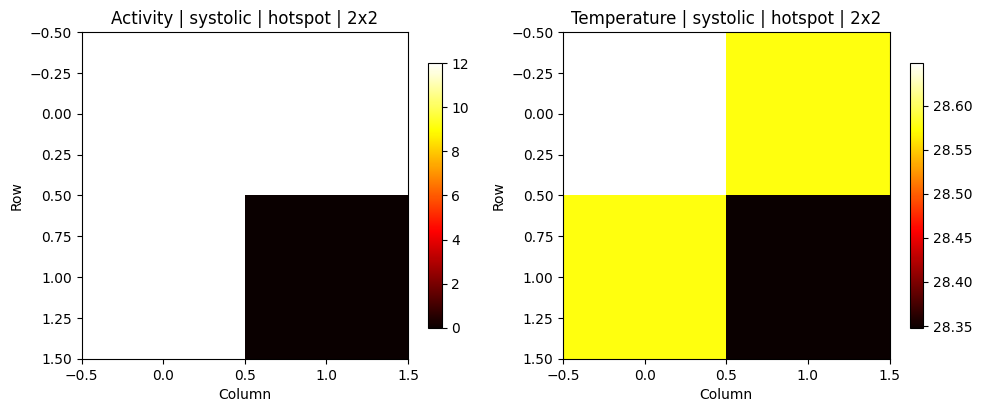

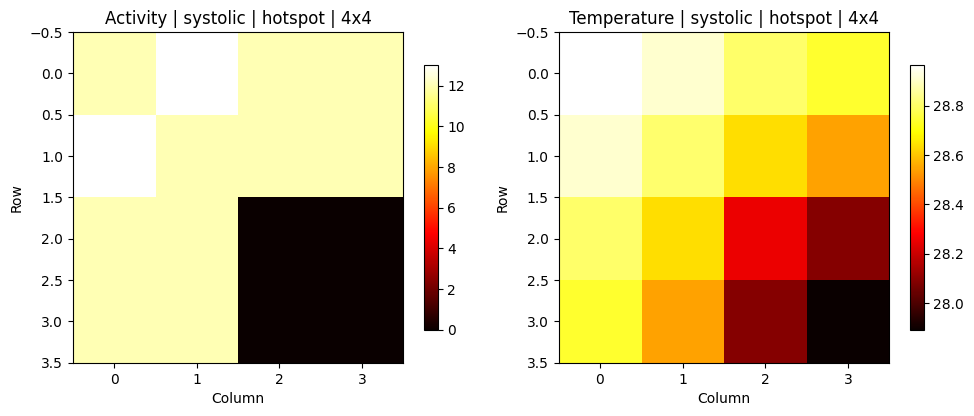

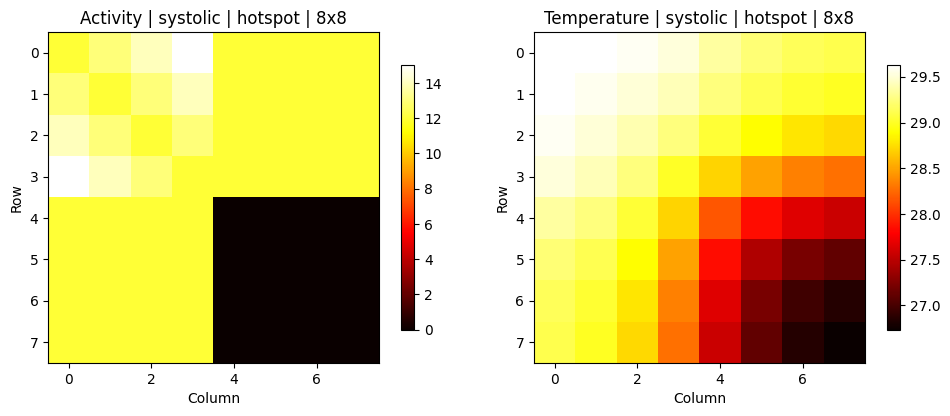

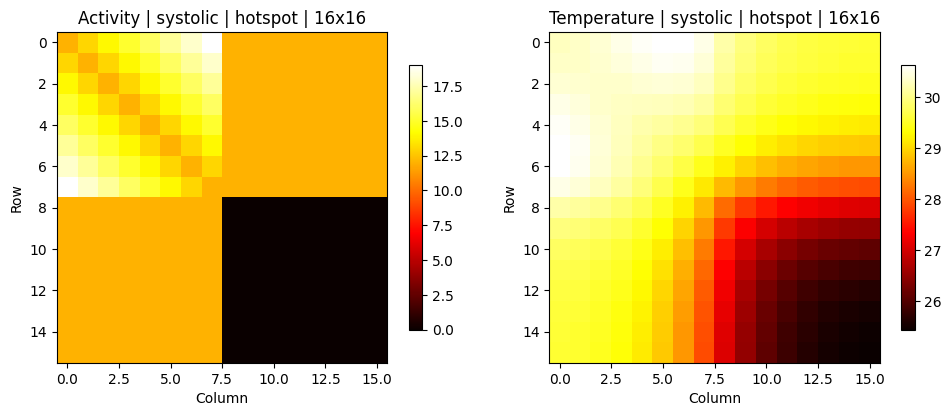

In [2]:
# --------------------------------------------------
# Cell 2: Load real anchor activity + thermal maps
# --------------------------------------------------
def load_activity_matrix(architecture, N, workload):
    path = ACTIVITY_DIR / architecture / f"{N}x{N}" / workload / "activity_matrix.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing activity matrix: {path}")
    return pd.read_csv(path).values.astype(np.float32)


def load_temperature_matrix(architecture, N, workload):
    path = THERMAL_DIR / architecture / f"{N}x{N}" / workload / "final_temperature_map.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing temperature matrix: {path}")
    return pd.read_csv(path).values.astype(np.float32)


real_anchor_cases = []

for _, row in real_anchor_candidates.iterrows():
    arch = row["architecture"]
    workload = row["workload"]
    N = int(row["N"])

    A = load_activity_matrix(arch, N, workload)
    T = load_temperature_matrix(arch, N, workload)

    if A.shape != (N, N):
        raise ValueError(f"Activity shape mismatch for {(arch, workload, N)}: got {A.shape}")
    if T.shape != (N, N):
        raise ValueError(f"Temperature shape mismatch for {(arch, workload, N)}: got {T.shape}")

    real_anchor_cases.append({
        "architecture": arch,
        "workload": workload,
        "N": N,
        "shape": f"{N}x{N}",
        "source": "anchor_real",
        "activity": A,
        "temperature": T,
    })

print("Loaded real anchor cases:", len(real_anchor_cases))

anchor_meta_df = pd.DataFrame([
    {
        "architecture": c["architecture"],
        "workload": c["workload"],
        "N": c["N"],
        "shape": c["shape"],
        "source": c["source"],
        "activity_shape": c["activity"].shape,
        "temperature_shape": c["temperature"].shape,
        "activity_min": float(np.min(c["activity"])),
        "activity_max": float(np.max(c["activity"])),
        "temp_min": float(np.min(c["temperature"])),
        "temp_max": float(np.max(c["temperature"])),
    }
    for c in real_anchor_cases
])

display(anchor_meta_df)


def preview_real_anchor(case):
    A = case["activity"]
    T = case["temperature"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    im0 = axes[0].imshow(A, cmap="hot", interpolation="nearest")
    axes[0].set_title(f"Activity | {case['architecture']} | {case['workload']} | {case['shape']}")
    axes[0].set_xlabel("Column")
    axes[0].set_ylabel("Row")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(T, cmap="hot", interpolation="nearest")
    axes[1].set_title(f"Temperature | {case['architecture']} | {case['workload']} | {case['shape']}")
    axes[1].set_xlabel("Column")
    axes[1].set_ylabel("Row")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    plt.tight_layout()
    plt.show()


# Preview one anchor from each size
sizes_to_preview = [2, 4, 8, 16]
for N in sizes_to_preview:
    case = next(c for c in real_anchor_cases if c["N"] == N and c["architecture"] == "systolic" and c["workload"] == "hotspot")
    preview_real_anchor(case)

Synthetic counts by size: {2: 200, 4: 250, 8: 400, 16: 500, 32: 500, 64: 400}
Generated synthetic preview cases: 12


,architecture,workload,N,activity_min,activity_max,temp_min,temp_max
0,standard,stripes,2,0.438878,10.434392,27.049236,27.299122
1,systolic,uniform,2,13.902490,15.244842,30.929186,30.959187
2,standard,stripes,4,0.128114,8.801544,26.592035,26.978859
3,systolic,checkerboard,4,8.033530,10.935460,28.762325,28.791540
4,standard,stripes,8,0.443414,7.908955,26.429726,26.910419
5,systolic,uniform,8,13.310525,14.567423,30.530237,30.736670
6,standard,stripes,16,0.354526,10.882792,26.871120,27.622972
7,systolic,wavefront,16,7.353965,13.450800,28.442806,29.910542
8,standard,uniform,32,8.617158,8.617158,28.446360,28.446360
9,systolic,wavefront,32,9.455045,17.104324,29.101305,31.553370


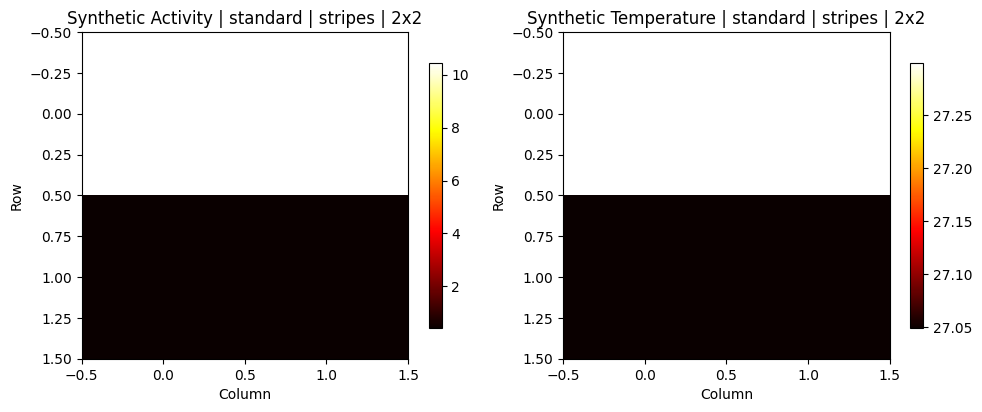

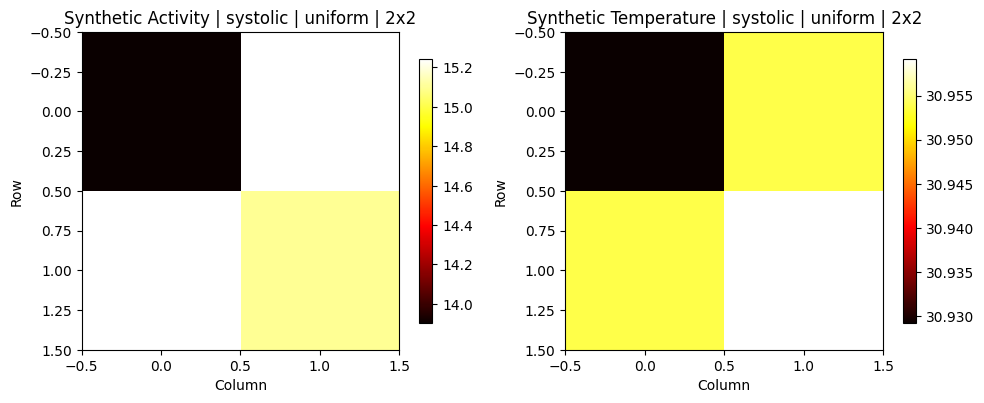

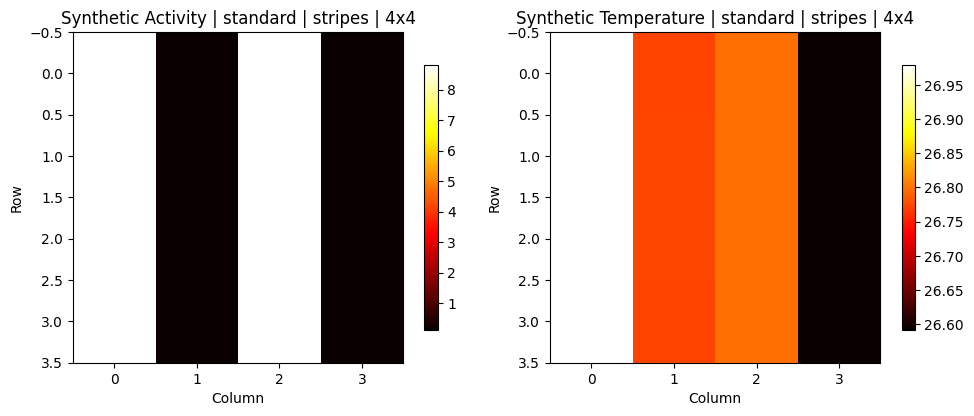

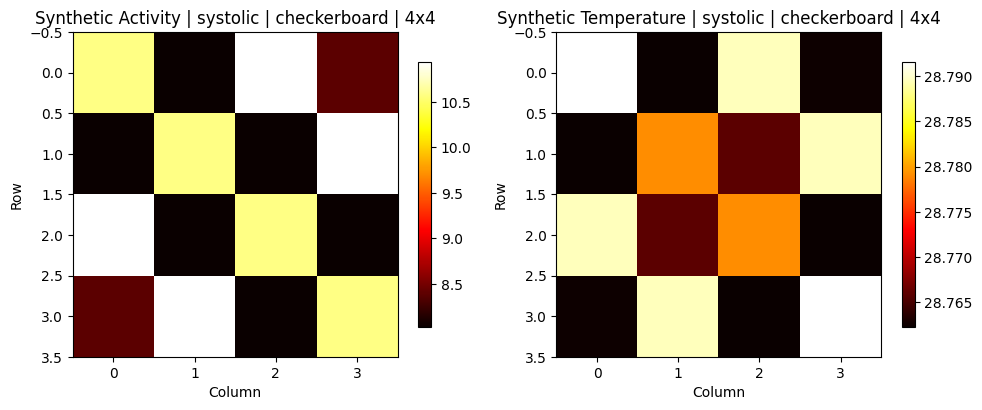

In [3]:
# --------------------------------------------------
# Cell 3: Converged thermal solver + multi-scale synthetic generators
# --------------------------------------------------

# Synthetic sample counts per size
SYNTH_COUNTS_BY_SIZE = {
    2: 200,
    4: 250,
    8: 400,
    16: 500,
    32: 500,
    64: 400,
}

print("Synthetic counts by size:", SYNTH_COUNTS_BY_SIZE)


# --------------------------------------------------
# Converged steady-state thermal solver
# --------------------------------------------------
def solve_steady_state_temperature(
    Q,
    max_steps=4000,
    tol=1e-5,
    T_amb=T_AMB,
    alpha=ALPHA,
    beta=BETA,
    gamma=GAMMA
):
    """
    Solve for steady-state temperature using the same finite-difference
    update rule as the earlier notebooks, but iterate until convergence.

    Q: heat source map [N, N]
    returns: final steady-state temperature map [N, N]
    """
    N = Q.shape[0]
    T = np.full((N, N), T_amb, dtype=np.float32)

    for _ in range(max_steps):
        T_new = T.copy()

        for i in range(N):
            for j in range(N):
                neighbors = 0.0
                count = 0

                if i > 0:
                    neighbors += T[i - 1, j]
                    count += 1
                if i < N - 1:
                    neighbors += T[i + 1, j]
                    count += 1
                if j > 0:
                    neighbors += T[i, j - 1]
                    count += 1
                if j < N - 1:
                    neighbors += T[i, j + 1]
                    count += 1

                lap = neighbors - count * T[i, j]

                T_new[i, j] = (
                    T[i, j]
                    + alpha * lap
                    + beta * Q[i, j]
                    - gamma * (T[i, j] - T_amb)
                )

        max_delta = np.max(np.abs(T_new - T))
        T = T_new

        if max_delta < tol:
            break

    return T.astype(np.float32)


# --------------------------------------------------
# Standard-architecture synthetic activity generators
# --------------------------------------------------
def gen_standard_uniform(N, rng, level_range=(8.0, 12.0)):
    level = rng.uniform(*level_range)
    return np.full((N, N), level, dtype=np.float32)


def gen_standard_checkerboard(N, rng, high_range=(8.0, 12.0), low_range=(0.0, 1.0)):
    high = rng.uniform(*high_range)
    low = rng.uniform(*low_range)

    A = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        for j in range(N):
            A[i, j] = high if ((i + j) % 2 == 0) else low
    return A


def gen_standard_hotspot(N, rng, hot_range=(8.0, 12.0), bg_range=(0.0, 1.5)):
    hot = rng.uniform(*hot_range)
    bg = rng.uniform(*bg_range)

    A = np.full((N, N), bg, dtype=np.float32)

    h = int(rng.integers(max(2, N // 8), max(3, N // 3)))
    w = int(rng.integers(max(2, N // 8), max(3, N // 3)))
    r0 = int(rng.integers(0, N - h + 1))
    c0 = int(rng.integers(0, N - w + 1))

    A[r0:r0 + h, c0:c0 + w] = hot
    return A


def gen_standard_multihotspot(N, rng, n_hotspots=2, hot_range=(7.0, 12.0), bg_range=(0.0, 2.0)):
    A = np.full((N, N), rng.uniform(*bg_range), dtype=np.float32)

    for _ in range(n_hotspots):
        hot = rng.uniform(*hot_range)
        h = int(rng.integers(max(2, N // 10), max(3, N // 4)))
        w = int(rng.integers(max(2, N // 10), max(3, N // 4)))
        r0 = int(rng.integers(0, N - h + 1))
        c0 = int(rng.integers(0, N - w + 1))
        A[r0:r0 + h, c0:c0 + w] = hot

    return A.astype(np.float32)


def gen_standard_stripes(N, rng, active_range=(7.0, 11.0), bg_range=(0.0, 1.0)):
    A = np.full((N, N), rng.uniform(*bg_range), dtype=np.float32)
    active = rng.uniform(*active_range)

    direction = rng.choice(["horizontal", "vertical"])
    stripe_w = int(rng.integers(max(1, N // 12), max(2, N // 5)))

    if direction == "horizontal":
        for r in range(0, N, 2 * stripe_w):
            A[r:r + stripe_w, :] = active
    else:
        for c in range(0, N, 2 * stripe_w):
            A[:, c:c + stripe_w] = active

    return A.astype(np.float32)


def gen_standard_quadrant(N, rng, hot_range=(7.0, 12.0), bg_range=(0.0, 1.5)):
    A = np.full((N, N), rng.uniform(*bg_range), dtype=np.float32)
    hot = rng.uniform(*hot_range)

    half = N // 2
    quadrant = rng.choice(["tl", "tr", "bl", "br"])

    if quadrant == "tl":
        A[:half, :half] = hot
    elif quadrant == "tr":
        A[:half, half:] = hot
    elif quadrant == "bl":
        A[half:, :half] = hot
    else:
        A[half:, half:] = hot

    return A.astype(np.float32)


# --------------------------------------------------
# Systolic-architecture synthetic activity generators
# --------------------------------------------------
def gen_systolic_uniform(N, rng, base_range=(10.0, 14.0), slope_range=(0.12, 0.45)):
    """
    Diagonal-gradient activity inspired by systolic wavefront behavior.
    Uses normalized coordinates so amplitude stays comparable across sizes.
    """
    base = rng.uniform(*base_range)
    slope = rng.uniform(*slope_range)

    A = np.zeros((N, N), dtype=np.float32)

    denom = max(N - 1, 1)
    for i in range(N):
        for j in range(N):
            d = abs(i - j) / denom
            s = (i + j) / denom
            A[i, j] = base + slope * (2.0 * d) + 0.6 * s

    return A.astype(np.float32)


def gen_systolic_checkerboard(N, rng, low_range=(6.0, 8.0), high_range=(8.0, 12.0)):
    """
    Checkerboard-like pattern with diagonal smearing.
    """
    low = rng.uniform(*low_range)
    high = rng.uniform(*high_range)

    A = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        for j in range(N):
            band = 0.18 * abs(i - j)
            parity = high if ((i + j) % 2 == 0) else low
            A[i, j] = parity + band
    return A.astype(np.float32)


def gen_systolic_hotspot(N, rng, hot_range=(12.0, 18.0), mid_range=(8.0, 12.0), low_range=(0.0, 1.5)):
    """
    Upper-left injected hotspot with propagated spread.
    Uses normalized distance so spread is size-stable.
    """
    A = np.full((N, N), rng.uniform(*low_range), dtype=np.float32)

    hot = rng.uniform(*hot_range)
    mid = rng.uniform(*mid_range)

    h = int(rng.integers(max(2, N // 8), max(3, N // 3)))
    w = int(rng.integers(max(2, N // 8), max(3, N // 3)))

    r0 = int(rng.integers(0, max(1, N // 5)))
    c0 = int(rng.integers(0, max(1, N // 5)))

    A[r0:r0 + h, c0:c0 + w] = hot

    denom = max(N - 1, 1)
    for i in range(N):
        for j in range(N):
            dist = (max(0, i - r0) + max(0, j - c0)) / denom
            spread = max(0.0, mid - 6.0 * dist)
            A[i, j] = max(A[i, j], spread)

    return A.astype(np.float32)

def gen_systolic_wavefront(N, rng, base_range=(5.0, 8.0), front_range=(6.0, 10.0)):
    """
    Wavefront-like activity using normalized coordinates.
    """
    base = rng.uniform(*base_range)
    front = rng.uniform(*front_range)

    A = np.full((N, N), base, dtype=np.float32)

    denom = max(N - 1, 1)
    for i in range(N):
        for j in range(N):
            x = j / denom
            y = i / denom

            # stronger near top/left and around diagonal
            diag_term = 1.0 - abs(x - y)
            inject_term = 1.0 - 0.5 * (x + y)

            A[i, j] += front * (0.55 * diag_term + 0.45 * inject_term)

    return A.astype(np.float32)

def gen_systolic_banded(N, rng, low_range=(4.0, 7.0), high_range=(10.0, 15.0)):
    """
    Diagonal band activity to mimic streaming propagation.
    """
    low = rng.uniform(*low_range)
    high = rng.uniform(*high_range)

    A = np.full((N, N), low, dtype=np.float32)

    band_w = int(rng.integers(max(1, N // 12), max(2, N // 6)))
    for i in range(N):
        for j in range(N):
            if abs(i - j) <= band_w:
                A[i, j] = high
            elif abs(i - j) <= 2 * band_w:
                A[i, j] = 0.5 * (low + high)

    return A.astype(np.float32)


# --------------------------------------------------
# Unified synthetic sampler
# --------------------------------------------------
def gen_activity_sample(N, architecture, rng):
    """
    Returns:
        activity_map: [N, N]
        meta: dict with architecture + synthetic workload label
    """
    if architecture == "standard":
        mode = rng.choice(
            ["uniform", "checkerboard", "hotspot", "multihotspot", "stripes", "quadrant"],
            p=[0.18, 0.18, 0.24, 0.14, 0.13, 0.13]
        )

        if mode == "uniform":
            A = gen_standard_uniform(N, rng)
        elif mode == "checkerboard":
            A = gen_standard_checkerboard(N, rng)
        elif mode == "hotspot":
            A = gen_standard_hotspot(N, rng)
        elif mode == "multihotspot":
            A = gen_standard_multihotspot(N, rng)
        elif mode == "stripes":
            A = gen_standard_stripes(N, rng)
        else:
            A = gen_standard_quadrant(N, rng)

    elif architecture == "systolic":
        mode = rng.choice(
            ["uniform", "checkerboard", "hotspot", "wavefront", "banded"],
            p=[0.22, 0.18, 0.28, 0.16, 0.16]
        )

        if mode == "uniform":
            A = gen_systolic_uniform(N, rng)
        elif mode == "checkerboard":
            A = gen_systolic_checkerboard(N, rng)
        elif mode == "hotspot":
            A = gen_systolic_hotspot(N, rng)
        elif mode == "wavefront":
            A = gen_systolic_wavefront(N, rng)
        else:
            A = gen_systolic_banded(N, rng)
    else:
        raise ValueError(f"Unknown architecture: {architecture}")

    return A.astype(np.float32), {"architecture": architecture, "workload": mode}


# --------------------------------------------------
# Quick preview helper
# --------------------------------------------------
def preview_synthetic_case(case):
    A = case["activity"]
    T = case["temperature"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    im0 = axes[0].imshow(A, cmap="hot", interpolation="nearest")
    axes[0].set_title(f"Synthetic Activity | {case['architecture']} | {case['workload']} | {case['shape']}")
    axes[0].set_xlabel("Column")
    axes[0].set_ylabel("Row")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(T, cmap="hot", interpolation="nearest")
    axes[1].set_title(f"Synthetic Temperature | {case['architecture']} | {case['workload']} | {case['shape']}")
    axes[1].set_xlabel("Column")
    axes[1].set_ylabel("Row")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Sanity check: generate one synthetic sample per size
# --------------------------------------------------
rng = np.random.default_rng(SEED)

synthetic_preview_cases = []
for N in SYNTHETIC_TRAIN_SIZES:
    for arch in ["standard", "systolic"]:
        A, meta = gen_activity_sample(N, arch, rng)
        Q = 0.1 * A
        T = solve_steady_state_temperature(Q)

        synthetic_preview_cases.append({
            "architecture": arch,
            "workload": meta["workload"],
            "N": N,
            "shape": f"{N}x{N}",
            "source": "synthetic_preview",
            "activity": A,
            "temperature": T,
        })

print("Generated synthetic preview cases:", len(synthetic_preview_cases))

preview_meta_df = pd.DataFrame([
    {
        "architecture": c["architecture"],
        "workload": c["workload"],
        "N": c["N"],
        "activity_min": float(np.min(c["activity"])),
        "activity_max": float(np.max(c["activity"])),
        "temp_min": float(np.min(c["temperature"])),
        "temp_max": float(np.max(c["temperature"])),
    }
    for c in synthetic_preview_cases
])

display(preview_meta_df)

for case in synthetic_preview_cases[:4]:
    preview_synthetic_case(case)


Generating synthetic cases for N=2 ...
  standard : 100
  systolic : 100
    standard |   20/100
    standard |   40/100
    standard |   60/100
    standard |   80/100
    standard |  100/100
    systolic |   20/100
    systolic |   40/100
    systolic |   60/100
    systolic |   80/100
    systolic |  100/100

Generating synthetic cases for N=4 ...
  standard : 125
  systolic : 125
    standard |   25/125
    standard |   50/125
    standard |   75/125
    standard |  100/125
    standard |  125/125
    systolic |   25/125
    systolic |   50/125
    systolic |   75/125
    systolic |  100/125
    systolic |  125/125

Generating synthetic cases for N=8 ...
  standard : 200
  systolic : 200
    standard |   40/200
    standard |   80/200
    standard |  120/200
    standard |  160/200
    standard |  200/200
    systolic |   40/200
    systolic |   80/200
    systolic |  120/200
    systolic |  160/200
    systolic |  200/200

Generating synthetic cases for N=16 ...
  standard : 250


source
synthetic                  2250
synthetic_extrapolation      60
anchor_real                  24
Name: count, dtype: int64


Counts by N and source:


,source,N,count
0,anchor_real,2,6
1,anchor_real,4,6
2,anchor_real,8,6
3,anchor_real,16,6
4,synthetic,2,200
5,synthetic,4,250
6,synthetic,8,400
7,synthetic,16,500
8,synthetic,32,500
9,synthetic,64,400



Counts by architecture, workload, N (synthetic train/support only):


,architecture,workload,N,count
0,standard,checkerboard,2,17
1,standard,hotspot,2,24
2,standard,multihotspot,2,13
3,standard,quadrant,2,7
4,standard,stripes,2,16
...,...,...,...,...
61,systolic,banded,64,34
62,systolic,checkerboard,64,43
63,systolic,hotspot,64,47
64,systolic,uniform,64,38



Counts by architecture, workload, N (synthetic extrapolation only):


,architecture,workload,N,count
0,standard,checkerboard,128,4
1,standard,hotspot,128,6
2,standard,multihotspot,128,2
3,standard,quadrant,128,2
4,standard,stripes,128,4
5,standard,uniform,128,2
6,systolic,banded,128,3
7,systolic,checkerboard,128,3
8,systolic,hotspot,128,6
9,systolic,uniform,128,5



Counts by architecture, workload, N (real anchors):


,architecture,workload,N,count
0,standard,checkerboard,2,1
1,standard,hotspot,2,1
2,standard,uniform,2,1
3,systolic,checkerboard,2,1
4,systolic,hotspot,2,1
5,systolic,uniform,2,1
6,standard,checkerboard,4,1
7,standard,hotspot,4,1
8,standard,uniform,4,1
9,systolic,checkerboard,4,1


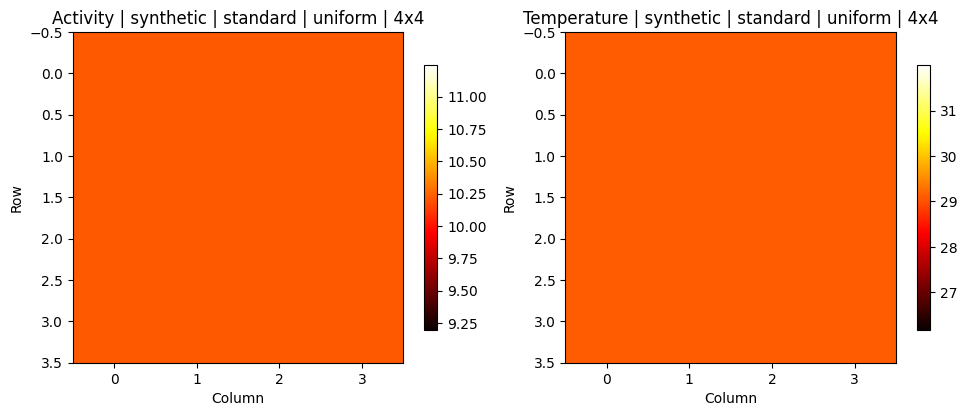

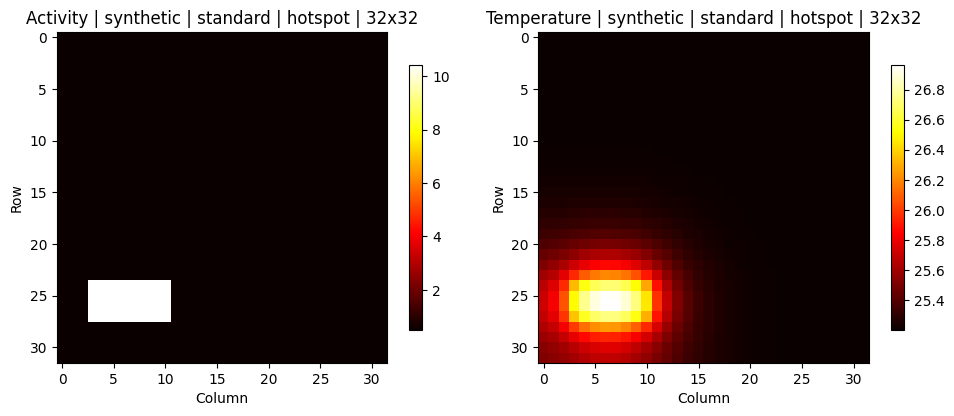

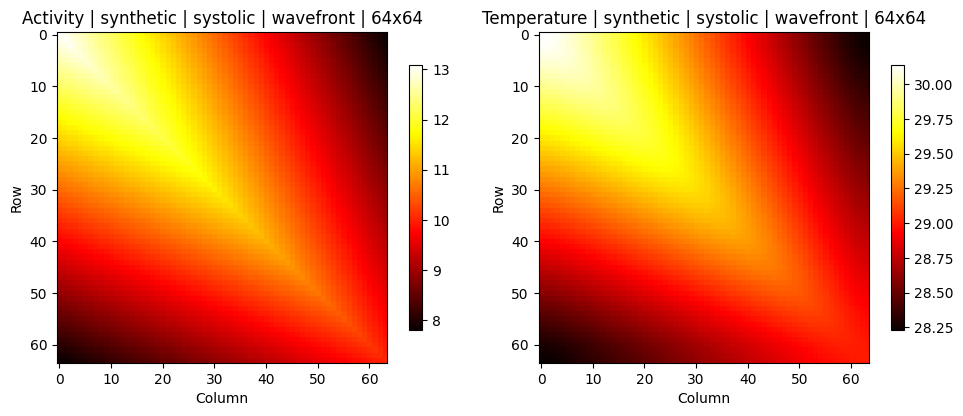

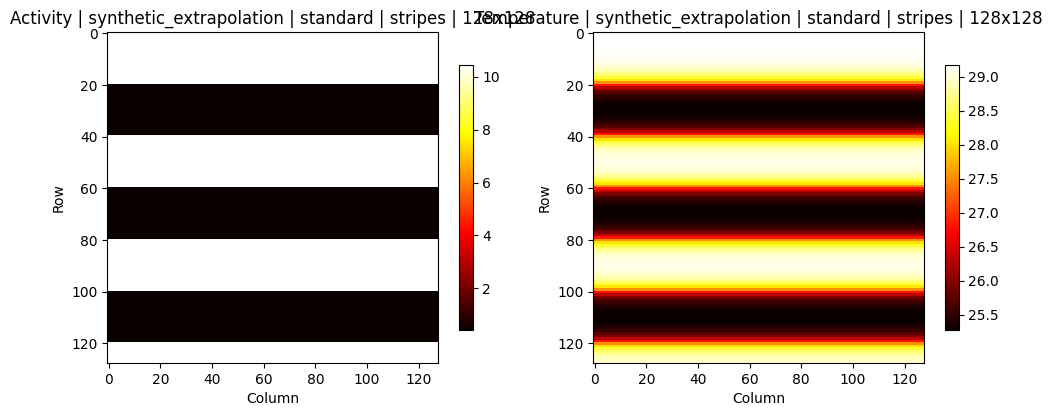

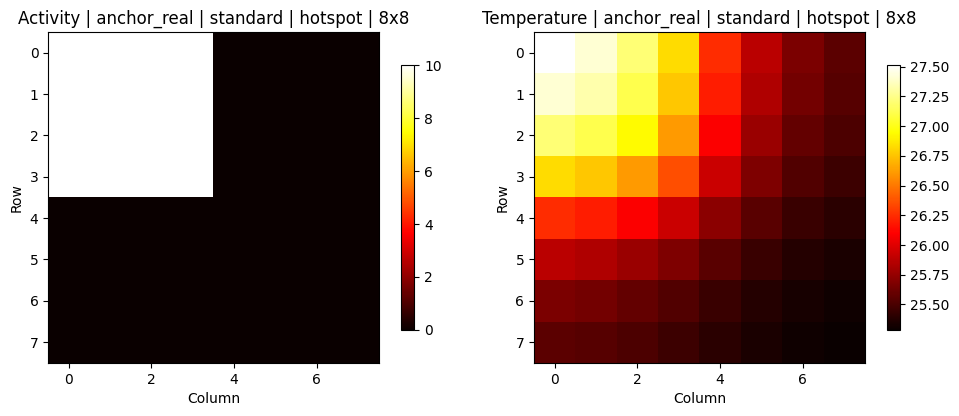

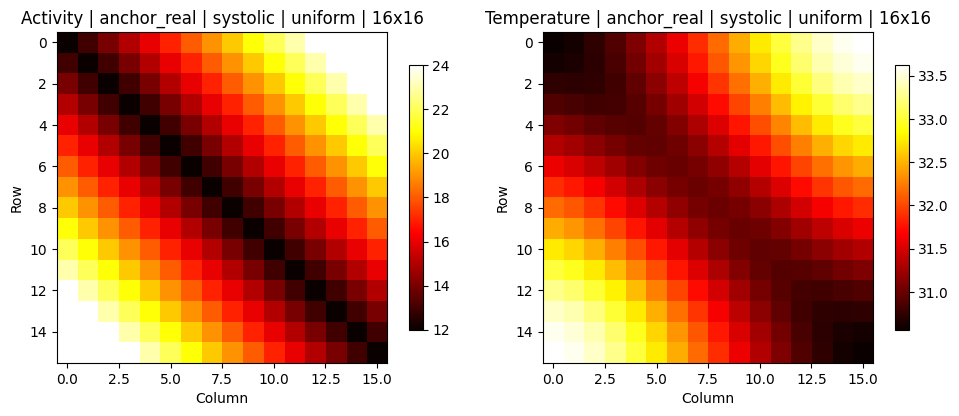

In [4]:
# --------------------------------------------------
# Cell 4: Build full multi-scale dataset
# (real anchors + synthetic train sizes + optional extrapolation sizes)
# --------------------------------------------------
import pickle
from time import time

DATA_CACHE_PATH = MULTISCALE_DIR / "multiscale_cases.pkl"
META_CSV_PATH   = MULTISCALE_DIR / "multiscale_cases_metadata.csv"

REBUILD_SYNTHETIC = True   # set True when changing size lists/counts


def build_synthetic_cases(size_list, counts_by_size, split_tag="synthetic"):
    rng = np.random.default_rng(SEED)

    synthetic_cases = []
    start_time = time()

    for N in size_list:
        total_count = counts_by_size[N]
        per_arch_count = total_count // 2

        print(f"\nGenerating {split_tag} cases for N={N} ...")
        print(f"  standard : {per_arch_count}")
        print(f"  systolic : {per_arch_count}")

        for architecture in ["standard", "systolic"]:
            for idx in range(per_arch_count):
                A, meta = gen_activity_sample(N, architecture, rng)

                Q = 0.1 * A.astype(np.float32)
                T = solve_steady_state_temperature(Q)

                synthetic_cases.append({
                    "sample_id": f"{split_tag}_{architecture}_{meta['workload']}_{N}_{idx:05d}",
                    "architecture": architecture,
                    "workload": meta["workload"],
                    "N": N,
                    "shape": f"{N}x{N}",
                    "source": split_tag,   # "synthetic" or "synthetic_extrapolation"
                    "activity": A.astype(np.float32),
                    "temperature": T.astype(np.float32),
                })

                if (idx + 1) % max(1, per_arch_count // 5) == 0:
                    print(f"    {architecture:8s} | {idx+1:4d}/{per_arch_count}")

    elapsed = time() - start_time
    print(f"\n{split_tag} generation complete in {elapsed/60:.2f} min")
    print(f"Total {split_tag} cases:", len(synthetic_cases))
    return synthetic_cases


# --------------------------------------------------
# Define size groups
# --------------------------------------------------
# training-support synthetic sizes
synthetic_train_sizes = SYNTHETIC_TRAIN_SIZES   # expected: [2, 4, 8, 16, 32, 64]

# extrapolation-only synthetic sizes
synthetic_extrap_sizes = EXTRAPOLATION_SIZES    # expected: [128, 256]

# counts for training-support sizes
train_counts = SYNTH_COUNTS_BY_SIZE

# light counts for extrapolation-only sizes
EXTRAP_COUNTS_BY_SIZE = {
    128: 40,
    256: 20,
}


# --------------------------------------------------
# Load from cache or rebuild
# --------------------------------------------------
if DATA_CACHE_PATH.exists() and not REBUILD_SYNTHETIC:
    print("Loading cached multi-scale dataset from:")
    print(" ", DATA_CACHE_PATH)

    with open(DATA_CACHE_PATH, "rb") as f:
        cache_obj = pickle.load(f)

    synthetic_cases = cache_obj["synthetic_cases"]
    synthetic_extrap_cases = cache_obj.get("synthetic_extrap_cases", [])
    cached_real_anchor_cases = cache_obj["real_anchor_cases"]

    print("Cached synthetic train cases :", len(synthetic_cases))
    print("Cached synthetic extrap cases:", len(synthetic_extrap_cases))
    print("Cached real anchors          :", len(cached_real_anchor_cases))

else:
    synthetic_cases = build_synthetic_cases(
        size_list=synthetic_train_sizes,
        counts_by_size=train_counts,
        split_tag="synthetic"
    )

    synthetic_extrap_cases = build_synthetic_cases(
        size_list=synthetic_extrap_sizes,
        counts_by_size=EXTRAP_COUNTS_BY_SIZE,
        split_tag="synthetic_extrapolation"
    )

    cache_obj = {
        "synthetic_cases": synthetic_cases,
        "synthetic_extrap_cases": synthetic_extrap_cases,
        "real_anchor_cases": real_anchor_cases,
    }

    with open(DATA_CACHE_PATH, "wb") as f:
        pickle.dump(cache_obj, f)

    print("\nSaved dataset cache to:")
    print(" ", DATA_CACHE_PATH)


# --------------------------------------------------
# Final combined dataset
# --------------------------------------------------
all_cases = synthetic_cases + synthetic_extrap_cases + real_anchor_cases

print("\nFinal dataset sizes:")
print("  Synthetic train/support cases :", len(synthetic_cases))
print("  Synthetic extrapolation cases :", len(synthetic_extrap_cases))
print("  Real anchors                  :", len(real_anchor_cases))
print("  Total cases                   :", len(all_cases))


# --------------------------------------------------
# Metadata table
# --------------------------------------------------
all_cases_meta_df = pd.DataFrame([
    {
        "case_id": idx,
        "sample_id": c.get("sample_id", f"case_{idx:05d}"),
        "architecture": c["architecture"],
        "workload": c["workload"],
        "N": c["N"],
        "shape": c["shape"],
        "source": c["source"],
        "activity_min": float(np.min(c["activity"])),
        "activity_max": float(np.max(c["activity"])),
        "activity_mean": float(np.mean(c["activity"])),
        "temp_min": float(np.min(c["temperature"])),
        "temp_max": float(np.max(c["temperature"])),
        "temp_mean": float(np.mean(c["temperature"])),
    }
    for idx, c in enumerate(all_cases)
])

all_cases_meta_df.to_csv(META_CSV_PATH, index=False)

print("\nSaved metadata CSV to:")
print(" ", META_CSV_PATH)

print("\nCounts by source:")
display(all_cases_meta_df["source"].value_counts())

print("\nCounts by N and source:")
display(
    all_cases_meta_df.groupby(["source", "N"]).size().rename("count").reset_index()
)

print("\nCounts by architecture, workload, N (synthetic train/support only):")
display(
    all_cases_meta_df[all_cases_meta_df["source"] == "synthetic"]
    .groupby(["architecture", "workload", "N"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["N", "architecture", "workload"])
    .reset_index(drop=True)
)

print("\nCounts by architecture, workload, N (synthetic extrapolation only):")
display(
    all_cases_meta_df[all_cases_meta_df["source"] == "synthetic_extrapolation"]
    .groupby(["architecture", "workload", "N"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["N", "architecture", "workload"])
    .reset_index(drop=True)
)

print("\nCounts by architecture, workload, N (real anchors):")
display(
    all_cases_meta_df[all_cases_meta_df["source"] == "anchor_real"]
    .groupby(["architecture", "workload", "N"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["N", "architecture", "workload"])
    .reset_index(drop=True)
)


# --------------------------------------------------
# Quick previews from the final pool
# --------------------------------------------------
def preview_case(case):
    A = case["activity"]
    T = case["temperature"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    im0 = axes[0].imshow(A, cmap="hot", interpolation="nearest")
    axes[0].set_title(f"Activity | {case['source']} | {case['architecture']} | {case['workload']} | {case['shape']}")
    axes[0].set_xlabel("Column")
    axes[0].set_ylabel("Row")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(T, cmap="hot", interpolation="nearest")
    axes[1].set_title(f"Temperature | {case['source']} | {case['architecture']} | {case['workload']} | {case['shape']}")
    axes[1].set_xlabel("Column")
    axes[1].set_ylabel("Row")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    plt.tight_layout()
    plt.show()


preview_targets = [
    next(c for c in synthetic_cases if c["N"] == 4 and c["architecture"] == "standard"),
    next(c for c in synthetic_cases if c["N"] == 32 and c["architecture"] == "standard"),
    next(c for c in synthetic_cases if c["N"] == 64 and c["architecture"] == "systolic"),
    next(c for c in synthetic_extrap_cases if c["N"] == 128 and c["architecture"] == "standard"),
    next(c for c in real_anchor_cases if c["N"] == 8 and c["architecture"] == "standard" and c["workload"] == "hotspot"),
    next(c for c in real_anchor_cases if c["N"] == 16 and c["architecture"] == "systolic" and c["workload"] == "uniform"),
]

for case in preview_targets:
    preview_case(case)

Main-pool cases   : 2274
Extrap-pool cases : 60

Main raw tensor shapes:
X_raw : (2274, 5, 64, 64)
Y_raw : (2274, 1, 64, 64)
MASK  : (2274, 1, 64, 64)

Extrap raw tensor shapes:
X_extrap_raw : (60, 5, 256, 256)
Y_extrap_raw : (60, 1, 256, 256)
MASK_extrap  : (60, 1, 256, 256)

Main counts by source and N:


,source,N,count
0,anchor_real,2,6
1,anchor_real,4,6
2,anchor_real,8,6
3,anchor_real,16,6
4,synthetic,2,200
5,synthetic,4,250
6,synthetic,8,400
7,synthetic,16,500
8,synthetic,32,500
9,synthetic,64,400



Extrap counts by source and N:


,source,N,count
0,synthetic_extrapolation,128,40
1,synthetic_extrapolation,256,20


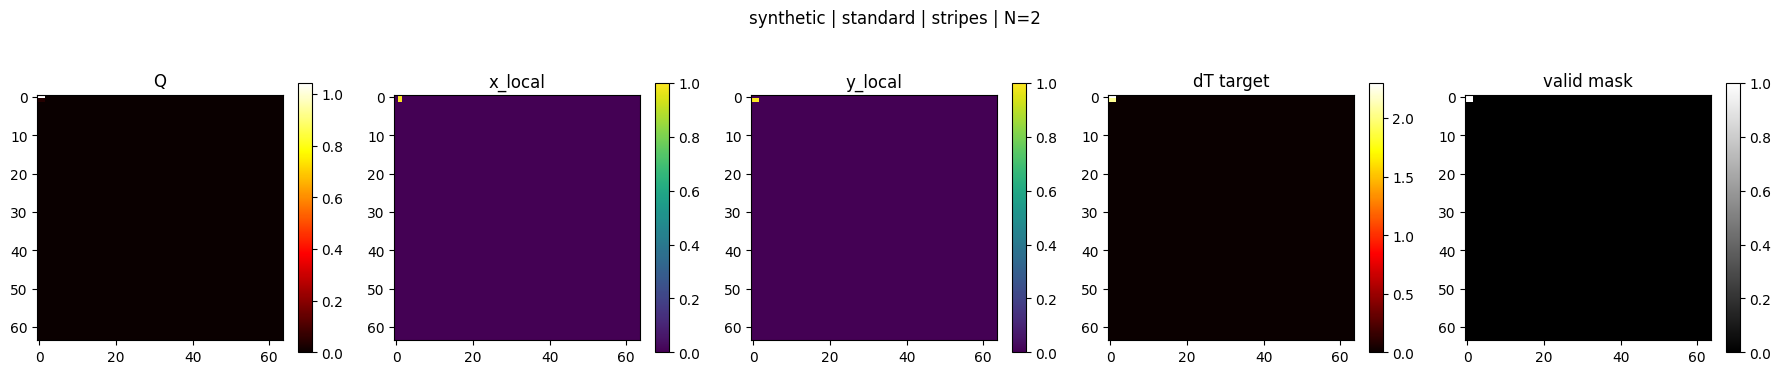

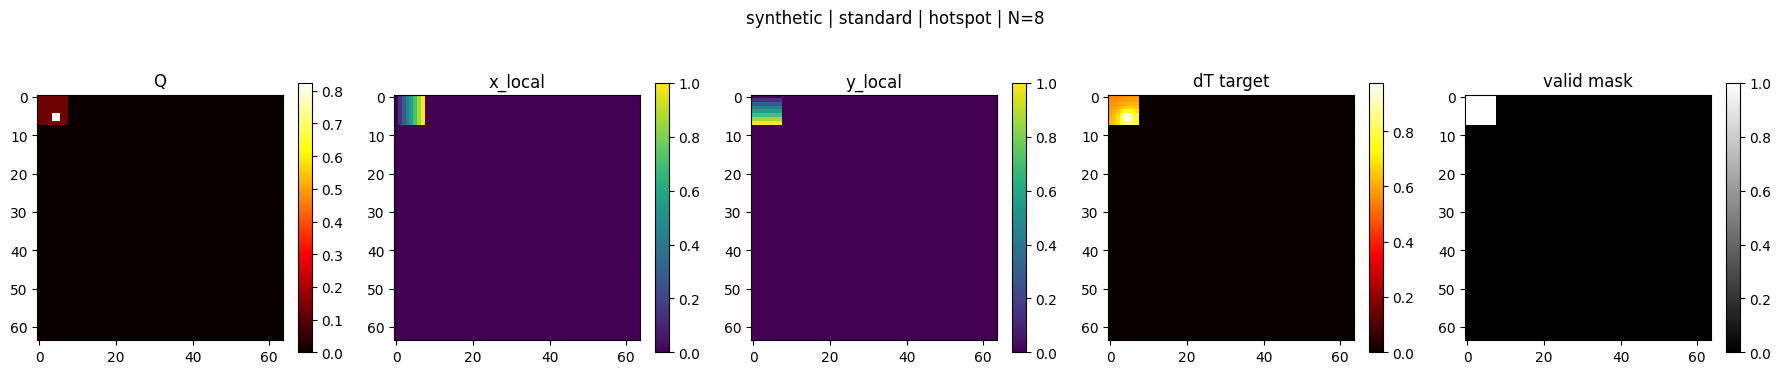

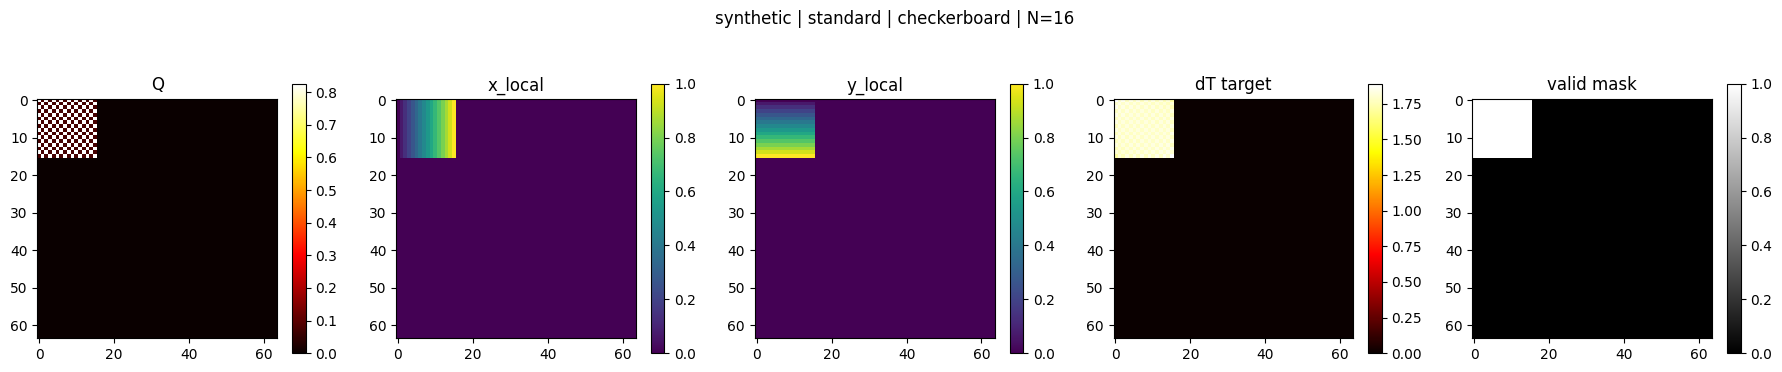

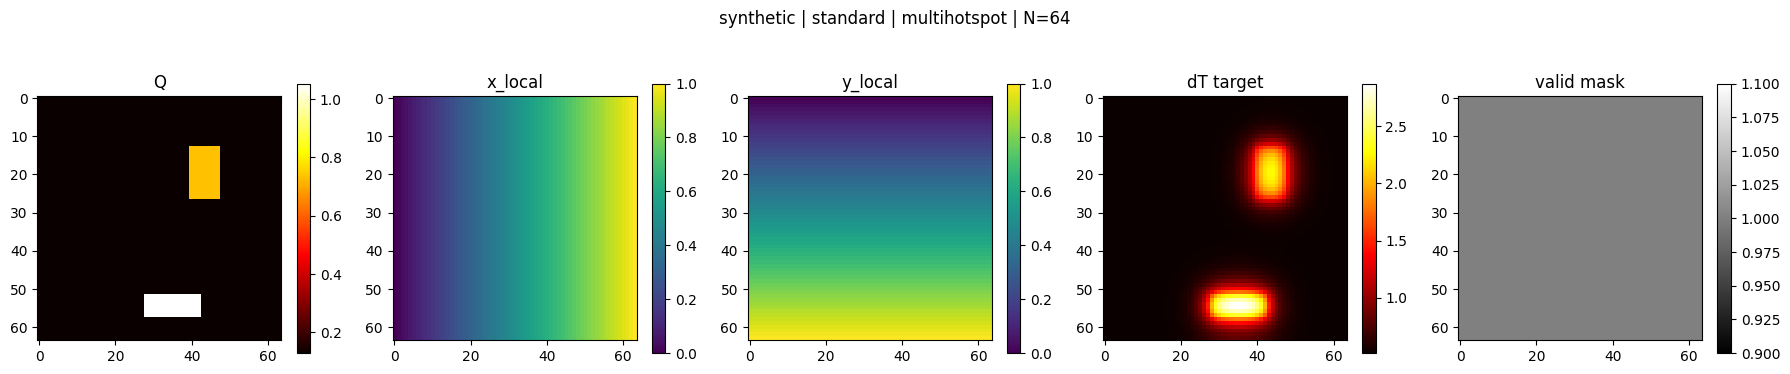

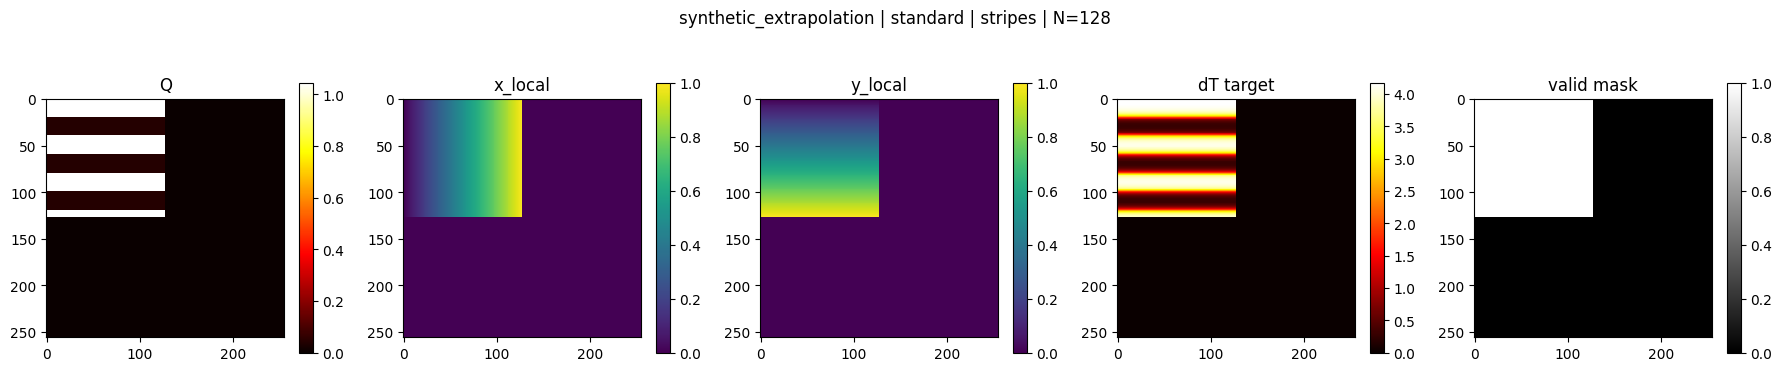

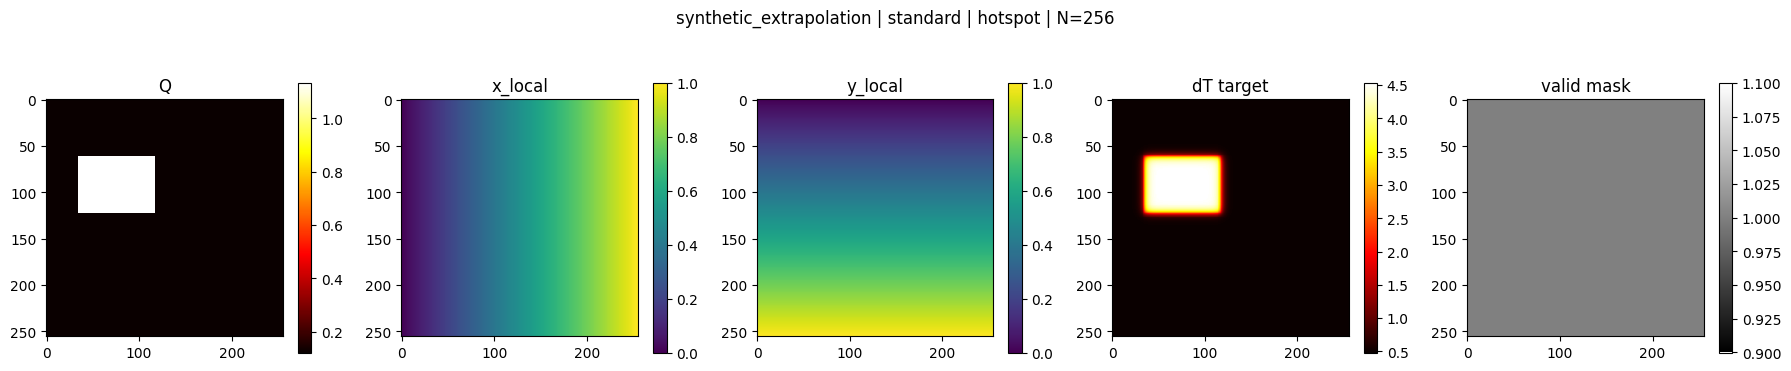

In [5]:
# --------------------------------------------------
# Cell 5: Build padded multi-scale tensors
#
# Two groups:
# 1) Main pool (<= MAX_TRAIN_SIZE) -> for training/val/test/fine-tune
# 2) Extrap pool (> MAX_TRAIN_SIZE) -> for 128x128 / 256x256 eval only
#
# Input channels:
#   0 -> Q
#   1 -> x_local
#   2 -> y_local
#   3 -> size channel = log2(N) / 8
#   4 -> architecture channel (0=standard, 1=systolic)
# --------------------------------------------------
MAX_SIZE = MAX_TRAIN_SIZE          # expected = 64
EXTRAP_MAX_SIZE = max([c["N"] for c in all_cases])   # expected = 256


def pad_top_left(arr, out_size, fill_value=0.0):
    H, W = arr.shape
    if H > out_size or W > out_size:
        raise ValueError(f"Array shape {(H, W)} is larger than out_size={out_size}")
    out = np.full((out_size, out_size), fill_value, dtype=np.float32)
    out[:H, :W] = arr.astype(np.float32)
    return out


def build_local_coord_maps(N, out_size):
    x_valid = np.linspace(0.0, 1.0, N, dtype=np.float32)
    y_valid = np.linspace(0.0, 1.0, N, dtype=np.float32)

    x_map_valid = np.tile(x_valid[None, :], (N, 1))
    y_map_valid = np.tile(y_valid[:, None], (1, N))

    x_map = pad_top_left(x_map_valid, out_size, fill_value=0.0)
    y_map = pad_top_left(y_map_valid, out_size, fill_value=0.0)
    return x_map, y_map


def build_size_channel(N, out_size):
    size_value = np.float32(np.log2(N) / 8.0)
    return np.full((out_size, out_size), size_value, dtype=np.float32)


def build_arch_channel(architecture, out_size):
    arch_value = np.float32(0.0 if architecture == "standard" else 1.0)
    return np.full((out_size, out_size), arch_value, dtype=np.float32)


def build_valid_mask(N, out_size):
    m = np.zeros((out_size, out_size), dtype=np.float32)
    m[:N, :N] = 1.0
    return m


def build_tensor_pool(case_list, out_size):
    X_list = []
    Y_list = []
    M_list = []
    meta_records = []

    for idx, case in enumerate(case_list):
        N = int(case["N"])
        architecture = case["architecture"]

        activity = case["activity"].astype(np.float32)
        temperature = case["temperature"].astype(np.float32)

        Q_valid = (0.1 * activity).astype(np.float32)
        dT_valid = (temperature - T_AMB).astype(np.float32)

        Q_pad = pad_top_left(Q_valid, out_size, fill_value=0.0)
        dT_pad = pad_top_left(dT_valid, out_size, fill_value=0.0)

        x_local, y_local = build_local_coord_maps(N, out_size)
        size_ch = build_size_channel(N, out_size)
        arch_ch = build_arch_channel(architecture, out_size)
        mask = build_valid_mask(N, out_size)

        x = np.stack([Q_pad, x_local, y_local, size_ch, arch_ch], axis=0).astype(np.float32)
        y = dT_pad[None, :, :].astype(np.float32)
        m = mask[None, :, :].astype(np.float32)

        X_list.append(x)
        Y_list.append(y)
        M_list.append(m)

        meta_records.append({
            "sample_id": case.get("sample_id", case.get("id", f"case_{idx:05d}")),
            "source": case["source"],
            "architecture": case["architecture"],
            "workload": case["workload"],
            "N": int(case["N"]),
            "shape": case.get("shape", f"{N}x{N}"),
        })

    X_arr = np.stack(X_list).astype(np.float32)
    Y_arr = np.stack(Y_list).astype(np.float32)
    M_arr = np.stack(M_list).astype(np.float32)
    meta = pd.DataFrame(meta_records)

    return X_arr, Y_arr, M_arr, meta


# --------------------------------------------------
# Split all_cases into main vs extrap pools
# --------------------------------------------------
main_cases = [c for c in all_cases if int(c["N"]) <= MAX_SIZE]
extrap_cases = [c for c in all_cases if int(c["N"]) > MAX_SIZE]

print("Main-pool cases   :", len(main_cases))
print("Extrap-pool cases :", len(extrap_cases))

# Main tensors (<=64)
X_raw, Y_raw, MASK, meta_df = build_tensor_pool(main_cases, MAX_SIZE)

# Extrap tensors (>64), if present
if len(extrap_cases) > 0:
    X_extrap_raw, Y_extrap_raw, MASK_extrap, meta_extrap_df = build_tensor_pool(extrap_cases, EXTRAP_MAX_SIZE)
else:
    X_extrap_raw, Y_extrap_raw, MASK_extrap = None, None, None
    meta_extrap_df = pd.DataFrame(columns=["sample_id", "source", "architecture", "workload", "N", "shape"])

print("\nMain raw tensor shapes:")
print("X_raw :", X_raw.shape)
print("Y_raw :", Y_raw.shape)
print("MASK  :", MASK.shape)

if X_extrap_raw is not None:
    print("\nExtrap raw tensor shapes:")
    print("X_extrap_raw :", X_extrap_raw.shape)
    print("Y_extrap_raw :", Y_extrap_raw.shape)
    print("MASK_extrap  :", MASK_extrap.shape)

print("\nMain counts by source and N:")
display(meta_df.groupby(["source", "N"]).size().rename("count").reset_index())

if len(meta_extrap_df) > 0:
    print("\nExtrap counts by source and N:")
    display(meta_extrap_df.groupby(["source", "N"]).size().rename("count").reset_index())


# --------------------------------------------------
# Quick preview helper
# --------------------------------------------------
def preview_padded_sample(X_arr, Y_arr, M_arr, meta_local_df, idx):
    sample_meta = meta_local_df.iloc[idx]
    x = X_arr[idx]
    y = Y_arr[idx, 0]
    m = M_arr[idx, 0]

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    im0 = axes[0].imshow(x[0], cmap="hot", interpolation="nearest")
    axes[0].set_title("Q")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(x[1], cmap="viridis", interpolation="nearest")
    axes[1].set_title("x_local")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    im2 = axes[2].imshow(x[2], cmap="viridis", interpolation="nearest")
    axes[2].set_title("y_local")
    plt.colorbar(im2, ax=axes[2], shrink=0.8)

    im3 = axes[3].imshow(y, cmap="hot", interpolation="nearest")
    axes[3].set_title("dT target")
    plt.colorbar(im3, ax=axes[3], shrink=0.8)

    im4 = axes[4].imshow(m, cmap="gray", interpolation="nearest")
    axes[4].set_title("valid mask")
    plt.colorbar(im4, ax=axes[4], shrink=0.8)

    fig.suptitle(
        f"{sample_meta['source']} | {sample_meta['architecture']} | "
        f"{sample_meta['workload']} | N={sample_meta['N']}"
    )
    plt.tight_layout()
    plt.show()


# Preview representative main-pool sizes
preview_indices = []
for target_N in [2, 8, 16, 64]:
    subset = meta_df.index[meta_df["N"] == target_N].tolist()
    if len(subset) > 0:
        preview_indices.append(subset[0])

for idx in preview_indices:
    preview_padded_sample(X_raw, Y_raw, MASK, meta_df, idx)

# Preview extrapolation pool if present
if len(meta_extrap_df) > 0:
    extrap_preview_indices = []
    for target_N in [128, 256]:
        subset = meta_extrap_df.index[meta_extrap_df["N"] == target_N].tolist()
        if len(subset) > 0:
            extrap_preview_indices.append(subset[0])

    for idx in extrap_preview_indices:
        preview_padded_sample(X_extrap_raw, Y_extrap_raw, MASK_extrap, meta_extrap_df, idx)

In [6]:
# --------------------------------------------------
# Cell 6: Multi-scale split + train-only normalization
#
# Strategy:
# - Synthetic data:
#     stratified train / val / test
# - Real anchors:
#     fine-tune/train support -> N in {8, 16}
#     held-out anchor eval    -> N in {2, 4}
#
# Normalization:
# - Compute Q_mean/Q_std and Y_mean/Y_std from TRAIN data only
# - Normalize ONLY the Q channel (channel 0)
# - Keep x/y/size/arch channels in their native ranges
# - Zero out padded target regions after normalization
# --------------------------------------------------
import os
from torch.utils.data import Dataset, DataLoader# -----------------------------
# Split config
# -----------------------------
BATCH_SIZE = 8
ANCHOR_TRAIN_REPEAT = 8   # modest oversampling so anchors matter during training


# --------------------------------------------------
# Stratified synthetic split
# --------------------------------------------------
def stratified_synthetic_split(meta_df, train_frac=0.70, val_frac=0.15, seed=SEED):
    rng = np.random.default_rng(seed)

    syn_df = meta_df[meta_df["source"] == "synthetic"].copy()
    syn_df["strat_key"] = (
        syn_df["architecture"].astype(str) + "|" +
        syn_df["workload"].astype(str) + "|" +
        syn_df["N"].astype(str)
    )

    train_idx = []
    val_idx = []
    test_idx = []

    for _, group in syn_df.groupby("strat_key"):
        idxs = group.index.to_list()
        rng.shuffle(idxs)

        n = len(idxs)
        n_train = int(np.floor(train_frac * n))
        n_val = int(np.floor(val_frac * n))
        n_test = n - n_train - n_val

        # safety for tiny groups
        if n >= 3:
            n_train = max(1, n_train)
            n_val = max(1, n_val)
            n_test = max(1, n_test)

            # rebalance if we exceeded n
            while (n_train + n_val + n_test) > n:
                if n_train >= n_val and n_train >= n_test and n_train > 1:
                    n_train -= 1
                elif n_val >= n_test and n_val > 1:
                    n_val -= 1
                elif n_test > 1:
                    n_test -= 1
                else:
                    break

        train_idx.extend(idxs[:n_train])
        val_idx.extend(idxs[n_train:n_train + n_val])
        test_idx.extend(idxs[n_train + n_val:n_train + n_val + n_test])

    return sorted(train_idx), sorted(val_idx), sorted(test_idx)


syn_train_idx, syn_val_idx, syn_test_idx = stratified_synthetic_split(meta_df)

# --------------------------------------------------
# Real-anchor split by size
# --------------------------------------------------
anchor_ft_idx = meta_df.index[
    (meta_df["source"] == "anchor_real") &
    (meta_df["N"].isin([8, 16]))
].tolist()

anchor_eval_idx = meta_df.index[
    (meta_df["source"] == "anchor_real") &
    (meta_df["N"].isin([2, 4]))
].tolist()

print("Synthetic split sizes:")
print("  Train:", len(syn_train_idx))
print("  Val  :", len(syn_val_idx))
print("  Test :", len(syn_test_idx))

print("\nAnchor split sizes:")
print("  Fine-tune/train support (8,16):", len(anchor_ft_idx))
print("  Held-out eval (2,4)           :", len(anchor_eval_idx))

# Main train indices = synthetic train + repeated anchor fine-tune samples
train_idx = syn_train_idx + anchor_ft_idx * ANCHOR_TRAIN_REPEAT
val_idx = syn_val_idx
test_idx = syn_test_idx


# --------------------------------------------------
# Train-only normalization stats
# Only normalize Q channel and target dT over VALID cells.
# --------------------------------------------------
def masked_mean_np(arr, mask):
    return float((arr * mask).sum() / (mask.sum() + 1e-8))

def masked_std_np(arr, mask, mean):
    var = ((arr - mean) ** 2 * mask).sum() / (mask.sum() + 1e-8)
    return float(np.sqrt(var + 1e-8))


# IMPORTANT:
# Use the UNIQUE training indices for statistics,
# not the oversampled repeated train list.
train_stats_idx = sorted(list(set(syn_train_idx + anchor_ft_idx)))

train_q = X_raw[train_stats_idx, 0:1, :, :]   # Q only
train_y = Y_raw[train_stats_idx, :, :, :]
train_m = MASK[train_stats_idx, :, :, :]

X_mean = np.float32(masked_mean_np(train_q, train_m))
X_std  = np.float32(masked_std_np(train_q, train_m, X_mean))

Y_mean = np.float32(masked_mean_np(train_y, train_m))
Y_std  = np.float32(masked_std_np(train_y, train_m, Y_mean))

print("\nTrain-only normalization stats:")
print("Q_mean:", float(X_mean), "Q_std:", float(X_std))
print("Y_mean:", float(Y_mean), "Y_std:", float(Y_std))


# --------------------------------------------------
# Normalize data
# - channel 0 (Q) is normalized over valid cells only
# - channels 1:5 (x,y,size,arch) stay in native ranges
# - target dT is normalized over valid cells only
# - padded target region is kept at zero
# --------------------------------------------------
X = X_raw.copy()
Y = Y_raw.copy()

# Normalize Q channel only
X[:, 0:1, :, :] = np.where(
    MASK > 0.5,
    (X_raw[:, 0:1, :, :] - X_mean) / X_std,
    0.0
).astype(np.float32)

# Normalize target only on valid region
Y = np.where(
    MASK > 0.5,
    (Y_raw - Y_mean) / Y_std,
    0.0
).astype(np.float32)

print("\nNormalized tensor shapes:")
print("X:", X.shape)
print("Y:", Y.shape)
print("MASK:", MASK.shape)


# --------------------------------------------------
# Dataset
# --------------------------------------------------
class MultiScaleThermalDataset(Dataset):
    def __init__(self, X, Y, MASK, meta_df, indices):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.M = torch.tensor(MASK, dtype=torch.float32)
        self.meta_df = meta_df.reset_index(drop=True)
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        return self.X[idx], self.Y[idx], self.M[idx]


train_set = MultiScaleThermalDataset(X, Y, MASK, meta_df, train_idx)
val_set = MultiScaleThermalDataset(X, Y, MASK, meta_df, val_idx)
test_set = MultiScaleThermalDataset(X, Y, MASK, meta_df, test_idx)
anchor_eval_set = MultiScaleThermalDataset(X, Y, MASK, meta_df, anchor_eval_idx)
anchor_ft_set = MultiScaleThermalDataset(X, Y, MASK, meta_df, anchor_ft_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
anchor_eval_loader = DataLoader(anchor_eval_set, batch_size=BATCH_SIZE, shuffle=False)
anchor_ft_loader = DataLoader(anchor_ft_set, batch_size=BATCH_SIZE, shuffle=False)

print("\nLoader sizes:")
print("  train_loader       :", len(train_loader))
print("  val_loader         :", len(val_loader))
print("  test_loader        :", len(test_loader))
print("  anchor_eval_loader :", len(anchor_eval_loader))
print("  anchor_ft_loader   :", len(anchor_ft_loader))


# --------------------------------------------------
# Split metadata summary
# --------------------------------------------------
split_role = pd.Series("unused", index=meta_df.index, dtype="object")
split_role.loc[syn_train_idx] = "synthetic_train"
split_role.loc[syn_val_idx] = "synthetic_val"
split_role.loc[syn_test_idx] = "synthetic_test"
split_role.loc[anchor_ft_idx] = "anchor_finetune"
split_role.loc[anchor_eval_idx] = "anchor_eval"

split_meta_df = meta_df.copy()
split_meta_df["split_role"] = split_role.values

print("\nCounts by split_role, architecture, workload, N:")
display(
    split_meta_df.groupby(["split_role", "architecture", "workload", "N"])
    .size()
    .rename("count")
    .reset_index()
)

split_meta_path = os.path.join(
    PROJECT_ROOT,
    "results",
    "multiscale_cnn_pinn",
    "multiscale_split_metadata_v2.csv"
)
split_meta_df.to_csv(split_meta_path, index=False)
print("\nSaved split metadata to:")
print(split_meta_path)


# --------------------------------------------------
# Batch sanity check
# --------------------------------------------------
xb, yb, mb = next(iter(train_loader))
print("\nBatch sanity check:")
print("xb shape:", xb.shape)   # expected [B, 5, 64, 64]
print("yb shape:", yb.shape)   # expected [B, 1, 64, 64]
print("mb shape:", mb.shape)   # expected [B, 1, 64, 64]

Synthetic split sizes:
  Train: 1548
  Val  : 305
  Test : 397

Anchor split sizes:
  Fine-tune/train support (8,16): 12
  Held-out eval (2,4)           : 12

Train-only normalization stats:
Q_mean: 0.6850073337554932 Q_std: 0.501666247844696
Y_mean: 2.7396581172943115 Y_std: 1.8178027868270874

Normalized tensor shapes:
X: (2274, 5, 64, 64)
Y: (2274, 1, 64, 64)
MASK: (2274, 1, 64, 64)

Loader sizes:
  train_loader       : 206
  val_loader         : 39
  test_loader        : 50
  anchor_eval_loader : 2
  anchor_ft_loader   : 2

Counts by split_role, architecture, workload, N:


,split_role,architecture,workload,N,count
0,anchor_eval,standard,checkerboard,2,1
1,anchor_eval,standard,checkerboard,4,1
2,anchor_eval,standard,hotspot,2,1
3,anchor_eval,standard,hotspot,4,1
4,anchor_eval,standard,uniform,2,1
...,...,...,...,...,...
217,synthetic_val,systolic,wavefront,4,1
218,synthetic_val,systolic,wavefront,8,5
219,synthetic_val,systolic,wavefront,16,5
220,synthetic_val,systolic,wavefront,32,4



Saved split metadata to:
/home/aditya_chaudhry/thermal_aware_mac/results/multiscale_cnn_pinn/multiscale_split_metadata_v2.csv

Batch sanity check:
xb shape: torch.Size([8, 5, 64, 64])
yb shape: torch.Size([8, 1, 64, 64])
mb shape: torch.Size([8, 1, 64, 64])


In [7]:
# --------------------------------------------------
# Cell 7: Multi-scale CNN model (Q, x, y) -> dT
# --------------------------------------------------
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class ConvGNAct(nn.Module):
    def __init__(self, in_ch, out_ch, num_groups=8):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=min(num_groups, out_ch), num_channels=out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(num_groups=min(num_groups, out_ch), num_channels=out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ResidualConvBlock(nn.Module):
    def __init__(self, channels, num_groups=8):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.gn1 = nn.GroupNorm(num_groups=min(num_groups, channels), num_channels=channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.gn2 = nn.GroupNorm(num_groups=min(num_groups, channels), num_channels=channels)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.gn1(out)
        out = self.act(out)

        out = self.conv2(out)
        out = self.gn2(out)

        out = out + residual
        out = self.act(out)
        return out


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, num_groups=8):
        super().__init__()
        self.conv = ConvGNAct(in_ch, out_ch, num_groups=num_groups)
        self.res = ResidualConvBlock(out_ch, num_groups=num_groups)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        feat = self.conv(x)
        feat = self.res(feat)
        down = self.pool(feat)
        return feat, down


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, num_groups=8):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvGNAct(out_ch + skip_ch, out_ch, num_groups=num_groups)
        self.res = ResidualConvBlock(out_ch, num_groups=num_groups)

    def forward(self, x, skip):
        x = self.up(x)

        # Safety crop if shapes mismatch by 1 pixel for any reason
        if x.shape[-2:] != skip.shape[-2:]:
            h = min(x.shape[-2], skip.shape[-2])
            w = min(x.shape[-1], skip.shape[-1])
            x = x[:, :, :h, :w]
            skip = skip[:, :, :h, :w]

        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        x = self.res(x)
        return x


class MultiScaleThermalUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=32, num_groups=8):
        super().__init__()

        # Encoder: 64 -> 32 -> 16 -> 8
        self.down1 = DownBlock(in_channels, base_channels, num_groups=num_groups)
        self.down2 = DownBlock(base_channels, base_channels * 2, num_groups=num_groups)
        self.down3 = DownBlock(base_channels * 2, base_channels * 4, num_groups=num_groups)

        # Bottleneck at 8x8
        self.bottleneck = nn.Sequential(
            ConvGNAct(base_channels * 4, base_channels * 8, num_groups=num_groups),
            ResidualConvBlock(base_channels * 8, num_groups=num_groups),
            ResidualConvBlock(base_channels * 8, num_groups=num_groups),
        )

        # Decoder: 8 -> 16 -> 32 -> 64
        self.up3 = UpBlock(base_channels * 8, base_channels * 4, base_channels * 4, num_groups=num_groups)
        self.up2 = UpBlock(base_channels * 4, base_channels * 2, base_channels * 2, num_groups=num_groups)
        self.up1 = UpBlock(base_channels * 2, base_channels, base_channels, num_groups=num_groups)

        # Output projection
        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        s1, x = self.down1(x)   # 64 -> 32
        s2, x = self.down2(x)   # 32 -> 16
        s3, x = self.down3(x)   # 16 -> 8

        x = self.bottleneck(x)

        x = self.up3(x, s3)     # 8 -> 16
        x = self.up2(x, s2)     # 16 -> 32
        x = self.up1(x, s1)     # 32 -> 64

        out = self.out_conv(x)  # [B, 1, 64, 64]
        return out


# --------------------------------------------------
# Instantiate model
# --------------------------------------------------
model = MultiScaleThermalUNet(
    in_channels=5,
    out_channels=1,
    base_channels=32,
    num_groups=8
).to(device)

print(model)
print("\nTrainable parameters:", count_parameters(model))


# --------------------------------------------------
# Sanity check
# --------------------------------------------------
xb, yb, mb = next(iter(train_loader))
xb = xb.to(device)

with torch.no_grad():
    pred = model(xb)

print("\nSanity check:")
print("Input batch shape :", xb.shape)    # [B, 3, 64, 64]
print("Pred batch shape  :", pred.shape)  # [B, 1, 64, 64]

MultiScaleThermalUNet(
  (down1): DownBlock(
    (conv): ConvGNAct(
      (block): Sequential(
        (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GroupNorm(8, 32, eps=1e-05, affine=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): GroupNorm(8, 32, eps=1e-05, affine=True)
        (5): ReLU(inplace=True)
      )
    )
    (res): ResidualConvBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (gn1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (gn2): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act): ReLU(inplace=True)
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): DownBlock(
    (conv): ConvGNAct(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1)

In [8]:
# --------------------------------------------------
# Cell 8: Masked losses for multi-scale CNN-PINN
# --------------------------------------------------

# Physics constants (same as solver)
ALPHA = 0.15
BETA  = 0.08
GAMMA = 0.02
T_AMB = 25.0


# --------------------------------------------------
# Helper: masked mean
# --------------------------------------------------
def masked_mean(x, mask, eps=1e-8):
    """
    x    : tensor [B, 1, H, W]
    mask : tensor [B, 1, H, W]
    """
    return (x * mask).sum() / (mask.sum() + eps)


# --------------------------------------------------
# Solver-matched Laplacian with variable boundary count
# --------------------------------------------------
def laplacian_like_solver(dT, mask):
    """
    dT   : [B, 1, H, W]
    mask : [B, 1, H, W], 1 on valid cells, 0 on padded cells

    Computes the same type of neighbor-count-aware Laplacian as the solver,
    while ignoring padded regions.
    """
    lap = torch.zeros_like(dT)
    count = torch.zeros_like(dT)

    # up neighbor
    up_valid = mask[:, :, :-1, :]
    lap[:, :, 1:, :] += dT[:, :, :-1, :] * up_valid
    count[:, :, 1:, :] += up_valid

    # down neighbor
    down_valid = mask[:, :, 1:, :]
    lap[:, :, :-1, :] += dT[:, :, 1:, :] * down_valid
    count[:, :, :-1, :] += down_valid

    # left neighbor
    left_valid = mask[:, :, :, :-1]
    lap[:, :, :, 1:] += dT[:, :, :, :-1] * left_valid
    count[:, :, :, 1:] += left_valid

    # right neighbor
    right_valid = mask[:, :, :, 1:]
    lap[:, :, :, :-1] += dT[:, :, :, 1:] * right_valid
    count[:, :, :, :-1] += right_valid

    lap = lap - count * dT
    lap = lap * mask
    return lap


# --------------------------------------------------
# Physics residual in physical units
# --------------------------------------------------
def physics_residual(pred_dT_phys, Q_phys, mask):
    """
    pred_dT_phys : predicted dT in physical units [B, 1, H, W]
    Q_phys       : physical Q channel [B, 1, H, W]
    mask         : valid-region mask [B, 1, H, W]
    """
    lap = laplacian_like_solver(pred_dT_phys, mask)
    residual = ALPHA * lap + BETA * Q_phys - GAMMA * pred_dT_phys
    residual = residual * mask
    return residual


# --------------------------------------------------
# Masked gradient loss
# --------------------------------------------------
def masked_gradient_loss(pred, target, mask, eps=1e-8):
    """
    pred, target : normalized dT maps [B, 1, H, W]
    mask         : [B, 1, H, W]

    Compares spatial gradients only where both adjacent cells are valid.
    """
    # x-direction differences
    pred_dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    true_dx = target[:, :, :, 1:] - target[:, :, :, :-1]
    mask_dx = mask[:, :, :, 1:] * mask[:, :, :, :-1]

    # y-direction differences
    pred_dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    true_dy = target[:, :, 1:, :] - target[:, :, :-1, :]
    mask_dy = mask[:, :, 1:, :] * mask[:, :, :-1, :]

    loss_dx = ((pred_dx - true_dx) ** 2 * mask_dx).sum() / (mask_dx.sum() + eps)
    loss_dy = ((pred_dy - true_dy) ** 2 * mask_dy).sum() / (mask_dy.sum() + eps)

    return loss_dx + loss_dy


# --------------------------------------------------
# Weight schedules
# --------------------------------------------------
def get_lambda_phys(epoch, warmup_start=10, warmup_end=80, max_lambda=0.15):
    if epoch < warmup_start:
        return 0.0
    elif epoch >= warmup_end:
        return max_lambda
    else:
        frac = (epoch - warmup_start) / (warmup_end - warmup_start)
        return max_lambda * frac


def get_lambda_grad(epoch, warmup_start=0, warmup_end=30, max_lambda=0.08):
    if epoch <= warmup_start:
        return 0.0
    elif epoch >= warmup_end:
        return max_lambda
    else:
        frac = (epoch - warmup_start) / (warmup_end - warmup_start)
        return max_lambda * frac


# --------------------------------------------------
# Main loss function
# --------------------------------------------------
def compute_loss(pred_norm, target_norm, xb_norm, mask, epoch):
    """
    pred_norm   : predicted normalized dT  [B, 1, H, W]
    target_norm : true normalized dT       [B, 1, H, W]
    xb_norm     : normalized input         [B, 3, H, W]
                  channel 0 = normalized Q
                  channel 1 = x coord
                  channel 2 = y coord
    mask        : valid-region mask        [B, 1, H, W]
    """

    # -------------------------
    # 1. Masked supervised data loss
    # -------------------------
    data_sqerr = (pred_norm - target_norm) ** 2
    loss_data = masked_mean(data_sqerr, mask)

    # -------------------------
    # 2. Masked gradient loss
    # -------------------------
    loss_grad = masked_gradient_loss(pred_norm, target_norm, mask)

    # -------------------------
    # 3. Convert back to physical units
    # -------------------------
    pred_dT_phys = pred_norm * Y_std + Y_mean

    # Only Q channel is normalized
    Q_phys = xb_norm[:, 0:1, :, :] * X_std + X_mean

    # -------------------------
    # 4. Physics residual loss
    # -------------------------
    residual = physics_residual(pred_dT_phys, Q_phys, mask)
    loss_phys = masked_mean(residual ** 2, mask)

    # -------------------------
    # 5. Weighted total loss
    # -------------------------
    lambda_phys = get_lambda_phys(epoch)
    lambda_grad = get_lambda_grad(epoch)

    total_loss = loss_data + lambda_grad * loss_grad + lambda_phys * loss_phys

    return {
        "loss_total": total_loss,
        "loss_data": loss_data,
        "loss_grad": loss_grad,
        "loss_phys": loss_phys,
        "lambda_grad": lambda_grad,
        "lambda_phys": lambda_phys,
    }


# --------------------------------------------------
# Quick sanity check on one batch
# --------------------------------------------------
xb, yb, mb = next(iter(train_loader))
xb = xb.to(device)
yb = yb.to(device)
mb = mb.to(device)

with torch.no_grad():
    pred = model(xb)
    loss_dict = compute_loss(pred, yb, xb, mb, epoch=0)

print("Sanity check losses:")
for k, v in loss_dict.items():
    if torch.is_tensor(v):
        print(f"{k:>12s} : {v.item():.6f}")
    else:
        print(f"{k:>12s} : {v:.6f}")

Sanity check losses:
  loss_total : 0.469378
   loss_data : 0.469378
   loss_grad : 0.447630
   loss_phys : 0.176407
 lambda_grad : 0.000000
 lambda_phys : 0.000000


Epoch 120/120 | Best Val Loss: 0.000581 | Best Epoch: 113 | lr=0.000125 | lambda_grad=0.0800 | lambda_phys=0.1500


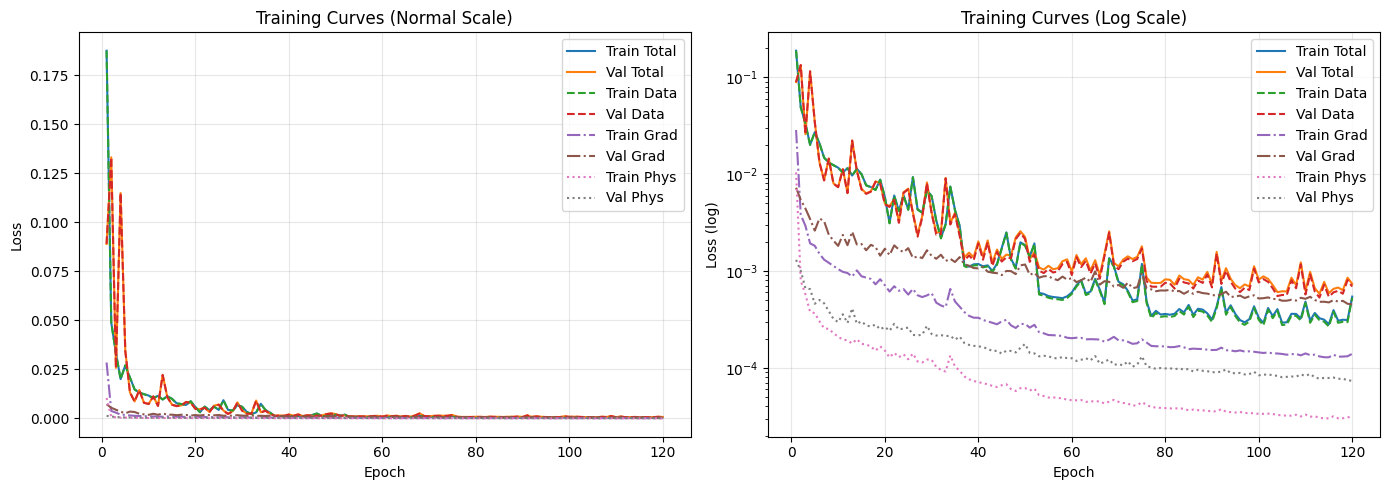

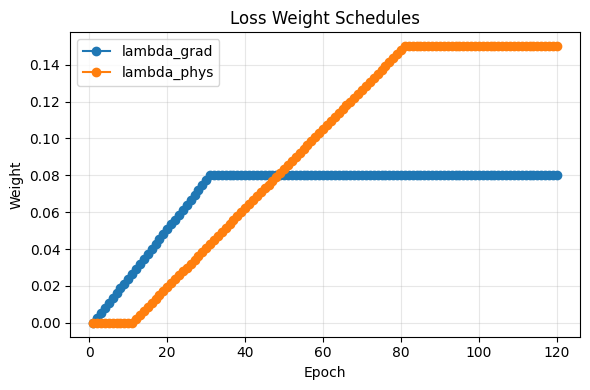

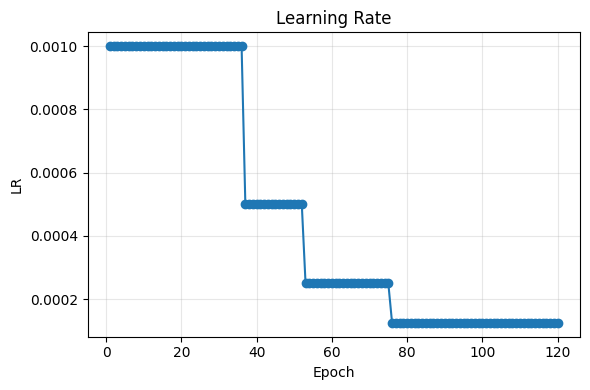

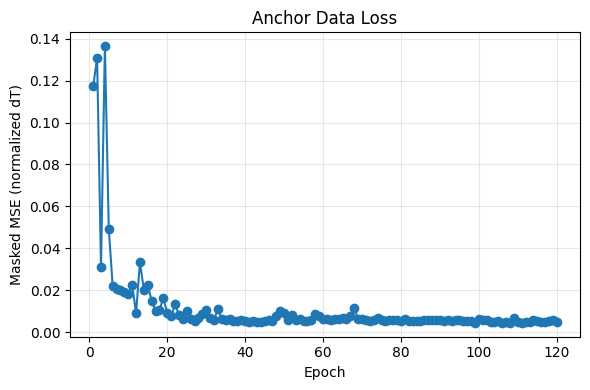


Training complete.
Best validation loss: 0.000581325305726944
Best epoch: 113


In [9]:
# --------------------------------------------------
# Cell 9: Multi-scale training loop
# --------------------------------------------------
from copy import deepcopy
from IPython.display import clear_output

# -----------------------------
# Training config
# -----------------------------
NUM_EPOCHS = 120
PLOT_EVERY = 5
GRAD_CLIP = 1.0
WEIGHT_DECAY = 1e-5

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    min_lr=1e-5
)

# -----------------------------
# History containers
# -----------------------------
train_total_hist = []
train_data_hist  = []
train_grad_hist  = []
train_phys_hist  = []

val_total_hist = []
val_data_hist  = []
val_grad_hist  = []
val_phys_hist  = []

anchor_data_hist = []

lambda_grad_hist = []
lambda_phys_hist = []
lr_hist = []

best_val_loss = float("inf")
best_epoch = -1
best_state = None


# --------------------------------------------------
# Evaluation helpers
# --------------------------------------------------
def evaluate_loader(model, loader, epoch):
    model.eval()

    total_loss = 0.0
    total_data = 0.0
    total_grad = 0.0
    total_phys = 0.0
    total_count = 0

    with torch.no_grad():
        for xb, yb, mb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            mb = mb.to(device)

            pred = model(xb)
            loss_dict = compute_loss(pred, yb, xb, mb, epoch=epoch)

            bs = xb.size(0)
            total_loss += loss_dict["loss_total"].item() * bs
            total_data += loss_dict["loss_data"].item() * bs
            total_grad += loss_dict["loss_grad"].item() * bs
            total_phys += loss_dict["loss_phys"].item() * bs
            total_count += bs

    return {
        "loss_total": total_loss / total_count,
        "loss_data": total_data / total_count,
        "loss_grad": total_grad / total_count,
        "loss_phys": total_phys / total_count,
    }


def evaluate_anchor_data_only(model, loader):
    """
    Monitor only masked supervised loss on real anchors.
    No physics/grad weighting here, just direct data fit.
    """
    model.eval()

    total_data = 0.0
    total_count = 0

    with torch.no_grad():
        for xb, yb, mb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            mb = mb.to(device)

            pred = model(xb)

            data_sqerr = (pred - yb) ** 2
            loss_data = masked_mean(data_sqerr, mb)

            bs = xb.size(0)
            total_data += loss_data.item() * bs
            total_count += bs

    return total_data / total_count


# --------------------------------------------------
# Plot helper
# --------------------------------------------------
def plot_training_progress():
    epochs = np.arange(1, len(train_total_hist) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Normal scale
    axes[0].plot(epochs, train_total_hist, label="Train Total")
    axes[0].plot(epochs, val_total_hist, label="Val Total")
    axes[0].plot(epochs, train_data_hist, "--", label="Train Data")
    axes[0].plot(epochs, val_data_hist, "--", label="Val Data")
    axes[0].plot(epochs, train_grad_hist, "-.", label="Train Grad")
    axes[0].plot(epochs, val_grad_hist, "-.", label="Val Grad")
    axes[0].plot(epochs, train_phys_hist, ":", label="Train Phys")
    axes[0].plot(epochs, val_phys_hist, ":", label="Val Phys")
    axes[0].set_title("Training Curves (Normal Scale)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Log scale
    axes[1].plot(epochs, train_total_hist, label="Train Total")
    axes[1].plot(epochs, val_total_hist, label="Val Total")
    axes[1].plot(epochs, train_data_hist, "--", label="Train Data")
    axes[1].plot(epochs, val_data_hist, "--", label="Val Data")
    axes[1].plot(epochs, train_grad_hist, "-.", label="Train Grad")
    axes[1].plot(epochs, val_grad_hist, "-.", label="Val Grad")
    axes[1].plot(epochs, train_phys_hist, ":", label="Train Phys")
    axes[1].plot(epochs, val_phys_hist, ":", label="Val Phys")
    axes[1].set_yscale("log")
    axes[1].set_title("Training Curves (Log Scale)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss (log)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, lambda_grad_hist, marker="o", label="lambda_grad")
    plt.plot(epochs, lambda_phys_hist, marker="o", label="lambda_phys")
    plt.title("Loss Weight Schedules")
    plt.xlabel("Epoch")
    plt.ylabel("Weight")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, lr_hist, marker="o")
    plt.title("Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, anchor_data_hist, marker="o")
    plt.title("Anchor Data Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Masked MSE (normalized dT)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Training loop
# --------------------------------------------------
for epoch in range(NUM_EPOCHS):
    model.train()

    running_total = 0.0
    running_data = 0.0
    running_grad = 0.0
    running_phys = 0.0
    total_count = 0

    current_lambda_grad = get_lambda_grad(epoch)
    current_lambda_phys = get_lambda_phys(epoch)

    lambda_grad_hist.append(current_lambda_grad)
    lambda_phys_hist.append(current_lambda_phys)

    for xb, yb, mb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        mb = mb.to(device)

        optimizer.zero_grad()

        pred = model(xb)
        loss_dict = compute_loss(pred, yb, xb, mb, epoch=epoch)

        loss = loss_dict["loss_total"]
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        bs = xb.size(0)
        running_total += loss_dict["loss_total"].item() * bs
        running_data  += loss_dict["loss_data"].item() * bs
        running_grad  += loss_dict["loss_grad"].item() * bs
        running_phys  += loss_dict["loss_phys"].item() * bs
        total_count += bs

    train_metrics = {
        "loss_total": running_total / total_count,
        "loss_data": running_data / total_count,
        "loss_grad": running_grad / total_count,
        "loss_phys": running_phys / total_count,
    }

    val_metrics = evaluate_loader(model, val_loader, epoch=epoch)
    anchor_data = evaluate_anchor_data_only(model, anchor_eval_loader)

    train_total_hist.append(train_metrics["loss_total"])
    train_data_hist.append(train_metrics["loss_data"])
    train_grad_hist.append(train_metrics["loss_grad"])
    train_phys_hist.append(train_metrics["loss_phys"])

    val_total_hist.append(val_metrics["loss_total"])
    val_data_hist.append(val_metrics["loss_data"])
    val_grad_hist.append(val_metrics["loss_grad"])
    val_phys_hist.append(val_metrics["loss_phys"])

    anchor_data_hist.append(anchor_data)

    current_lr = optimizer.param_groups[0]["lr"]
    lr_hist.append(current_lr)

    # Save best validation model after a small warmup
    if epoch >= 5 and val_metrics["loss_total"] < best_val_loss:
        best_val_loss = val_metrics["loss_total"]
        best_epoch = epoch + 1
        best_state = deepcopy(model.state_dict())

    scheduler.step(val_metrics["loss_total"])

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
            f"lr={current_lr:.6f} | "
            f"lambda_grad={current_lambda_grad:.4f} | "
            f"lambda_phys={current_lambda_phys:.4f} | "
            f"Train={train_metrics['loss_total']:.6f} | "
            f"TrainData={train_metrics['loss_data']:.6f} | "
            f"TrainGrad={train_metrics['loss_grad']:.6f} | "
            f"TrainPhys={train_metrics['loss_phys']:.6f} | "
            f"Val={val_metrics['loss_total']:.6f} | "
            f"ValData={val_metrics['loss_data']:.6f} | "
            f"ValGrad={val_metrics['loss_grad']:.6f} | "
            f"ValPhys={val_metrics['loss_phys']:.6f} | "
            f"AnchorData={anchor_data:.6f}"
        )

    if (epoch + 1) % PLOT_EVERY == 0 or (epoch + 1) == NUM_EPOCHS:
        clear_output(wait=True)
        print(
            f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
            f"Best Val Loss: {best_val_loss:.6f} | "
            f"Best Epoch: {best_epoch} | "
            f"lr={current_lr:.6f} | "
            f"lambda_grad={current_lambda_grad:.4f} | "
            f"lambda_phys={current_lambda_phys:.4f}"
        )
        plot_training_progress()

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)
else:
    print("Warning: no best checkpoint saved.")

print("\nTraining complete.")
print("Best validation loss:", best_val_loss)
print("Best epoch:", best_epoch)

Saved evaluation CSVs:
  /home/aditya_chaudhry/thermal_aware_mac/results/multiscale_cnn_pinn/synthetic_test_results.csv
  /home/aditya_chaudhry/thermal_aware_mac/results/multiscale_cnn_pinn/anchor_eval_results.csv
  /home/aditya_chaudhry/thermal_aware_mac/results/multiscale_cnn_pinn/anchor_finetune_results.csv
  /home/aditya_chaudhry/thermal_aware_mac/results/multiscale_cnn_pinn/all_eval_results.csv

Synthetic test set summary
--------------------------
        samples: 397
      MAE(temp): 0.032153
     RMSE(temp): 0.039175
  Max abs error: 0.121764
 Peak abs error: 0.052760
  Avg abs error: 0.022481
 Grad abs error: 0.018512
 Phys resid MSE: 8.310266e-05

Held-out anchor eval summary (2x2, 4x4)
---------------------------------------
        samples: 12
      MAE(temp): 0.124586
     RMSE(temp): 0.132965
  Max abs error: 0.187733
 Peak abs error: 0.132737
  Avg abs error: 0.123770
 Grad abs error: 0.047897
 Phys resid MSE: 2.897320e-04

Anchor fine-tune summary (8x8, 16x16)
---------

,split,sample_id,global_idx,mae_temp,rmse_temp,max_abs_error,peak_true,peak_pred,peak_abs_error,avg_true,avg_pred,avg_abs_error,grad_true,grad_pred,grad_abs_error,phys_residual_mse,architecture,workload,N,source
0,synthetic_test,synthetic_standard_stripes_2_00000,0,0.170941,0.179079,0.227192,27.299122,27.078228,0.220894,27.174179,27.003239,0.170940,0.124943,0.076849,0.058110,0.000304,standard,stripes,2,synthetic
1,synthetic_test,synthetic_standard_uniform_2_00001,1,0.084142,0.097375,0.160528,29.760523,29.731834,0.028688,29.760523,29.676380,0.084143,0.000000,0.065920,0.065920,0.000280,standard,uniform,2,synthetic
2,synthetic_test,synthetic_standard_multihotspot_2_00006,6,0.081970,0.095545,0.158594,29.740870,29.714436,0.026434,29.740870,29.658899,0.081970,0.000000,0.066080,0.066080,0.000281,standard,multihotspot,2,synthetic
3,synthetic_test,synthetic_standard_hotspot_2_00010,10,0.049247,0.051649,0.068083,28.950752,28.925396,0.025356,28.950752,28.901505,0.049248,0.000000,0.021363,0.021363,0.000028,standard,hotspot,2,synthetic
4,synthetic_test,synthetic_standard_checkerboard_2_00012,12,0.090843,0.099724,0.132318,27.288889,27.378000,0.089111,27.222811,27.313654,0.090843,0.132154,0.064417,0.067738,0.000500,standard,checkerboard,2,synthetic


,split,sample_id,global_idx,mae_temp,rmse_temp,max_abs_error,peak_true,peak_pred,peak_abs_error,avg_true,avg_pred,avg_abs_error,grad_true,grad_pred,grad_abs_error,phys_residual_mse,architecture,workload,N,source
0,anchor_eval,case_02250,2250,0.148355,0.152889,0.186562,27.029341,27.178053,0.148712,26.964825,27.113178,0.148354,0.129032,0.069737,0.059295,0.000393,standard,checkerboard,2,anchor_real
1,anchor_eval,case_02251,2251,0.149110,0.177199,0.271706,26.139668,26.161375,0.021708,25.982412,26.131521,0.149109,0.124999,0.040988,0.134359,0.000985,standard,hotspot,2,anchor_real
2,anchor_eval,case_02252,2252,0.025459,0.030557,0.050644,28.929646,28.980289,0.050644,28.929646,28.955105,0.025459,0.000000,0.022231,0.022231,0.000033,standard,uniform,2,anchor_real
3,anchor_eval,case_02253,2253,0.304521,0.306285,0.338650,27.357809,27.696459,0.338650,27.357809,27.662331,0.304522,0.000000,0.041798,0.041798,0.000154,systolic,checkerboard,2,anchor_real
4,anchor_eval,case_02254,2254,0.158965,0.169134,0.199118,28.647993,28.448875,0.199118,28.536701,28.377735,0.158966,0.150002,0.080089,0.069913,0.000611,systolic,hotspot,2,anchor_real


,split,sample_id,global_idx,mae_temp,rmse_temp,max_abs_error,peak_true,peak_pred,peak_abs_error,avg_true,avg_pred,avg_abs_error,grad_true,grad_pred,grad_abs_error,phys_residual_mse,architecture,workload,N,source
0,anchor_finetune,case_02262,2262,0.022588,0.025817,0.051239,27.074678,27.051334,0.023344,26.964821,26.980814,0.015993,0.074674,0.071519,0.017475,0.000081,standard,checkerboard,8,anchor_real
1,anchor_finetune,case_02263,2263,0.033975,0.048806,0.144316,27.512306,27.370956,0.141350,25.982410,25.982143,0.000267,0.158934,0.154160,0.031266,0.000172,standard,hotspot,8,anchor_real
2,anchor_finetune,case_02264,2264,0.033696,0.036708,0.061096,28.929646,28.990742,0.061096,28.929644,28.963341,0.033697,0.000000,0.010512,0.010512,0.000025,standard,uniform,8,anchor_real
3,anchor_finetune,case_02265,2265,0.059074,0.064800,0.146519,28.071184,28.116503,0.045319,27.848988,27.908060,0.059072,0.039171,0.036457,0.017074,0.000045,systolic,checkerboard,8,anchor_real
4,anchor_finetune,case_02266,2266,0.046797,0.058915,0.162016,29.626242,29.788258,0.162016,28.659504,28.634335,0.025169,0.210836,0.221024,0.035698,0.000217,systolic,hotspot,8,anchor_real


Synthetic test grouped by N / architecture / workload


...

,mae_temp,rmse_temp,max_abs_error,peak_abs_error,grad_abs_error,phys_residual_mse
N,,,,,,
2,0.067063,0.074989,0.107684,0.061066,0.046412,0.000221
4,0.054283,0.063018,0.118266,0.066620,0.034672,0.000223
8,0.031201,0.038478,0.096051,0.047363,0.019536,0.000079
16,0.021337,0.027732,0.097236,0.046739,0.012552,0.000042
32,0.021081,0.027326,0.121634,0.050286,0.009274,0.000028
64,0.024177,0.030952,0.186736,0.054162,0.008672,0.000029


Held-out anchor eval grouped by N


,mae_temp,rmse_temp,max_abs_error,peak_abs_error,grad_abs_error,phys_residual_mse
N,,,,,,
2,0.152926,0.161808,0.204066,0.153941,0.061892,0.00038
4,0.096245,0.104123,0.171399,0.111533,0.033903,0.00020


Anchor fine-tune grouped by N


,mae_temp,rmse_temp,max_abs_error,peak_abs_error,grad_abs_error,phys_residual_mse
N,,,,,,
8,0.039599,0.047118,0.109894,0.080253,0.022224,0.000106
16,0.040799,0.049043,0.125119,0.075699,0.016187,0.000062


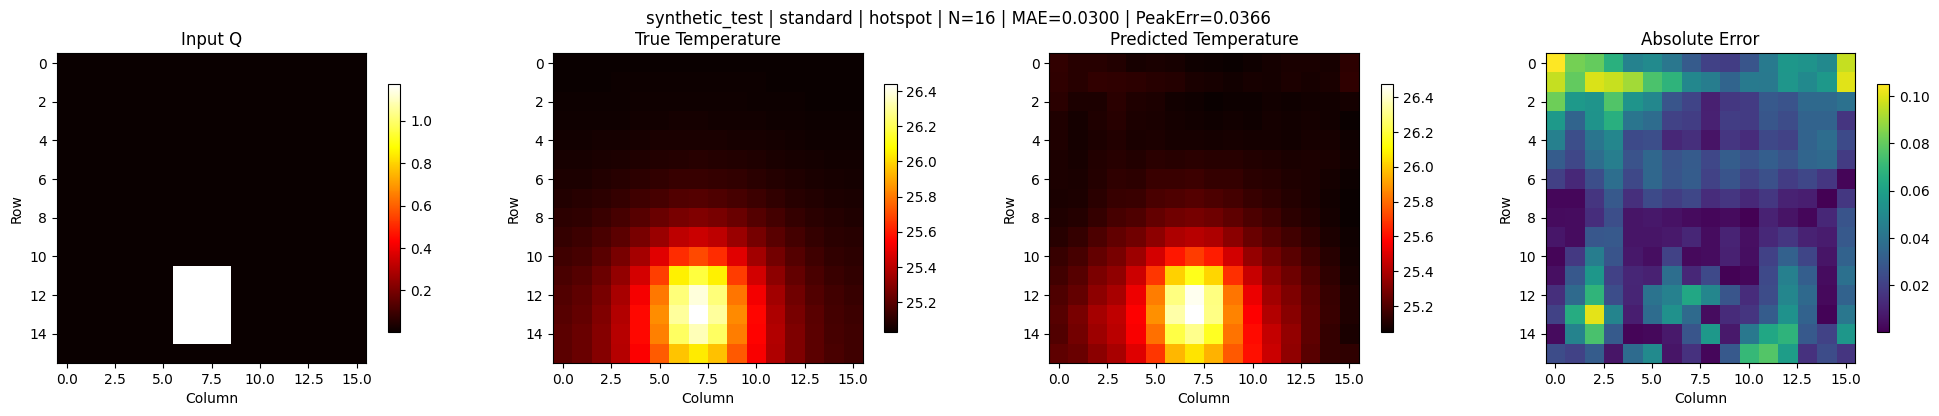

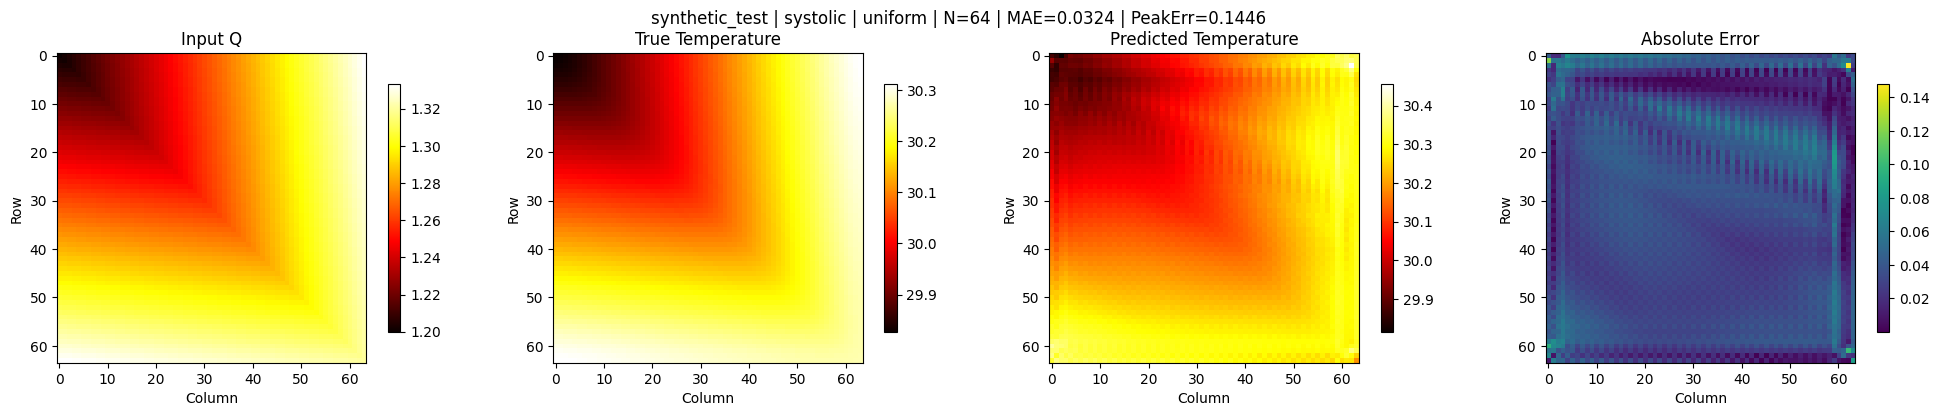

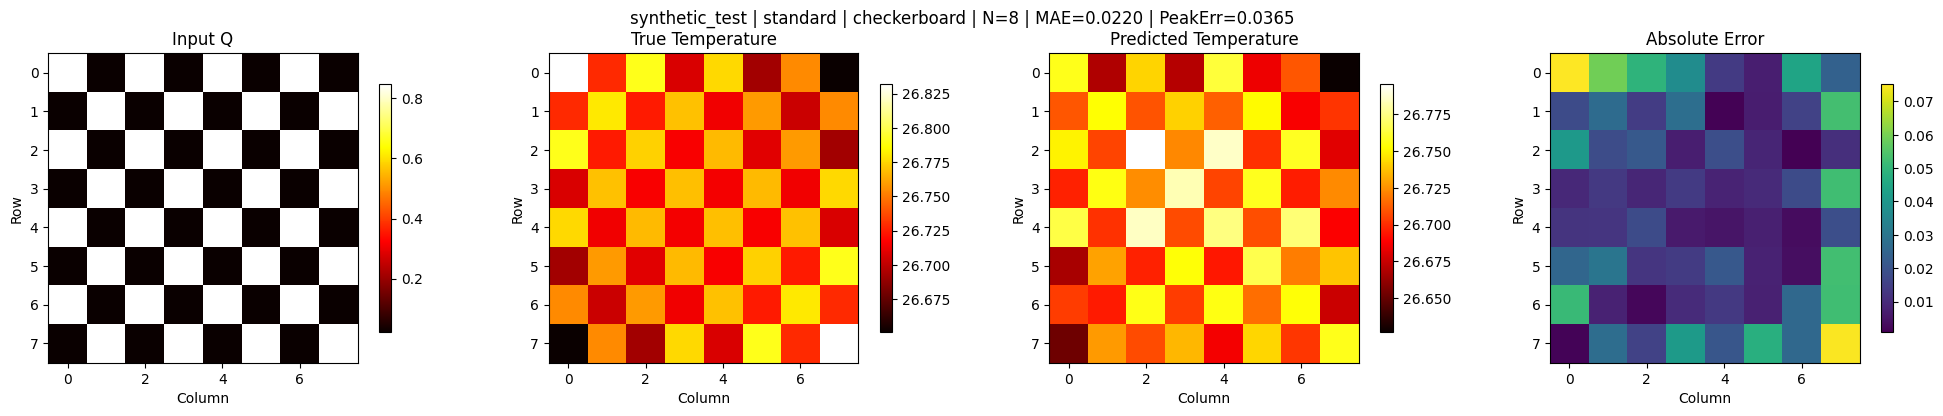

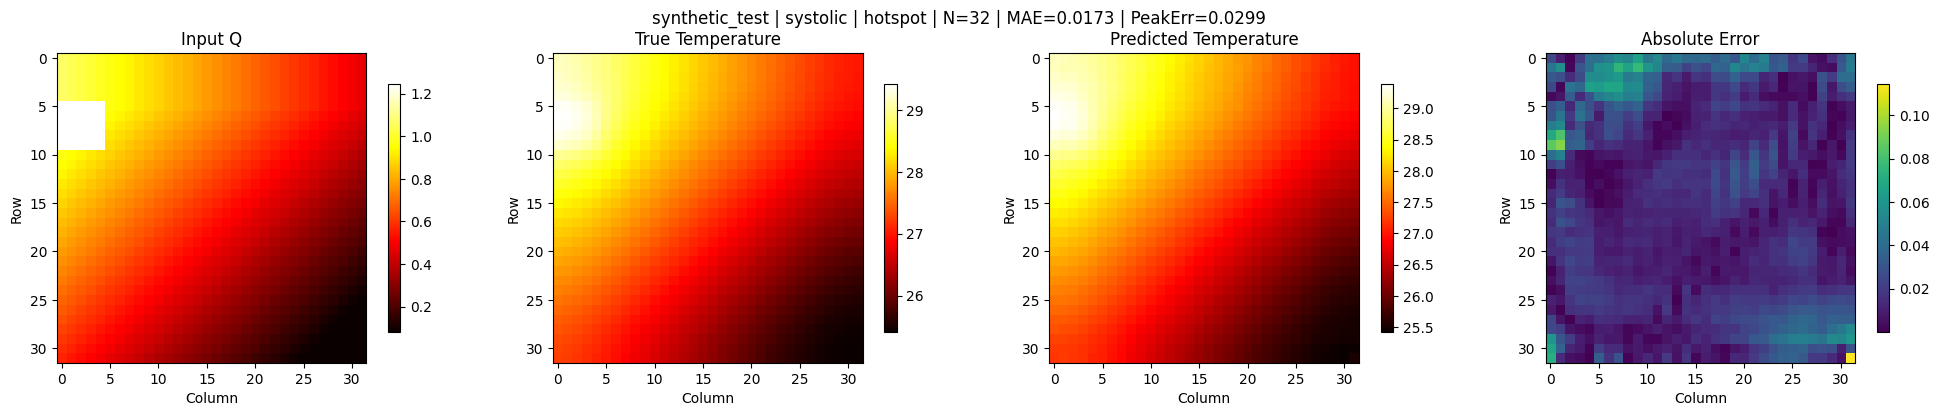

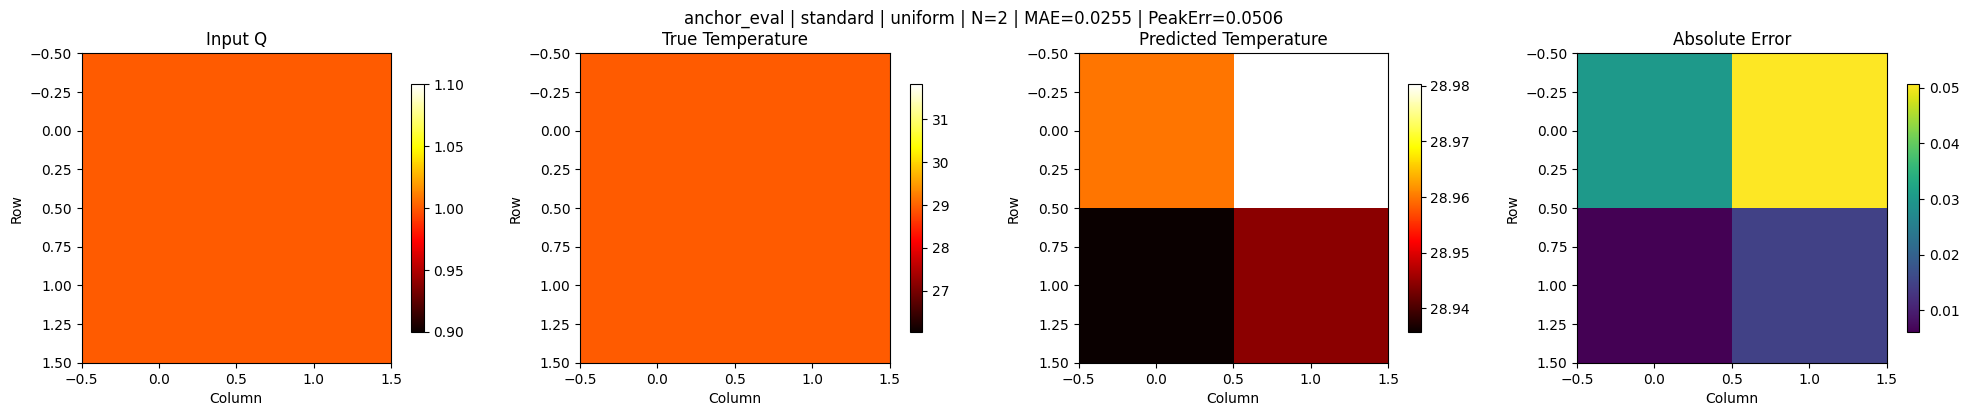

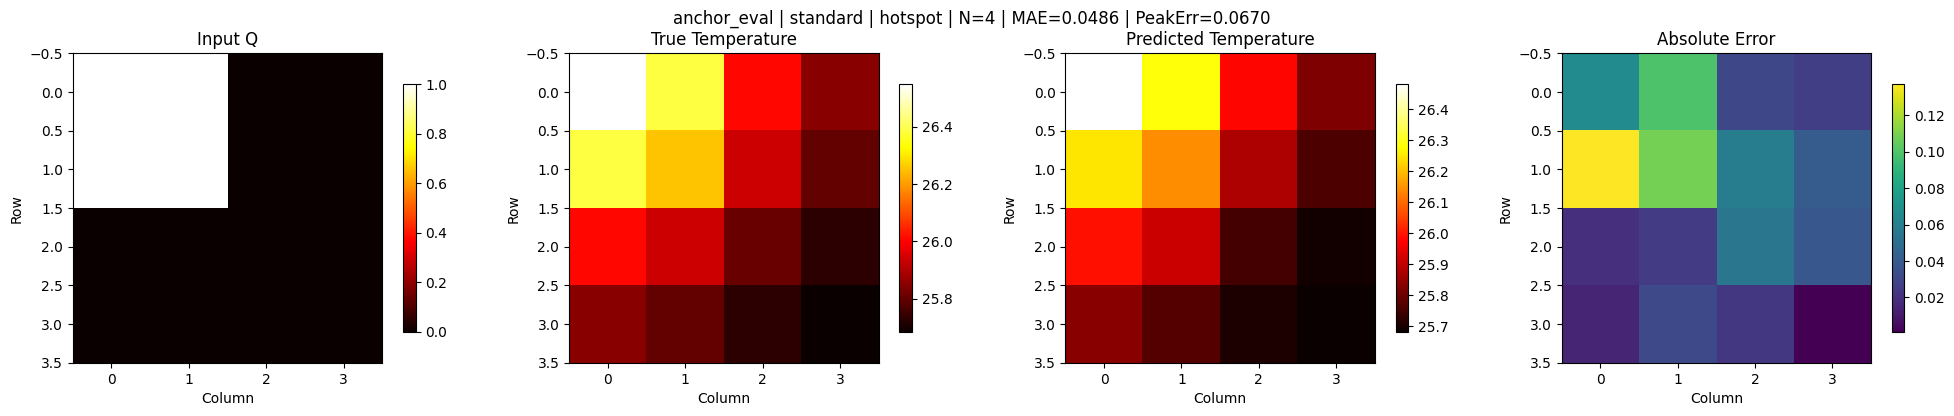

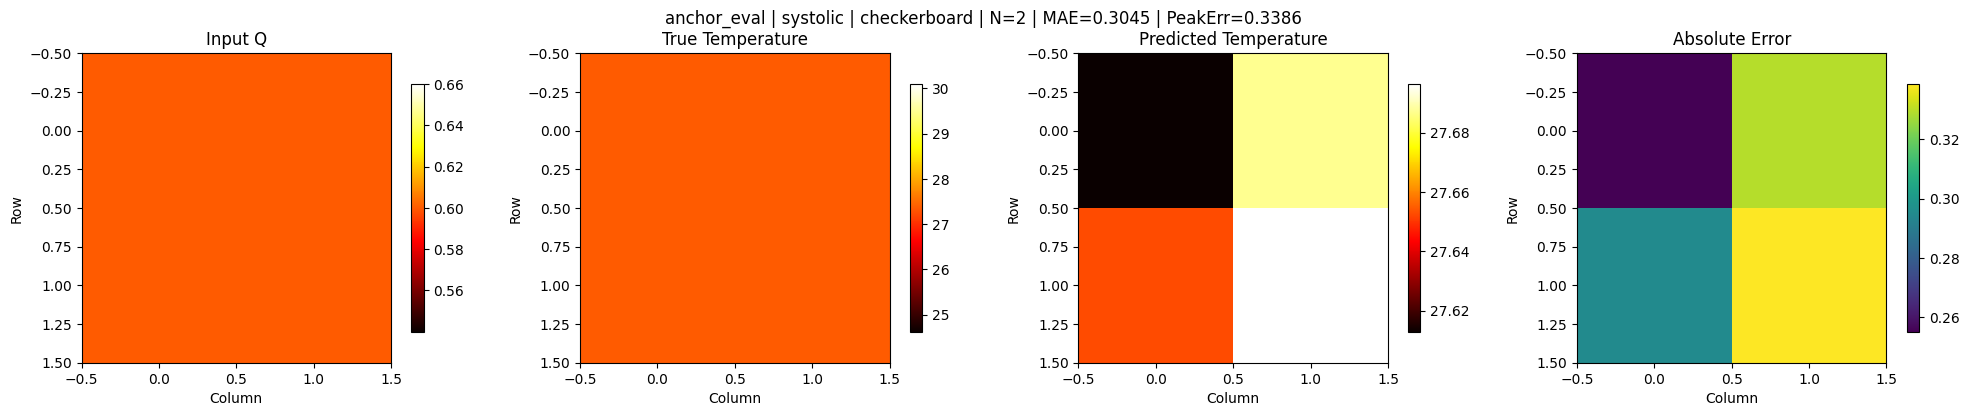

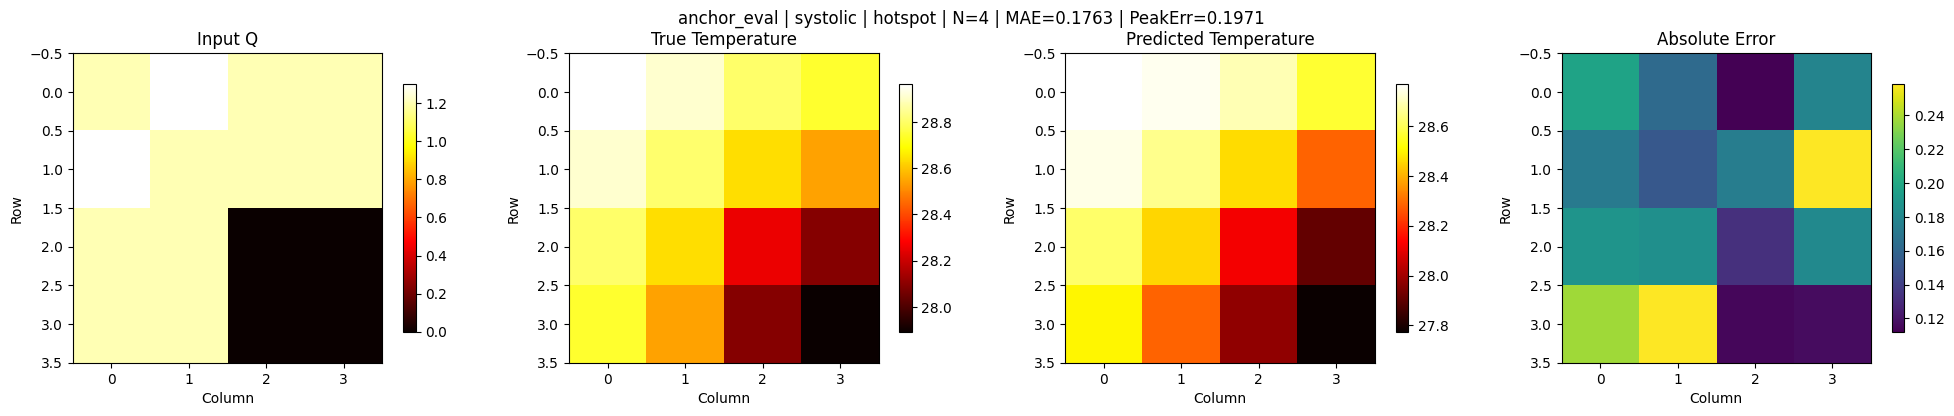

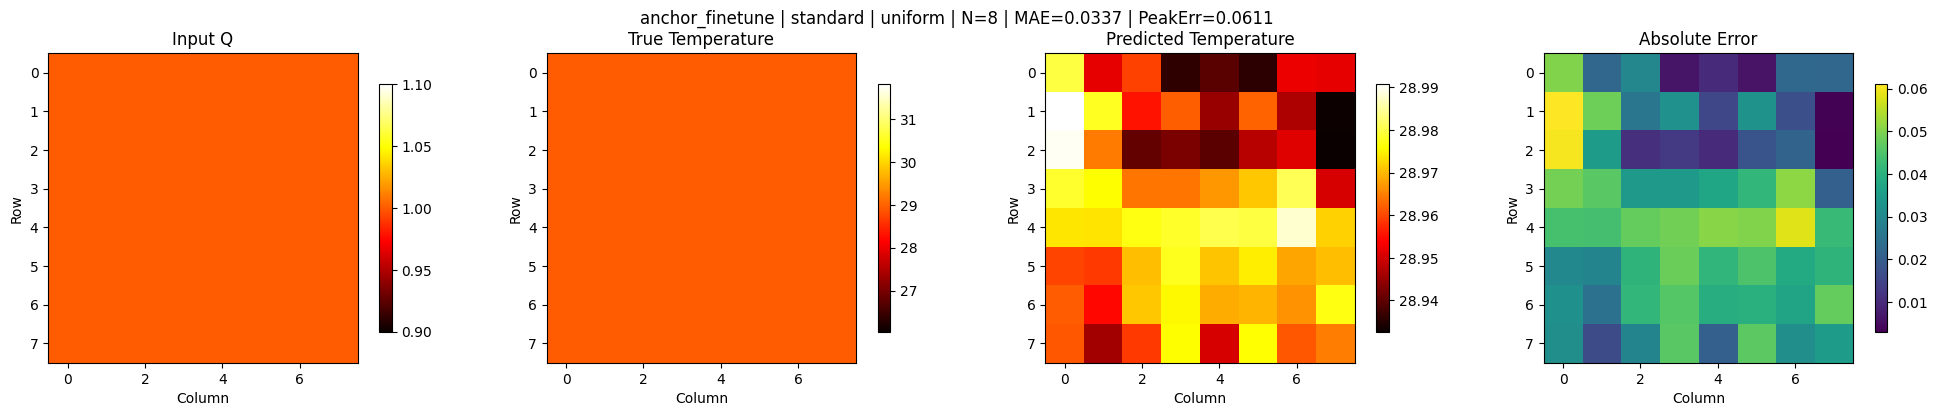

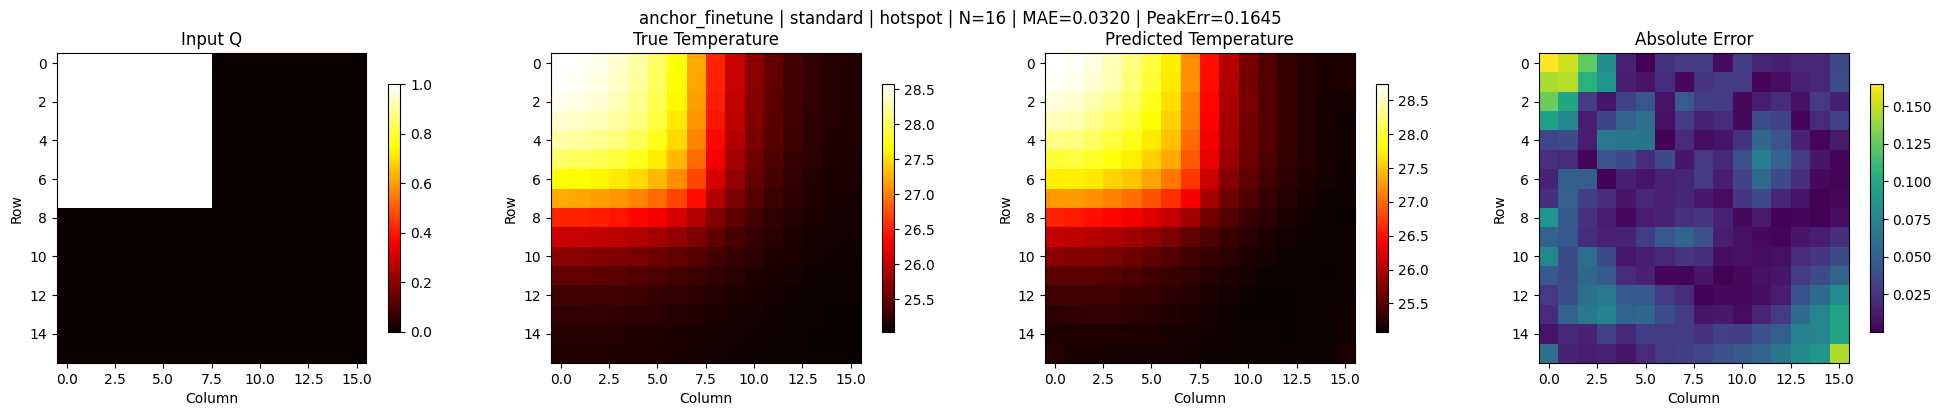

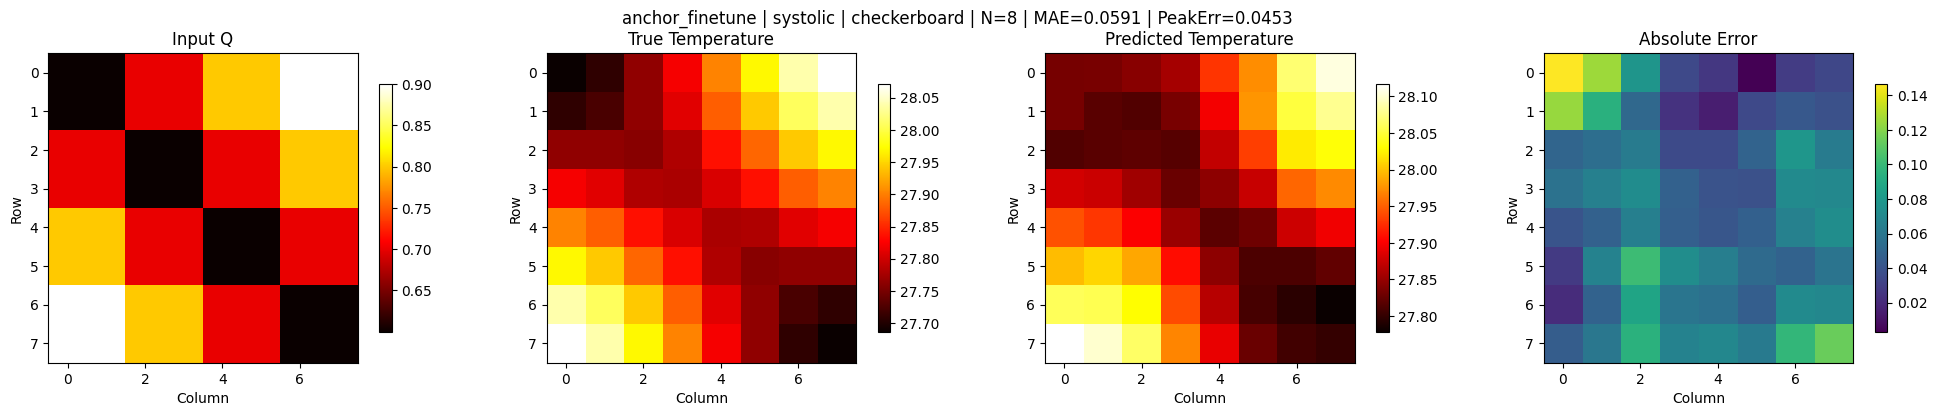

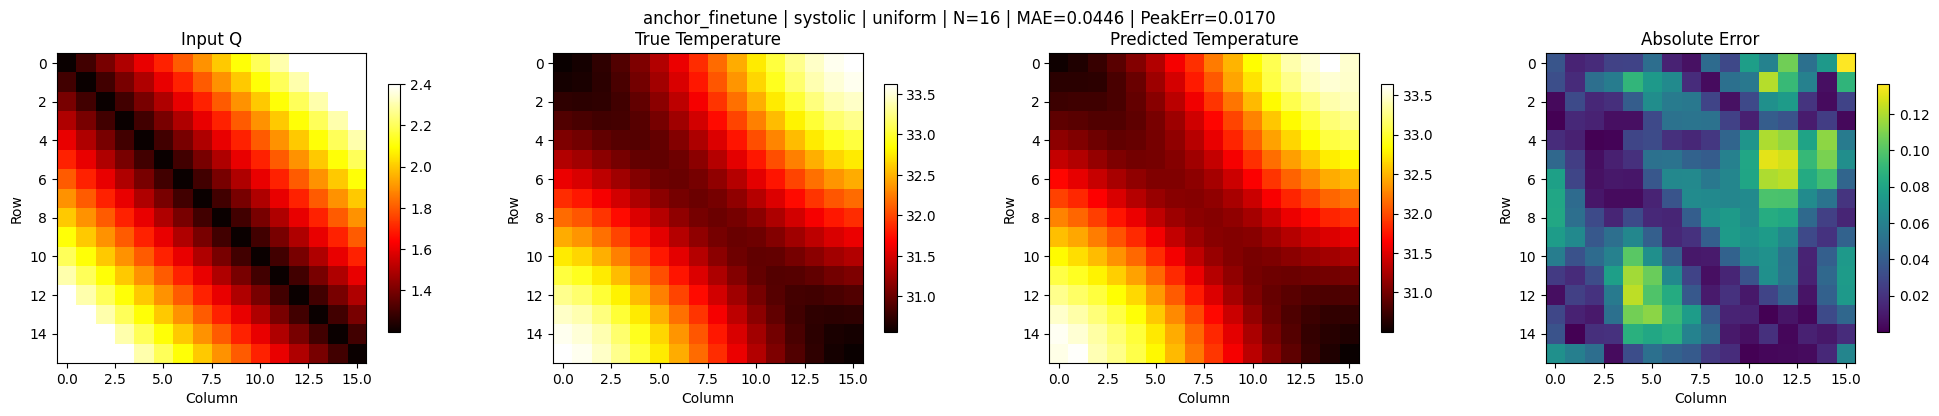

Worst 10 synthetic-test samples by MAE


,sample_id,N,architecture,workload,mae_temp,peak_abs_error,grad_abs_error,phys_residual_mse
20,synthetic_standard_stripes_2_00099,2,standard,stripes,0.217370,0.271894,0.065320,0.000380
21,synthetic_systolic_hotspot_2_00000,2,systolic,hotspot,0.214145,0.166353,0.042575,0.000157
7,synthetic_standard_quadrant_2_00034,2,standard,quadrant,0.171887,0.122902,0.084023,0.000680
0,synthetic_standard_stripes_2_00000,2,standard,stripes,0.170941,0.220894,0.058110,0.000304
56,synthetic_standard_multihotspot_4_00075,4,standard,multihotspot,0.148781,0.184629,0.062162,0.000516
13,synthetic_standard_quadrant_2_00048,2,standard,quadrant,0.142164,0.048782,0.099428,0.000961
11,synthetic_standard_checkerboard_2_00039,2,standard,checkerboard,0.133609,0.129309,0.057208,0.000366
43,synthetic_standard_hotspot_4_00015,4,standard,hotspot,0.131821,0.203690,0.050207,0.000408
41,synthetic_standard_hotspot_4_00007,4,standard,hotspot,0.127364,0.085049,0.032396,0.000222
52,synthetic_standard_stripes_4_00044,4,standard,stripes,0.111935,0.135317,0.046817,0.000467


Worst 10 held-out anchor-eval samples by MAE


,sample_id,N,architecture,workload,mae_temp,peak_abs_error,grad_abs_error,phys_residual_mse
3,case_02253,2,systolic,checkerboard,0.304521,0.338650,0.041798,0.000154
10,case_02260,4,systolic,hotspot,0.176336,0.197111,0.045659,0.000346
4,case_02254,2,systolic,hotspot,0.158965,0.199118,0.069913,0.000611
1,case_02251,2,standard,hotspot,0.149110,0.021708,0.134359,0.000985
0,case_02250,2,standard,checkerboard,0.148355,0.148712,0.059295,0.000393
11,case_02261,4,systolic,uniform,0.142105,0.140631,0.048508,0.000347
5,case_02255,2,systolic,uniform,0.131148,0.164818,0.043755,0.000102
9,case_02259,4,systolic,checkerboard,0.127054,0.147530,0.024074,0.000080
8,case_02258,4,standard,uniform,0.048761,0.105698,0.026649,0.000090
7,case_02257,4,standard,hotspot,0.048605,0.066998,0.029478,0.000193


Worst 10 anchor fine-tune samples by MAE


,sample_id,N,architecture,workload,mae_temp,peak_abs_error,grad_abs_error,phys_residual_mse
10,case_02272,16,systolic,hotspot,0.064410,0.082649,0.022984,0.000101
3,case_02265,8,systolic,checkerboard,0.059074,0.045319,0.017074,0.000045
4,case_02266,8,systolic,hotspot,0.046797,0.162016,0.035698,0.000217
11,case_02273,16,systolic,uniform,0.044571,0.017006,0.024241,0.000121
5,case_02267,8,systolic,uniform,0.041463,0.048391,0.021318,0.000098
9,case_02271,16,systolic,checkerboard,0.036978,0.105944,0.012995,0.000035
1,case_02263,8,standard,hotspot,0.033975,0.141350,0.031266,0.000172
8,case_02270,16,standard,uniform,0.033902,0.065481,0.008140,0.000017
2,case_02264,8,standard,uniform,0.033696,0.061096,0.010512,0.000025
6,case_02268,16,standard,checkerboard,0.032888,0.018606,0.011703,0.000051


In [10]:
# --------------------------------------------------
# Cell 10: Multi-scale evaluation
#
# Evaluates:
#   - synthetic test set
#   - held-out anchor eval set (2x2, 4x4)
#   - optional anchor fine-tune set (8x8, 16x16)
#
# Reports:
#   - per-sample metrics in physical units
#   - split summaries
#   - grouped summaries by N / architecture / workload
#   - a few qualitative plots
#   - CSV exports
# --------------------------------------------------
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = os.path.join(PROJECT_ROOT, "results", "multiscale_cnn_pinn")
os.makedirs(RESULTS_DIR, exist_ok=True)


# --------------------------------------------------
# Helpers
# --------------------------------------------------
def denorm_q_from_xb(xb):
    """
    Recover physical Q from normalized input tensor xb.
    Assumes channel 0 is Q and the other channels are already in native ranges.
    """
    return xb[:, 0:1, :, :] * X_std + X_mean


def denorm_dt_from_pred(pred_norm):
    """
    Recover physical dT from normalized prediction.
    """
    return pred_norm * Y_std + Y_mean


def safe_grad_stats(arr_2d):
    """
    Compute a simple gradient-magnitude statistic on a 2D array.
    Returns a scalar.
    """
    H, W = arr_2d.shape
    if H < 2 and W < 2:
        return 0.0

    stats = []
    if W >= 2:
        dx = arr_2d[:, 1:] - arr_2d[:, :-1]
        stats.append(np.mean(np.abs(dx)))
    if H >= 2:
        dy = arr_2d[1:, :] - arr_2d[:-1, :]
        stats.append(np.mean(np.abs(dy)))

    return float(np.mean(stats)) if len(stats) > 0 else 0.0


def safe_grad_error(pred_2d, true_2d):
    """
    Mean absolute difference between predicted and true finite differences.
    """
    H, W = pred_2d.shape
    errs = []

    if W >= 2:
        dx_pred = pred_2d[:, 1:] - pred_2d[:, :-1]
        dx_true = true_2d[:, 1:] - true_2d[:, :-1]
        errs.append(np.mean(np.abs(dx_pred - dx_true)))

    if H >= 2:
        dy_pred = pred_2d[1:, :] - pred_2d[:-1, :]
        dy_true = true_2d[1:, :] - true_2d[:-1, :]
        errs.append(np.mean(np.abs(dy_pred - dy_true)))

    return float(np.mean(errs)) if len(errs) > 0 else 0.0


def compute_sample_metrics(pred_temp, true_temp):
    """
    pred_temp, true_temp: [N, N] physical temperature maps
    """
    abs_err = np.abs(pred_temp - true_temp)
    sq_err = (pred_temp - true_temp) ** 2

    mae_temp = float(np.mean(abs_err))
    rmse_temp = float(np.sqrt(np.mean(sq_err)))
    max_abs_error = float(np.max(abs_err))

    peak_true = float(np.max(true_temp))
    peak_pred = float(np.max(pred_temp))
    peak_abs_error = float(abs(peak_pred - peak_true))

    avg_true = float(np.mean(true_temp))
    avg_pred = float(np.mean(pred_temp))
    avg_abs_error = float(abs(avg_pred - avg_true))

    grad_true = safe_grad_stats(true_temp)
    grad_pred = safe_grad_stats(pred_temp)
    grad_abs_error = safe_grad_error(pred_temp, true_temp)

    return {
        "mae_temp": mae_temp,
        "rmse_temp": rmse_temp,
        "max_abs_error": max_abs_error,
        "peak_true": peak_true,
        "peak_pred": peak_pred,
        "peak_abs_error": peak_abs_error,
        "avg_true": avg_true,
        "avg_pred": avg_pred,
        "avg_abs_error": avg_abs_error,
        "grad_true": grad_true,
        "grad_pred": grad_pred,
        "grad_abs_error": grad_abs_error,
    }


def evaluate_dataset(model, loader, dataset, split_name, epoch_for_loss=NUM_EPOCHS - 1):
    """
    Evaluate one dataset/loader pair and return a per-sample dataframe.
    Assumes loader uses shuffle=False.
    """
    model.eval()
    rows = []

    offset = 0

    with torch.no_grad():
        for xb, yb, mb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            mb = mb.to(device)

            pred_norm = model(xb)

            bs = xb.size(0)
            batch_indices = dataset.indices[offset:offset + bs]
            offset += bs

            # Physical-unit tensors
            pred_dT_phys = denorm_dt_from_pred(pred_norm)
            true_dT_phys = denorm_dt_from_pred(yb)
            Q_phys = denorm_q_from_xb(xb)

            # Physics residual on full padded tensor, masked later
            residual = physics_residual(pred_dT_phys, Q_phys, mb)
            residual_sq = residual ** 2

            for b in range(bs):
                global_idx = batch_indices[b]
                meta = meta_df.iloc[global_idx]

                N = int(meta["N"])

                pred_dT_np = pred_dT_phys[b, 0, :N, :N].detach().cpu().numpy()
                true_dT_np = true_dT_phys[b, 0, :N, :N].detach().cpu().numpy()
                Q_np = Q_phys[b, 0, :N, :N].detach().cpu().numpy()

                pred_temp = pred_dT_np + T_AMB
                true_temp = true_dT_np + T_AMB

                sample_metrics = compute_sample_metrics(pred_temp, true_temp)

                # Physics residual MSE over valid region
                sample_residual_mse = masked_mean(
                    residual_sq[b:b+1],
                    mb[b:b+1]
                ).item()

                rows.append({
                    "split": split_name,
                    "sample_id": meta.get("sample_id", f"idx_{global_idx:05d}"),
                    "global_idx": int(global_idx),
                    **sample_metrics,
                    "phys_residual_mse": float(sample_residual_mse),
                    "architecture": meta["architecture"],
                    "workload": meta["workload"],
                    "N": int(meta["N"]),
                    "source": meta["source"],
                })

    return pd.DataFrame(rows)


def print_split_summary(df, title):
    print(title)
    print("-" * len(title))
    print(f"{'samples:':>16} {len(df)}")
    print(f"{'MAE(temp):':>16} {df['mae_temp'].mean():.6f}")
    print(f"{'RMSE(temp):':>16} {df['rmse_temp'].mean():.6f}")
    print(f"{'Max abs error:':>16} {df['max_abs_error'].mean():.6f}")
    print(f"{'Peak abs error:':>16} {df['peak_abs_error'].mean():.6f}")
    print(f"{'Avg abs error:':>16} {df['avg_abs_error'].mean():.6f}")
    print(f"{'Grad abs error:':>16} {df['grad_abs_error'].mean():.6f}")
    print(f"{'Phys resid MSE:':>16} {df['phys_residual_mse'].mean():.6e}")
    print()


def grouped_summary(df, group_cols):
    return (
        df.groupby(group_cols)[
            ["mae_temp", "rmse_temp", "max_abs_error", "peak_abs_error", "grad_abs_error", "phys_residual_mse"]
        ]
        .mean()
        .sort_index()
    )


def find_sample_in_results(df_results, architecture=None, workload=None, N=None, source=None):
    q = pd.Series(True, index=df_results.index)
    if architecture is not None:
        q &= (df_results["architecture"] == architecture)
    if workload is not None:
        q &= (df_results["workload"] == workload)
    if N is not None:
        q &= (df_results["N"] == N)
    if source is not None:
        q &= (df_results["source"] == source)

    subset = df_results[q]
    if len(subset) == 0:
        return None
    return subset.iloc[0]


def plot_case_from_results(df_results, row_obj):
    """
    row_obj: one row from results dataframe
    """
    if row_obj is None:
        print("Requested case not found.")
        return

    global_idx = int(row_obj["global_idx"])
    N = int(row_obj["N"])

    x_norm = torch.tensor(X[global_idx:global_idx+1], dtype=torch.float32).to(device)
    y_norm = torch.tensor(Y[global_idx:global_idx+1], dtype=torch.float32).to(device)
    m = torch.tensor(MASK[global_idx:global_idx+1], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pred_norm = model(x_norm)

        pred_dT = denorm_dt_from_pred(pred_norm)[0, 0, :N, :N].cpu().numpy()
        true_dT = denorm_dt_from_pred(y_norm)[0, 0, :N, :N].cpu().numpy()
        q_phys = denorm_q_from_xb(x_norm)[0, 0, :N, :N].cpu().numpy()

        pred_temp = pred_dT + T_AMB
        true_temp = true_dT + T_AMB
        abs_err = np.abs(pred_temp - true_temp)

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    im0 = axes[0].imshow(q_phys, cmap="hot", interpolation="nearest")
    axes[0].set_title("Input Q")
    axes[0].set_xlabel("Column")
    axes[0].set_ylabel("Row")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(true_temp, cmap="hot", interpolation="nearest")
    axes[1].set_title("True Temperature")
    axes[1].set_xlabel("Column")
    axes[1].set_ylabel("Row")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    im2 = axes[2].imshow(pred_temp, cmap="hot", interpolation="nearest")
    axes[2].set_title("Predicted Temperature")
    axes[2].set_xlabel("Column")
    axes[2].set_ylabel("Row")
    plt.colorbar(im2, ax=axes[2], shrink=0.8)

    im3 = axes[3].imshow(abs_err, cmap="viridis", interpolation="nearest")
    axes[3].set_title("Absolute Error")
    axes[3].set_xlabel("Column")
    axes[3].set_ylabel("Row")
    plt.colorbar(im3, ax=axes[3], shrink=0.8)

    fig.suptitle(
        f"{row_obj['split']} | {row_obj['architecture']} | {row_obj['workload']} | N={N} | "
        f"MAE={row_obj['mae_temp']:.4f} | PeakErr={row_obj['peak_abs_error']:.4f}"
    )
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Run evaluation
# --------------------------------------------------
synthetic_test_df = evaluate_dataset(model, test_loader, test_set, split_name="synthetic_test")
anchor_eval_df = evaluate_dataset(model, anchor_eval_loader, anchor_eval_set, split_name="anchor_eval")
anchor_ft_df = evaluate_dataset(model, anchor_ft_loader, anchor_ft_set, split_name="anchor_finetune")

all_eval_df = pd.concat([synthetic_test_df, anchor_eval_df, anchor_ft_df], ignore_index=True)

# Save raw results
synthetic_test_path = os.path.join(RESULTS_DIR, "synthetic_test_results.csv")
anchor_eval_path = os.path.join(RESULTS_DIR, "anchor_eval_results.csv")
anchor_ft_path = os.path.join(RESULTS_DIR, "anchor_finetune_results.csv")
all_eval_path = os.path.join(RESULTS_DIR, "all_eval_results.csv")

synthetic_test_df.to_csv(synthetic_test_path, index=False)
anchor_eval_df.to_csv(anchor_eval_path, index=False)
anchor_ft_df.to_csv(anchor_ft_path, index=False)
all_eval_df.to_csv(all_eval_path, index=False)

print("Saved evaluation CSVs:")
print(" ", synthetic_test_path)
print(" ", anchor_eval_path)
print(" ", anchor_ft_path)
print(" ", all_eval_path)
print()

# --------------------------------------------------
# Split summaries
# --------------------------------------------------
print_split_summary(synthetic_test_df, "Synthetic test set summary")
print_split_summary(anchor_eval_df, "Held-out anchor eval summary (2x2, 4x4)")
print_split_summary(anchor_ft_df, "Anchor fine-tune summary (8x8, 16x16)")

# --------------------------------------------------
# Display a few rows
# --------------------------------------------------
display(synthetic_test_df.head())
display(anchor_eval_df.head())
display(anchor_ft_df.head())

# --------------------------------------------------
# Grouped summaries
# --------------------------------------------------
print("Synthetic test grouped by N / architecture / workload")
display(grouped_summary(synthetic_test_df, ["N", "architecture", "workload"]))

print("Held-out anchor eval grouped by N / architecture / workload")
display(grouped_summary(anchor_eval_df, ["N", "architecture", "workload"]))

print("Anchor fine-tune grouped by N / architecture / workload")
display(grouped_summary(anchor_ft_df, ["N", "architecture", "workload"]))

print("Synthetic test grouped by architecture / workload")
display(grouped_summary(synthetic_test_df, ["architecture", "workload"]))

print("Held-out anchor eval grouped by architecture / workload")
display(grouped_summary(anchor_eval_df, ["architecture", "workload"]))

print("Anchor fine-tune grouped by architecture / workload")
display(grouped_summary(anchor_ft_df, ["architecture", "workload"]))

print("Synthetic test grouped by N")
display(grouped_summary(synthetic_test_df, ["N"]))

print("Held-out anchor eval grouped by N")
display(grouped_summary(anchor_eval_df, ["N"]))

print("Anchor fine-tune grouped by N")
display(grouped_summary(anchor_ft_df, ["N"]))

# Save grouped summaries
grouped_summary(synthetic_test_df, ["N", "architecture", "workload"]).to_csv(
    os.path.join(RESULTS_DIR, "synthetic_test_grouped_by_N_arch_workload.csv")
)
grouped_summary(anchor_eval_df, ["N", "architecture", "workload"]).to_csv(
    os.path.join(RESULTS_DIR, "anchor_eval_grouped_by_N_arch_workload.csv")
)
grouped_summary(anchor_ft_df, ["N", "architecture", "workload"]).to_csv(
    os.path.join(RESULTS_DIR, "anchor_finetune_grouped_by_N_arch_workload.csv")
)

# --------------------------------------------------
# Qualitative examples
# --------------------------------------------------
# Representative synthetic cases
synthetic_cases_to_plot = [
    find_sample_in_results(synthetic_test_df, architecture="standard", workload="hotspot", N=16, source="synthetic"),
    find_sample_in_results(synthetic_test_df, architecture="systolic", workload="uniform", N=64, source="synthetic"),
    find_sample_in_results(synthetic_test_df, architecture="standard", workload="checkerboard", N=8, source="synthetic"),
    find_sample_in_results(synthetic_test_df, architecture="systolic", workload="hotspot", N=32, source="synthetic"),
]

for row in synthetic_cases_to_plot:
    if row is not None:
        plot_case_from_results(synthetic_test_df, row)

# Representative held-out anchor cases
anchor_eval_cases_to_plot = [
    find_sample_in_results(anchor_eval_df, architecture="standard", workload="uniform", N=2, source="anchor_real"),
    find_sample_in_results(anchor_eval_df, architecture="standard", workload="hotspot", N=4, source="anchor_real"),
    find_sample_in_results(anchor_eval_df, architecture="systolic", workload="checkerboard", N=2, source="anchor_real"),
    find_sample_in_results(anchor_eval_df, architecture="systolic", workload="hotspot", N=4, source="anchor_real"),
]

for row in anchor_eval_cases_to_plot:
    if row is not None:
        plot_case_from_results(anchor_eval_df, row)

# Representative anchor fine-tune cases
anchor_ft_cases_to_plot = [
    find_sample_in_results(anchor_ft_df, architecture="standard", workload="uniform", N=8, source="anchor_real"),
    find_sample_in_results(anchor_ft_df, architecture="standard", workload="hotspot", N=16, source="anchor_real"),
    find_sample_in_results(anchor_ft_df, architecture="systolic", workload="checkerboard", N=8, source="anchor_real"),
    find_sample_in_results(anchor_ft_df, architecture="systolic", workload="uniform", N=16, source="anchor_real"),
]

for row in anchor_ft_cases_to_plot:
    if row is not None:
        plot_case_from_results(anchor_ft_df, row)

# --------------------------------------------------
# Worst-case diagnostics
# --------------------------------------------------
print("Worst 10 synthetic-test samples by MAE")
display(
    synthetic_test_df.sort_values("mae_temp", ascending=False)[
        ["sample_id", "N", "architecture", "workload", "mae_temp", "peak_abs_error", "grad_abs_error", "phys_residual_mse"]
    ].head(10)
)

print("Worst 10 held-out anchor-eval samples by MAE")
display(
    anchor_eval_df.sort_values("mae_temp", ascending=False)[
        ["sample_id", "N", "architecture", "workload", "mae_temp", "peak_abs_error", "grad_abs_error", "phys_residual_mse"]
    ].head(10)
)

print("Worst 10 anchor fine-tune samples by MAE")
display(
    anchor_ft_df.sort_values("mae_temp", ascending=False)[
        ["sample_id", "N", "architecture", "workload", "mae_temp", "peak_abs_error", "grad_abs_error", "phys_residual_mse"]
    ].head(10)
)

Extrap normalized tensor shapes:
X_extrap     : (60, 5, 256, 256)
Y_extrap     : (60, 1, 256, 256)
MASK_extrap  : (60, 1, 256, 256)

Extrap loader size: 60

Saved extrapolation CSV:
  /home/aditya_chaudhry/thermal_aware_mac/results/multiscale_cnn_pinn/synthetic_extrapolation_results.csv

Synthetic extrapolation summary (128x128, 256x256)
--------------------------------------------------
        samples: 60
      MAE(temp): 0.321225
     RMSE(temp): 0.357757
  Max abs error: 0.745494
 Peak abs error: 0.424621
  Avg abs error: 0.276214
 Grad abs error: 0.009650
 Phys resid MSE: 9.631556e-05



,split,sample_id,local_idx,mae_temp,rmse_temp,max_abs_error,peak_true,peak_pred,peak_abs_error,avg_true,avg_pred,avg_abs_error,grad_true,grad_pred,grad_abs_error,phys_residual_mse,architecture,workload,N,source
0,synthetic_extrapolation,synthetic_extrapolation_standard_stripes_128_0...,0,0.306110,0.342754,0.641888,29.170492,29.041950,0.128542,27.299318,27.395134,0.095816,0.089407,0.074371,0.023607,0.000098,standard,stripes,128,synthetic_extrapolation
1,synthetic_extrapolation,synthetic_extrapolation_standard_uniform_128_0...,1,0.380554,0.382528,0.515429,29.760523,29.619101,0.141422,29.760527,29.379967,0.380560,0.000000,0.004849,0.004849,0.000066,standard,uniform,128,synthetic_extrapolation
2,synthetic_extrapolation,synthetic_extrapolation_standard_stripes_128_0...,2,0.237970,0.305251,0.790138,27.996544,28.509642,0.513098,26.659431,26.892052,0.232620,0.067145,0.058753,0.016820,0.000066,standard,stripes,128,synthetic_extrapolation
3,synthetic_extrapolation,synthetic_extrapolation_standard_hotspot_128_0...,3,0.485783,0.493428,0.666813,29.639587,29.117807,0.521780,25.638523,26.086098,0.447575,0.016554,0.016944,0.008799,0.000117,standard,hotspot,128,synthetic_extrapolation
4,synthetic_extrapolation,synthetic_extrapolation_standard_checkerboard_...,4,0.092040,0.100048,0.616135,27.172606,27.788740,0.616135,27.056087,27.147678,0.091591,0.067097,0.056290,0.012563,0.000078,standard,checkerboard,128,synthetic_extrapolation


Synthetic extrapolation grouped by N / architecture / workload


mae_temp  rmse_temp  max_abs_error  \
N   architecture workload                                           
128 standard     checkerboard  0.091207   0.099531       0.628729   
                 hotspot       0.518651   0.529744       0.669102   
                 multihotspot  0.456960   0.467401       0.643983   
                 quadrant      0.458848   0.478724       0.698683   
                 stripes       0.260307   0.312007       0.683306   
                 uniform       0.227782   0.235555       0.480890   
    systolic     banded        0.122262   0.153229       0.519093   
                 checkerboard  0.903759   1.089678       3.097454   
                 hotspot       0.229315   0.310885       0.961811   
                 uniform       0.384774   0.389163       0.539902   
                 wavefront     0.279358   0.294077       0.489318   
256 standard     checkerboard  0.057813   0.061485       0.343330   
                 hotspot       0.423731   0.428829       0.606339   
                 multihotspot  0.466315   0.480027       0.611269   
                 quadrant      0.429750   0.469561       0.662496   
                 stripes       0.285703   0.339508       0.710296   
                 uniform       0.215620   0.218408       0.369225   
    systolic     banded        0.127178   0.178995       0.480892   
                 hotspot       0.167044   0.222642       0.697234   
                 uniform       0.259289   0.263115       0.406507   
                 wavefront     0.207590   0.212813       0.309989   

                               peak_abs_error  grad_abs_error  \
N   architecture workload                                       
128 standard     checkerboard        0.628729        0.010942   
                 hotspot             0.256267        0.008113   
                 multihotspot        0.337001        0.008755   
                 quadrant            0.269902        0.008411   
                 stripes             0.195243        0.020474   
                 uniform             0.293887        0.005595   
    systolic     banded              0.075173        0.009384   
                 checkerboard        2.277636        0.023115   
                 hotspot             0.851254        0.008659   
                 uniform             0.272595        0.008335   
                 wavefront           0.181746        0.007330   
256 standard     checkerboard        0.324238        0.006986   
                 hotspot             0.442023        0.006791   
                 multihotspot        0.350613        0.006855   
                 quadrant            0.114984        0.007207   
                 stripes             0.135503        0.017105   
                 uniform             0.041496        0.003698   
    systolic     banded              0.137912        0.006908   
                 hotspot             0.504844        0.006205   
                 uniform             0.112930        0.007017   
                 wavefront           0.047844        0.004463   

                               phys_residual_mse  
N   architecture workload                         
128 standard     checkerboard           0.000061  
                 hotspot                0.000129  
                 multihotspot           0.000107  
                 quadrant               0.000109  
                 stripes                0.000081  
                 uniform                0.000041  
    systolic     banded                 0.000025  
                 checkerboard           0.000584  
                 hotspot                0.000058  
                 uniform                0.000087  
                 wavefront              0.000052  
256 standard     checkerboard           0.000023  
                 hotspot                0.000093  
                 multihotspot           0.000111  
                 quadrant               0.000105  
                 stripes                0.000079  
                 uniform     

Synthetic extrapolation grouped by architecture / workload


mae_temp  rmse_temp  max_abs_error  peak_abs_error  \
architecture workload                                                           
standard     checkerboard  0.084528   0.091922       0.571650        0.567831   
             hotspot       0.494921   0.504515       0.653411        0.302706   
             multihotspot  0.460078   0.471610       0.633078        0.341538   
             quadrant      0.441389   0.473226       0.676971        0.176951   
             stripes       0.268772   0.321174       0.692302        0.175330   
             uniform       0.223728   0.229840       0.443668        0.209757   
systolic     banded        0.124228   0.163535       0.503813        0.100269   
             checkerboard  0.903759   1.089678       3.097454        2.277636   
             hotspot       0.204407   0.275588       0.855980        0.712690   
             uniform       0.363860   0.368155       0.517670        0.245984   
             wavefront     0.243474   0.253445       0.399653        0.114795   

                           grad_abs_error  phys_residual_mse  
architecture workload                                         
standard     checkerboard        0.010151           0.000053  
             hotspot             0.007783           0.000120  
             multihotspot        0.008122           0.000108  
             quadrant            0.007688           0.000107  
             stripes             0.019351           0.000080  
             uniform             0.004963           0.000036  
systolic     banded              0.008394           0.000026  
             checkerboard        0.023115           0.000584  
             hotspot             0.007677           0.000050  
             uniform             0.008116           0.000080  
             wavefront           0.005896           0.000040

Synthetic extrapolation grouped by N


,mae_temp,rmse_temp,max_abs_error,peak_abs_error,grad_abs_error,phys_residual_mse
N,,,,,,
128,0.350526,0.390251,0.842446,0.517731,0.010825,0.000115
256,0.262623,0.292770,0.551589,0.238401,0.007300,0.000058


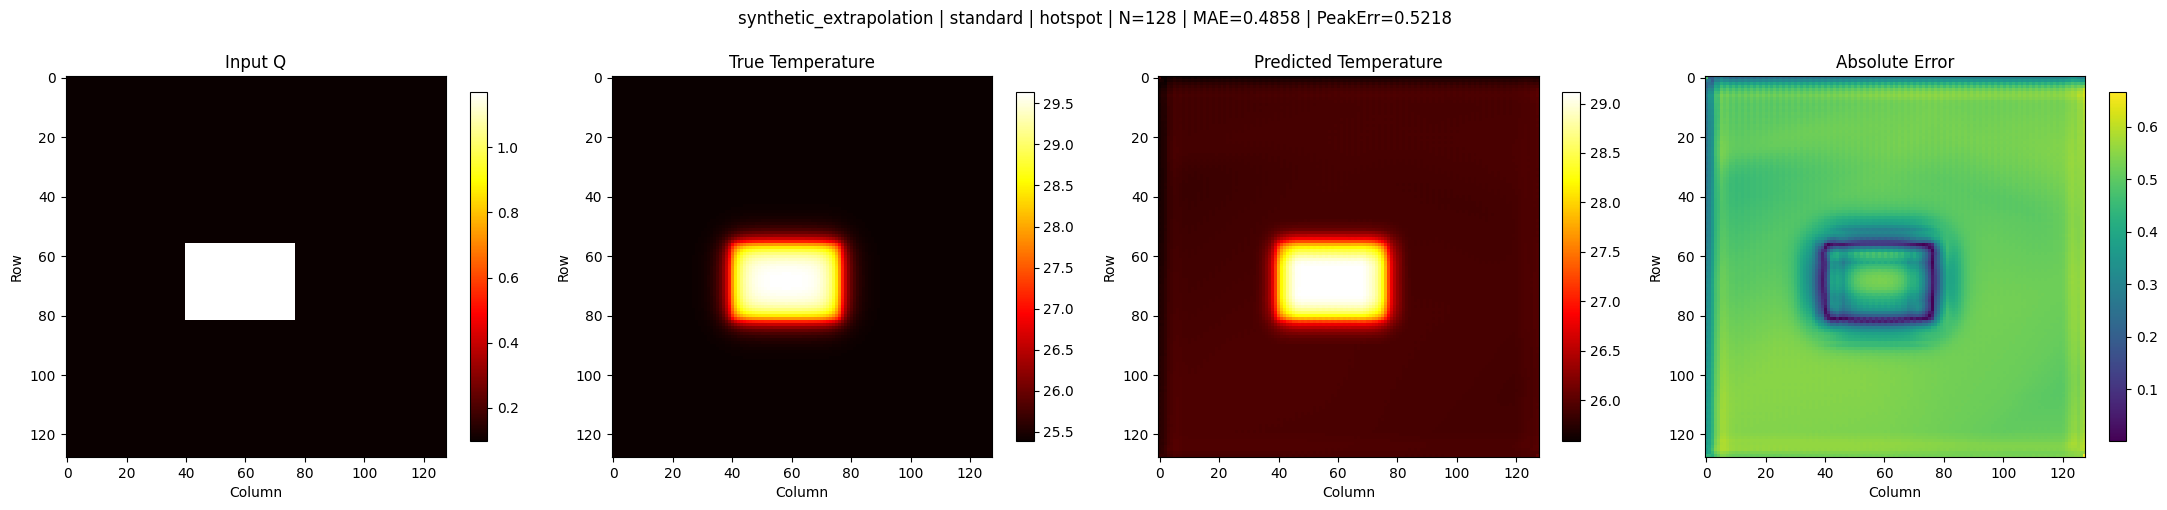

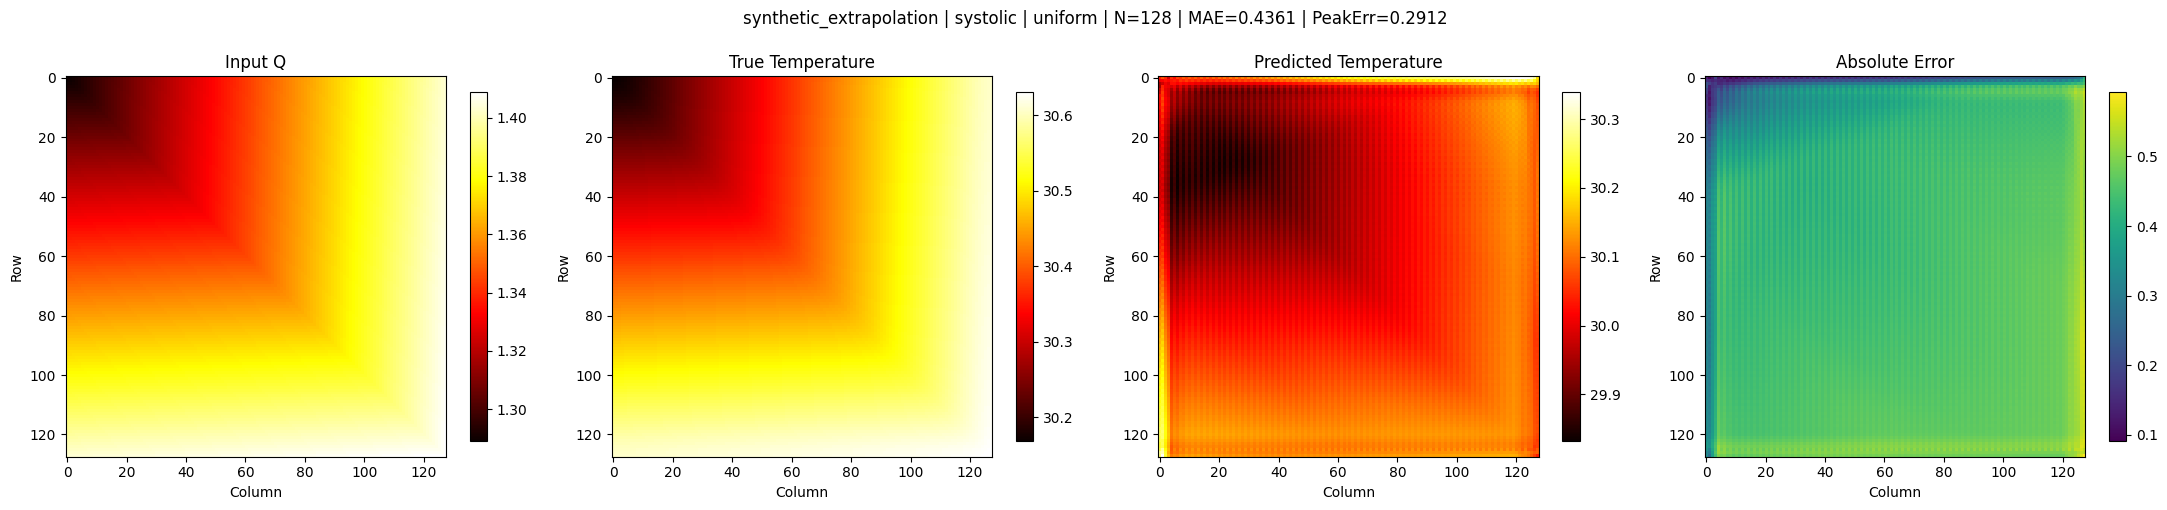

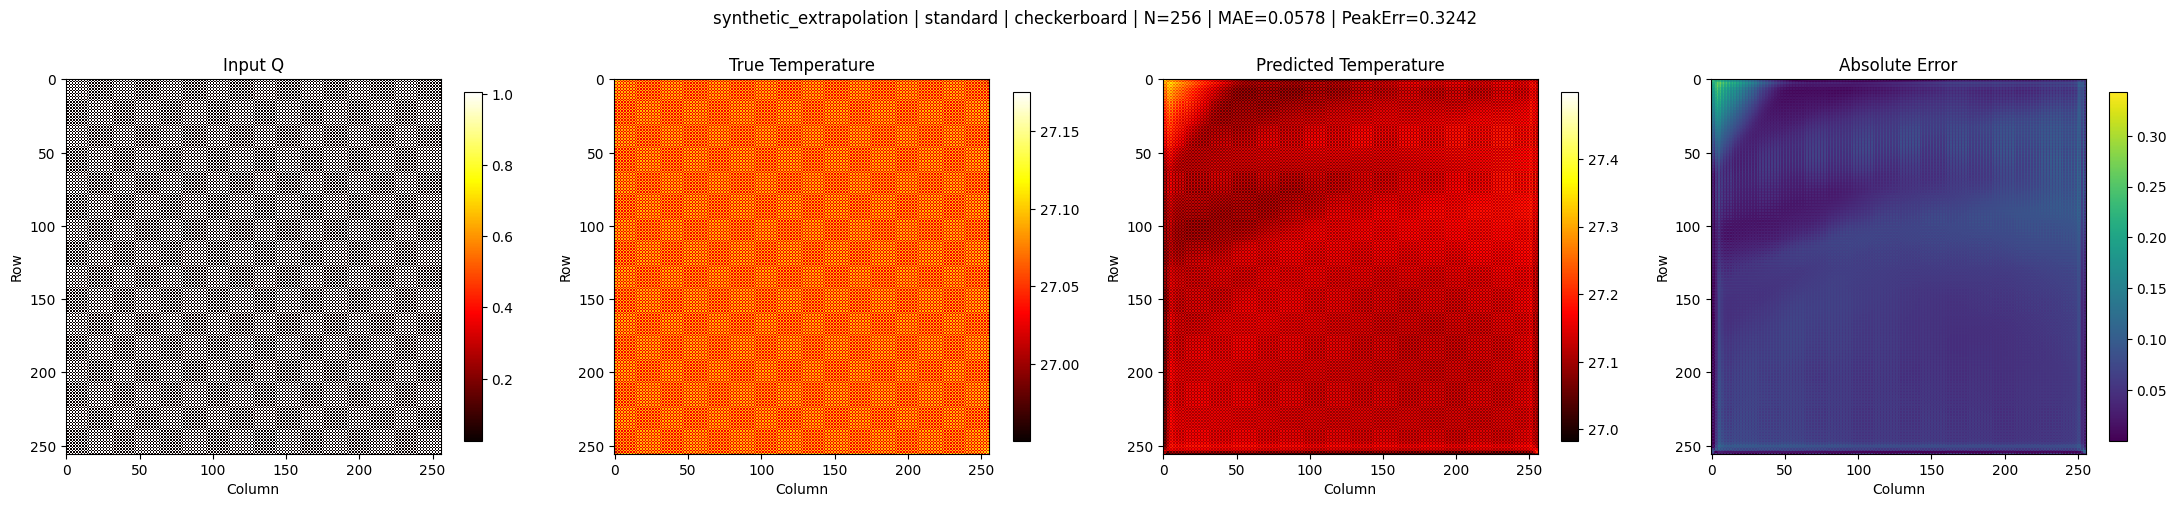

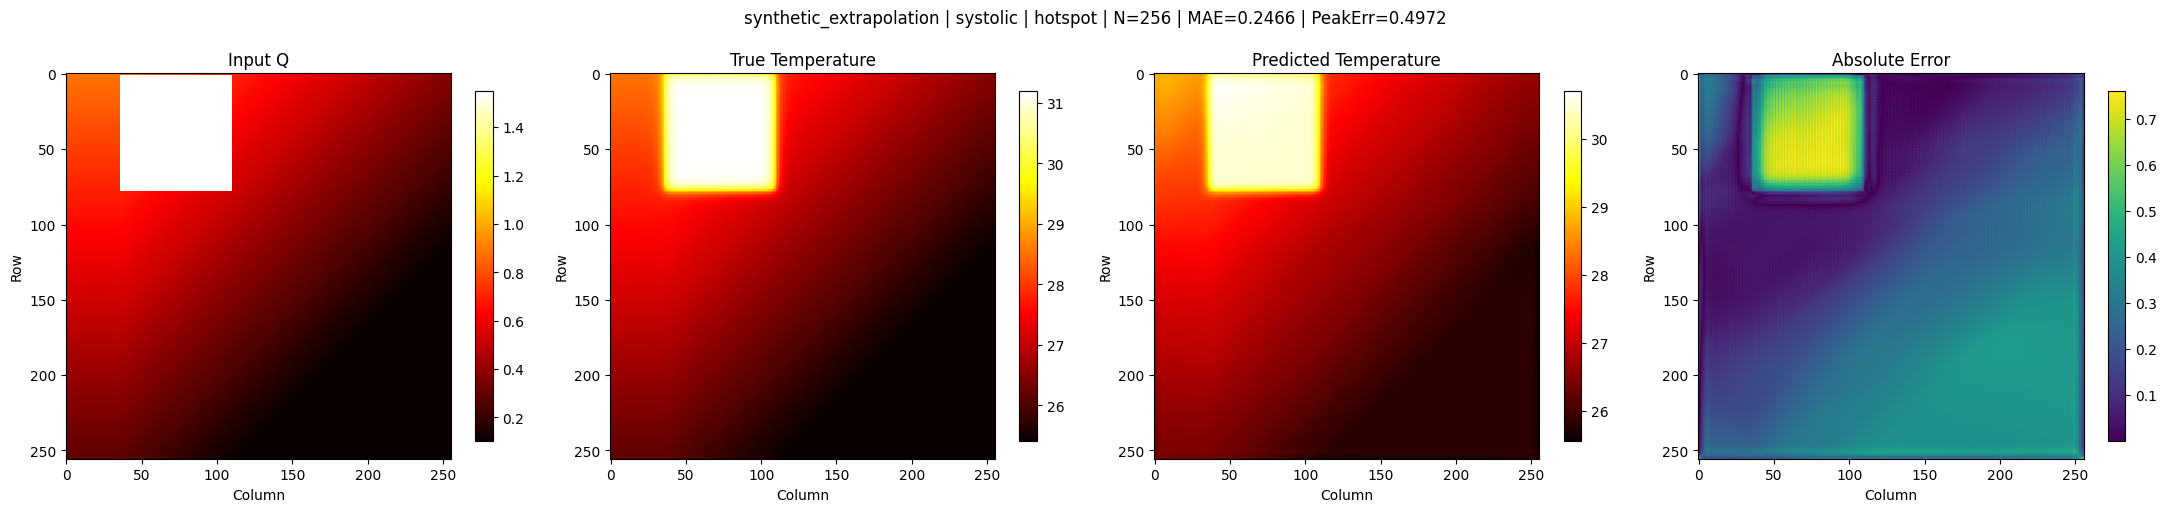

Worst 15 extrapolation samples by MAE


,sample_id,N,architecture,workload,mae_temp,peak_abs_error,grad_abs_error,phys_residual_mse
27,synthetic_extrapolation_systolic_checkerboard_...,128,systolic,checkerboard,0.961402,2.379021,0.026092,0.000740
35,synthetic_extrapolation_systolic_checkerboard_...,128,systolic,checkerboard,0.878378,2.233181,0.021686,0.000515
23,synthetic_extrapolation_systolic_checkerboard_...,128,systolic,checkerboard,0.871497,2.220707,0.021568,0.000497
15,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.556641,0.163427,0.007614,0.000143
9,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.536897,0.106915,0.007937,0.000136
7,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.535711,0.103594,0.007815,0.000134
16,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.533437,0.288916,0.008405,0.000135
3,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.485783,0.521780,0.008799,0.000117
36,synthetic_extrapolation_systolic_uniform_128_0...,128,systolic,uniform,0.478731,0.291088,0.006478,0.000108
10,synthetic_extrapolation_standard_multihotspot_...,128,standard,multihotspot,0.473742,0.341158,0.009938,0.000117


In [11]:
# --------------------------------------------------
# Cell 11: Extrapolation evaluation on 128x128 / 256x256
#
# Uses:
#   - X_extrap_raw, Y_extrap_raw, MASK_extrap, meta_extrap_df  (from Cell 5)
#   - X_mean, X_std, Y_mean, Y_std                             (from Cell 6)
#   - trained model                                            (from Cell 9)
#   - helper functions from Cell 10 if already defined:
#       denorm_q_from_xb, denorm_dt_from_pred,
#       compute_sample_metrics, print_split_summary,
#       grouped_summary, find_sample_in_results
# --------------------------------------------------
import os
import torch
from torch.utils.data import DataLoader

if X_extrap_raw is None or len(meta_extrap_df) == 0:
    print("No extrapolation pool found. Rebuild Cell 4/5 with synthetic_extrapolation cases first.")
else:
    # --------------------------------------------------
    # Normalize extrapolation pool using TRAIN stats only
    # --------------------------------------------------
    X_extrap = X_extrap_raw.copy()
    Y_extrap = Y_extrap_raw.copy()

    X_extrap[:, 0:1, :, :] = np.where(
        MASK_extrap > 0.5,
        (X_extrap_raw[:, 0:1, :, :] - X_mean) / X_std,
        0.0
    ).astype(np.float32)

    Y_extrap = np.where(
        MASK_extrap > 0.5,
        (Y_extrap_raw - Y_mean) / Y_std,
        0.0
    ).astype(np.float32)

    print("Extrap normalized tensor shapes:")
    print("X_extrap     :", X_extrap.shape)
    print("Y_extrap     :", Y_extrap.shape)
    print("MASK_extrap  :", MASK_extrap.shape)

    # --------------------------------------------------
    # Dataset / loader
    # --------------------------------------------------
    extrap_idx = list(range(len(meta_extrap_df)))
    extrap_set = MultiScaleThermalDataset(X_extrap, Y_extrap, MASK_extrap, meta_extrap_df, extrap_idx)
    extrap_loader = DataLoader(extrap_set, batch_size=1, shuffle=False)

    print("\nExtrap loader size:", len(extrap_loader))

    # --------------------------------------------------
    # Evaluate extrapolation set
    # --------------------------------------------------
    def evaluate_extrap_dataset(model, loader, dataset, meta_local_df, split_name):
        model.eval()
        rows = []
        offset = 0

        with torch.no_grad():
            for xb, yb, mb in loader:
                xb = xb.to(device)
                yb = yb.to(device)
                mb = mb.to(device)

                pred_norm = model(xb)

                bs = xb.size(0)
                batch_indices = dataset.indices[offset:offset + bs]
                offset += bs

                pred_dT_phys = denorm_dt_from_pred(pred_norm)
                true_dT_phys = denorm_dt_from_pred(yb)
                Q_phys = denorm_q_from_xb(xb)

                residual = physics_residual(pred_dT_phys, Q_phys, mb)
                residual_sq = residual ** 2

                for b in range(bs):
                    local_idx = batch_indices[b]
                    meta = meta_local_df.iloc[local_idx]

                    N = int(meta["N"])

                    pred_dT_np = pred_dT_phys[b, 0, :N, :N].detach().cpu().numpy()
                    true_dT_np = true_dT_phys[b, 0, :N, :N].detach().cpu().numpy()

                    pred_temp = pred_dT_np + T_AMB
                    true_temp = true_dT_np + T_AMB

                    sample_metrics = compute_sample_metrics(pred_temp, true_temp)

                    sample_residual_mse = masked_mean(
                        residual_sq[b:b+1],
                        mb[b:b+1]
                    ).item()

                    rows.append({
                        "split": split_name,
                        "sample_id": meta.get("sample_id", f"extrap_{local_idx:05d}"),
                        "local_idx": int(local_idx),
                        **sample_metrics,
                        "phys_residual_mse": float(sample_residual_mse),
                        "architecture": meta["architecture"],
                        "workload": meta["workload"],
                        "N": int(meta["N"]),
                        "source": meta["source"],
                    })

        return pd.DataFrame(rows)

    extrap_eval_df = evaluate_extrap_dataset(
        model=model,
        loader=extrap_loader,
        dataset=extrap_set,
        meta_local_df=meta_extrap_df.reset_index(drop=True),
        split_name="synthetic_extrapolation"
    )

    # --------------------------------------------------
    # Save CSV
    # --------------------------------------------------
    extrap_eval_path = os.path.join(RESULTS_DIR, "synthetic_extrapolation_results.csv")
    extrap_eval_df.to_csv(extrap_eval_path, index=False)

    print("\nSaved extrapolation CSV:")
    print(" ", extrap_eval_path)
    print()

    # --------------------------------------------------
    # Summary
    # --------------------------------------------------
    print_split_summary(extrap_eval_df, "Synthetic extrapolation summary (128x128, 256x256)")

    display(extrap_eval_df.head())

    print("Synthetic extrapolation grouped by N / architecture / workload")
    display(grouped_summary(extrap_eval_df, ["N", "architecture", "workload"]))

    print("Synthetic extrapolation grouped by architecture / workload")
    display(grouped_summary(extrap_eval_df, ["architecture", "workload"]))

    print("Synthetic extrapolation grouped by N")
    display(grouped_summary(extrap_eval_df, ["N"]))

    grouped_summary(extrap_eval_df, ["N", "architecture", "workload"]).to_csv(
        os.path.join(RESULTS_DIR, "synthetic_extrapolation_grouped_by_N_arch_workload.csv")
    )

    # --------------------------------------------------
    # Plot helper for extrapolation pool
    # --------------------------------------------------
    def plot_extrap_case_from_results(row_obj):
        if row_obj is None:
            print("Requested extrapolation case not found.")
            return

        local_idx = int(row_obj["local_idx"])
        N = int(row_obj["N"])

        x_norm = torch.tensor(X_extrap[local_idx:local_idx+1], dtype=torch.float32).to(device)
        y_norm = torch.tensor(Y_extrap[local_idx:local_idx+1], dtype=torch.float32).to(device)

        model.eval()
        with torch.no_grad():
            pred_norm = model(x_norm)

            pred_dT = denorm_dt_from_pred(pred_norm)[0, 0, :N, :N].cpu().numpy()
            true_dT = denorm_dt_from_pred(y_norm)[0, 0, :N, :N].cpu().numpy()
            q_phys = denorm_q_from_xb(x_norm)[0, 0, :N, :N].cpu().numpy()

            pred_temp = pred_dT + T_AMB
            true_temp = true_dT + T_AMB
            abs_err = np.abs(pred_temp - true_temp)

        fig, axes = plt.subplots(1, 4, figsize=(22, 5))

        im0 = axes[0].imshow(q_phys, cmap="hot", interpolation="nearest")
        axes[0].set_title("Input Q")
        axes[0].set_xlabel("Column")
        axes[0].set_ylabel("Row")
        plt.colorbar(im0, ax=axes[0], shrink=0.8)

        im1 = axes[1].imshow(true_temp, cmap="hot", interpolation="nearest")
        axes[1].set_title("True Temperature")
        axes[1].set_xlabel("Column")
        axes[1].set_ylabel("Row")
        plt.colorbar(im1, ax=axes[1], shrink=0.8)

        im2 = axes[2].imshow(pred_temp, cmap="hot", interpolation="nearest")
        axes[2].set_title("Predicted Temperature")
        axes[2].set_xlabel("Column")
        axes[2].set_ylabel("Row")
        plt.colorbar(im2, ax=axes[2], shrink=0.8)

        im3 = axes[3].imshow(abs_err, cmap="viridis", interpolation="nearest")
        axes[3].set_title("Absolute Error")
        axes[3].set_xlabel("Column")
        axes[3].set_ylabel("Row")
        plt.colorbar(im3, ax=axes[3], shrink=0.8)

        fig.suptitle(
            f"{row_obj['split']} | {row_obj['architecture']} | {row_obj['workload']} | "
            f"N={N} | MAE={row_obj['mae_temp']:.4f} | PeakErr={row_obj['peak_abs_error']:.4f}"
        )
        plt.tight_layout()
        plt.show()

    # --------------------------------------------------
    # Representative extrapolation plots
    # --------------------------------------------------
    extrap_cases_to_plot = [
        find_sample_in_results(extrap_eval_df, architecture="standard", workload="hotspot", N=128, source="synthetic_extrapolation"),
        find_sample_in_results(extrap_eval_df, architecture="systolic", workload="uniform", N=128, source="synthetic_extrapolation"),
        find_sample_in_results(extrap_eval_df, architecture="standard", workload="checkerboard", N=256, source="synthetic_extrapolation"),
        find_sample_in_results(extrap_eval_df, architecture="systolic", workload="hotspot", N=256, source="synthetic_extrapolation"),
    ]

    for row in extrap_cases_to_plot:
        if row is not None:
            plot_extrap_case_from_results(row)

    # --------------------------------------------------
    # Worst-case diagnostics
    # --------------------------------------------------
    print("Worst 15 extrapolation samples by MAE")
    display(
        extrap_eval_df.sort_values("mae_temp", ascending=False)[
            ["sample_id", "N", "architecture", "workload", "mae_temp", "peak_abs_error", "grad_abs_error", "phys_residual_mse"]
        ].head(15)
    )

Saved refinement CSV:
  /home/aditya_chaudhry/thermal_aware_mac/results/multiscale_cnn_pinn/synthetic_extrapolation_refined_50steps.csv

Hybrid refinement summary (50 solver steps)
-------------------------------
              samples: 60
           MAE before: 0.321225
            MAE after: 0.115081
      MAE improvement: 0.206144

          RMSE before: 0.357757
           RMSE after: 0.127813
     RMSE improvement: 0.229944

       PeakErr before: 0.424621
        PeakErr after: 0.159401
  PeakErr improvement: 0.265219

        AvgErr before: 0.276214
         AvgErr after: 0.100582
   AvgErr improvement: 0.175631

       GradErr before: 0.009650
        GradErr after: 0.001742
  GradErr improvement: 0.007907

     Phys resid after: 9.211539e-06



,sample_id,local_idx,architecture,workload,N,source,mae_before,rmse_before,peak_err_before,avg_err_before,...,rmse_after,peak_err_after,avg_err_after,grad_err_after,mae_improvement,rmse_improvement,peak_err_improvement,avg_err_improvement,grad_err_improvement,phys_residual_mse_after
0,synthetic_extrapolation_standard_stripes_128_0...,0,standard,stripes,128,synthetic_extrapolation,0.306110,0.342754,0.128542,0.095816,...,0.106548,0.081884,0.035078,0.006381,0.213797,0.236206,0.046658,0.060738,0.017226,5.918383e-06
1,synthetic_extrapolation_standard_uniform_128_0...,1,standard,uniform,128,synthetic_extrapolation,0.380554,0.382528,0.141422,0.380560,...,0.138809,0.076984,0.138269,0.000404,0.242290,0.243719,0.064438,0.242290,0.004444,7.766131e-06
2,synthetic_extrapolation_standard_stripes_128_0...,2,standard,stripes,128,synthetic_extrapolation,0.237970,0.305251,0.513098,0.232620,...,0.102835,0.155840,0.084902,0.004066,0.152335,0.202416,0.357258,0.147718,0.012754,4.755822e-06
3,synthetic_extrapolation_standard_hotspot_128_0...,3,standard,hotspot,128,synthetic_extrapolation,0.485783,0.493428,0.521780,0.447575,...,0.177101,0.176178,0.163044,0.001942,0.312418,0.316326,0.345602,0.284531,0.006857,1.282342e-05
4,synthetic_extrapolation_standard_checkerboard_...,4,standard,checkerboard,128,synthetic_extrapolation,0.092040,0.100048,0.616135,0.091591,...,0.036064,0.142157,0.033588,0.000366,0.058450,0.063984,0.473978,0.058002,0.012197,5.190224e-07


Refinement grouped by N


,mae_before,mae_after,mae_improvement,rmse_before,rmse_after,rmse_improvement,peak_err_before,peak_err_after,peak_err_improvement,grad_err_before,grad_err_after,grad_err_improvement,phys_residual_mse_after
N,,,,,,,,,,,,,
128,0.350526,0.125483,0.225043,0.390251,0.139194,0.251058,0.517731,0.191980,0.325751,0.010825,0.002081,0.008743,0.000011
256,0.262623,0.094277,0.168346,0.292770,0.105053,0.187717,0.238401,0.094245,0.144155,0.007300,0.001065,0.006235,0.000005


Refinement grouped by architecture / workload


mae_before  mae_after  mae_improvement  \
architecture workload                                               
standard     checkerboard    0.084528   0.030836         0.053692   
             hotspot         0.494921   0.178321         0.316600   
             multihotspot    0.460078   0.165145         0.294933   
             quadrant        0.441389   0.159013         0.282376   
             stripes         0.268772   0.086712         0.182060   
             uniform         0.223728   0.081030         0.142698   
systolic     banded          0.124228   0.043865         0.080364   
             checkerboard    0.903759   0.328923         0.574836   
             hotspot         0.204407   0.074001         0.130406   
             uniform         0.363860   0.132253         0.231607   
             wavefront       0.243474   0.088440         0.155035   

                           rmse_before  rmse_after  rmse_improvement  \
architecture workload                                                  
standard     checkerboard     0.091922    0.033120          0.058802   
             hotspot          0.504515    0.182101          0.322415   
             multihotspot     0.471610    0.169920          0.301690   
             quadrant         0.473226    0.170928          0.302298   
             stripes          0.321174    0.104419          0.216755   
             uniform          0.229840    0.083089          0.146751   
systolic     banded           0.163535    0.057280          0.106256   
             checkerboard     1.089678    0.394553          0.695125   
             hotspot          0.275588    0.098398          0.177190   
             uniform          0.368155    0.133537          0.234618   
             wavefront        0.253445    0.091827          0.161618   

                           peak_err_before  peak_err_after  \
architecture workload                                        
standard     checkerboard         0.567831        0.134631   
             hotspot              0.302706        0.106054   
             multihotspot         0.341538        0.112229   
             quadrant             0.176951        0.058217   
             stripes              0.175330        0.064869   
             uniform              0.209757        0.073329   
systolic     banded               0.100269        0.054357   
             checkerboard         2.277636        0.879857   
             hotspot              0.712690        0.267108   
             uniform              0.245984        0.135808   
             wavefront            0.114795        0.068040   

                           peak_err_improvement  grad_err_before  \
architecture workload                                              
standard     checkerboard              0.433199         0.010151   
             hotspot                   0.196652         0.007783   
             multihotspot              0.229309         0.008122   
             quadrant                  0.118734         0.007688   
             stripes                   0.110461         0.019351   
             uniform                   0.136428         0.004963   
systolic     banded                    0.045911         0.008394   
             checkerboard              1.397779         0.023115   
             hotspot                   0.445582         0.007677   
             uniform                   0.110176         0.008116   
             wavefront                 0.046755         0.005896   

                           grad_err_after  grad_err_improvement  \
architecture workload                                             
standard     checkerboard        0.000327              0.009824   
             hotspot             0.001475              0.006308   
             multihotspot        0.001612              0.006511   
             quadrant            0.001160              0.006528   
             stripes             0.004902              0.014449   
             uniform           

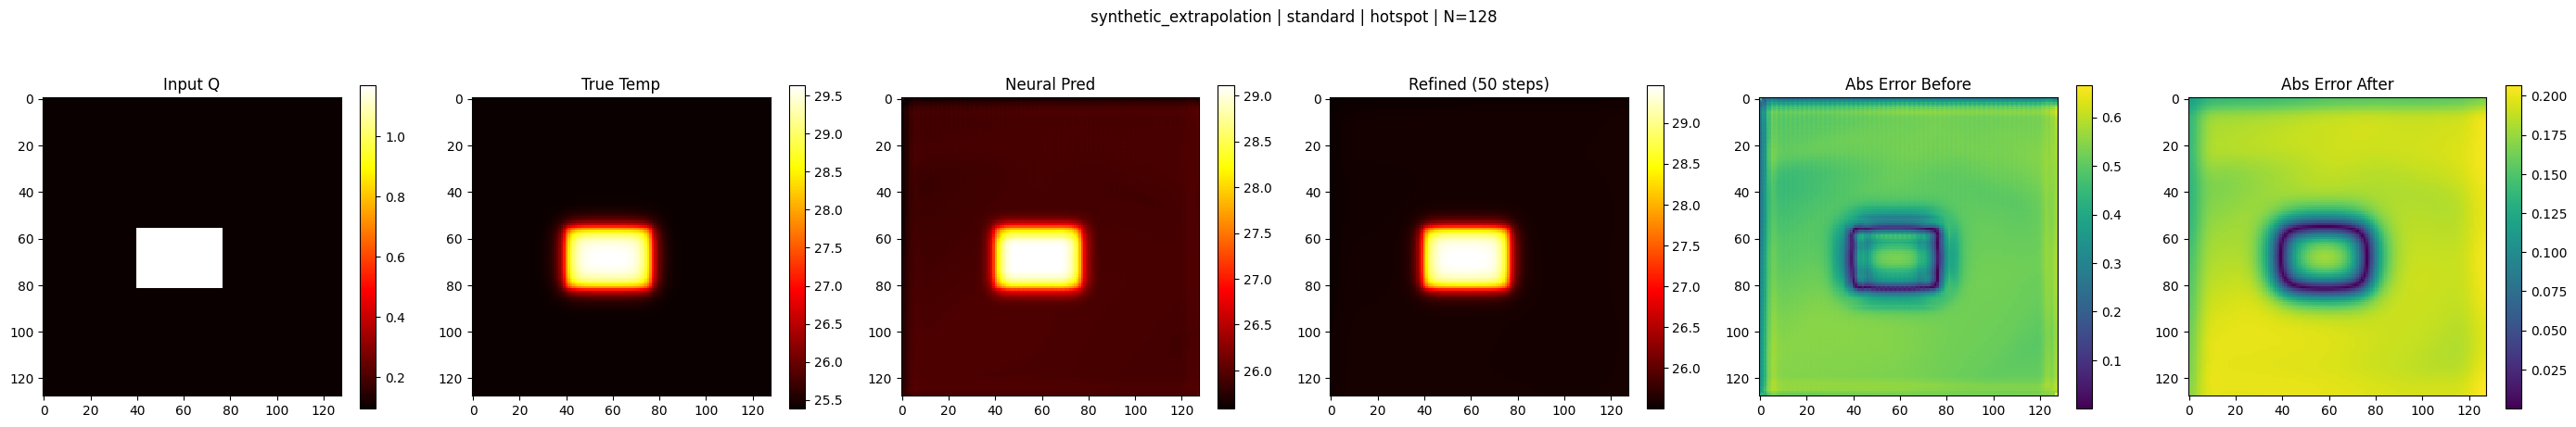

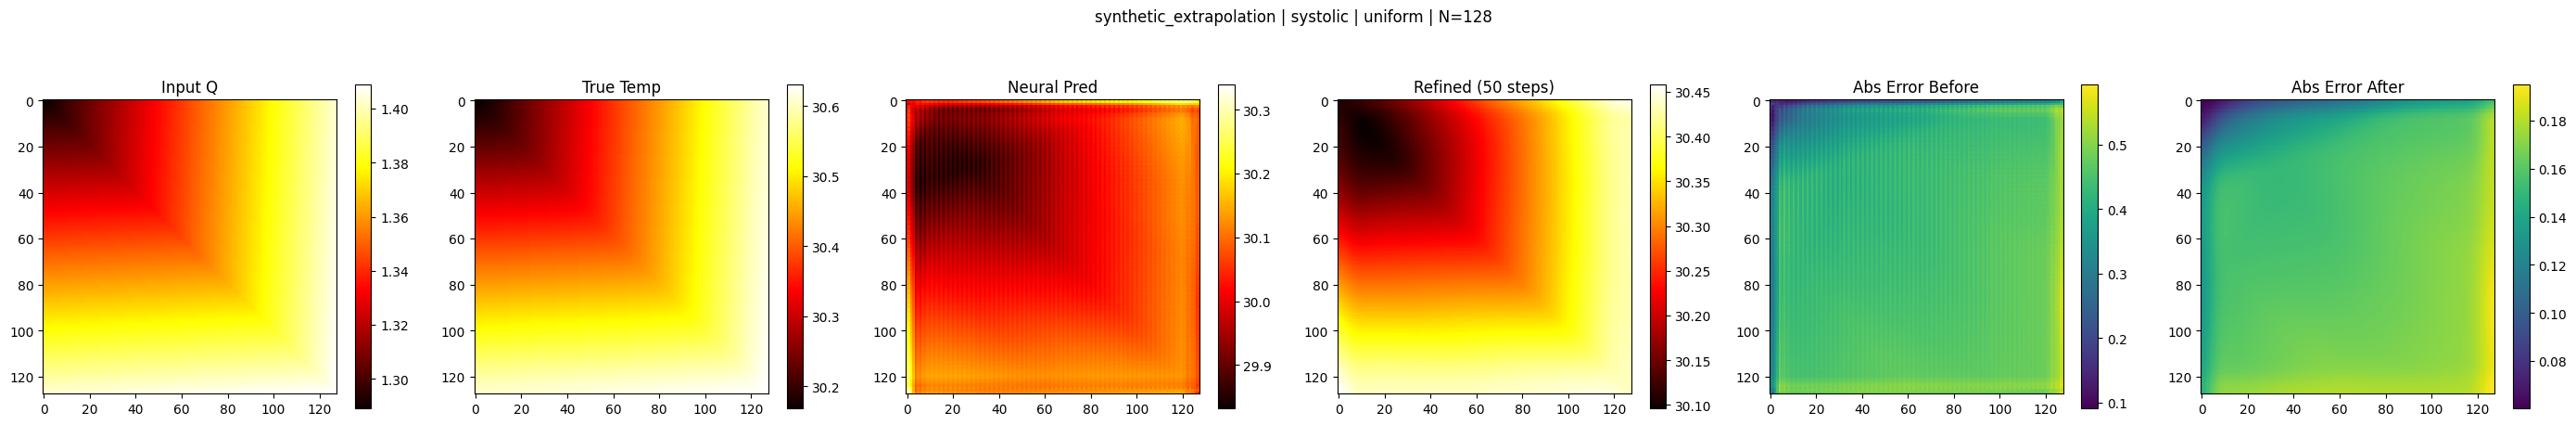

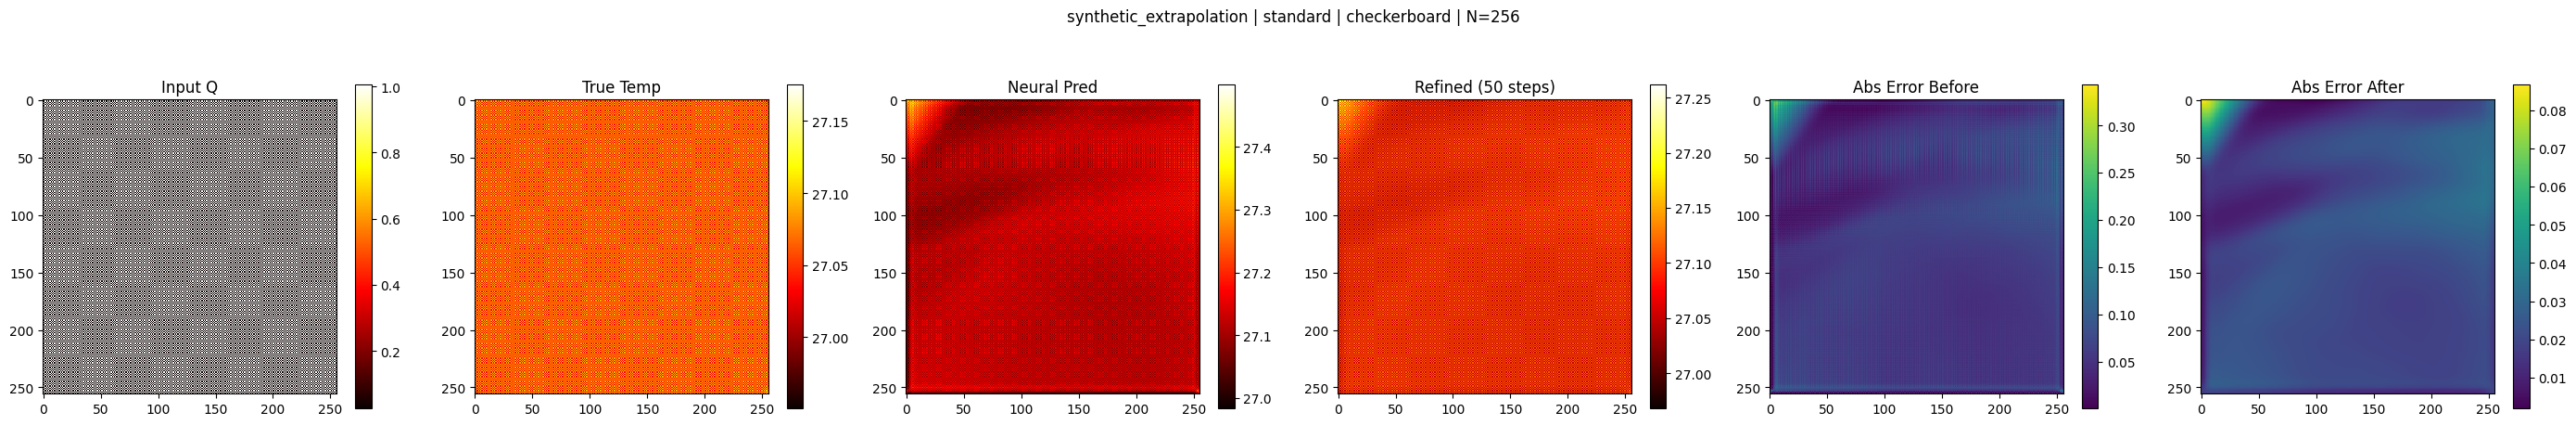

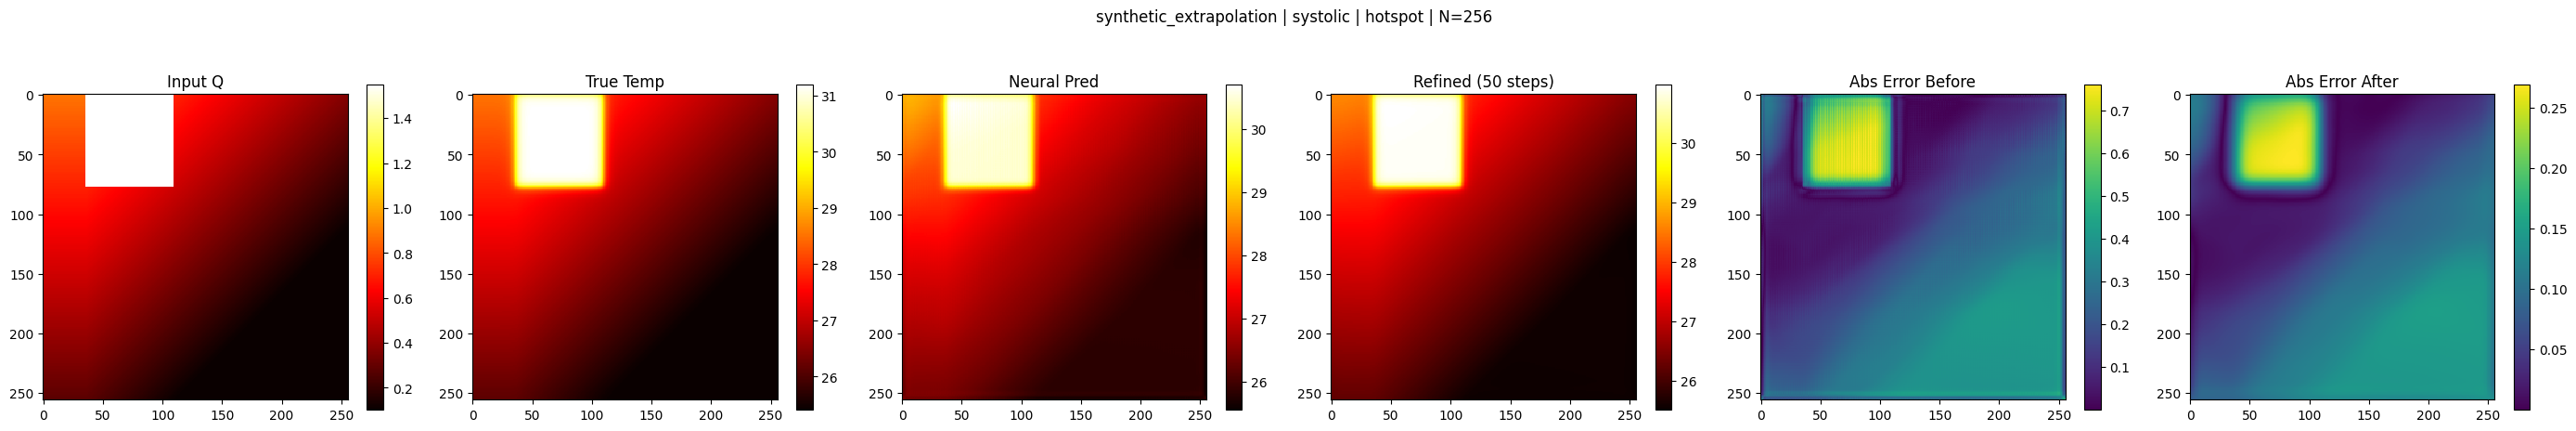

Top 15 samples by MAE improvement


,sample_id,N,architecture,workload,mae_before,mae_after,mae_improvement
27,synthetic_extrapolation_systolic_checkerboard_...,128,systolic,checkerboard,0.961402,0.349944,0.611459
35,synthetic_extrapolation_systolic_checkerboard_...,128,systolic,checkerboard,0.878378,0.319666,0.558711
23,synthetic_extrapolation_systolic_checkerboard_...,128,systolic,checkerboard,0.871497,0.317159,0.554338
15,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.556641,0.201447,0.355194
9,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.536897,0.194629,0.342268
16,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.533437,0.191571,0.341865
7,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.535711,0.194097,0.341614
3,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.485783,0.173365,0.312418
10,synthetic_extrapolation_standard_multihotspot_...,128,standard,multihotspot,0.473742,0.168420,0.305322
36,synthetic_extrapolation_systolic_uniform_128_0...,128,systolic,uniform,0.478731,0.174117,0.304614


Worst 15 samples after refinement


,sample_id,N,architecture,workload,mae_before,mae_after,mae_improvement
27,synthetic_extrapolation_systolic_checkerboard_...,128,systolic,checkerboard,0.961402,0.349944,0.611459
35,synthetic_extrapolation_systolic_checkerboard_...,128,systolic,checkerboard,0.878378,0.319666,0.558711
23,synthetic_extrapolation_systolic_checkerboard_...,128,systolic,checkerboard,0.871497,0.317159,0.554338
15,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.556641,0.201447,0.355194
9,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.536897,0.194629,0.342268
7,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.535711,0.194097,0.341614
16,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.533437,0.191571,0.341865
36,synthetic_extrapolation_systolic_uniform_128_0...,128,systolic,uniform,0.478731,0.174117,0.304614
3,synthetic_extrapolation_standard_hotspot_128_0...,128,standard,hotspot,0.485783,0.173365,0.312418
10,synthetic_extrapolation_standard_multihotspot_...,128,standard,multihotspot,0.473742,0.168420,0.305322


In [12]:
# --------------------------------------------------
# Cell 12: Hybrid refinement on extrapolation set
#
# Idea:
# 1. Use the trained CNN-PINN to predict temperature
# 2. Use that prediction as the INITIAL CONDITION
# 3. Run a few steady-state solver iterations to refine it
#
# Goal:
# - improve 128x128 / 256x256 extrapolation
# - test whether the network is a good warm start
# --------------------------------------------------
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

REFINE_STEPS = 50   # try 20, 50, 100 later if needed

if X_extrap_raw is None or len(meta_extrap_df) == 0:
    print("No extrapolation pool found. Run Cell 5/11 first.")
else:
    # --------------------------------------------------
    # Vectorized steady-state refinement
    # Same update rule as the simulator, but initialized from model prediction
    # --------------------------------------------------
    def refine_temperature_from_init(
        Q,
        T_init,
        n_steps=REFINE_STEPS,
        alpha=ALPHA,
        beta=BETA,
        gamma=GAMMA,
        T_amb=T_AMB
    ):
        """
        Q      : [N, N] physical heat source
        T_init : [N, N] initial physical temperature
        returns refined T after n_steps
        """
        T = T_init.astype(np.float32).copy()

        for _ in range(n_steps):
            nbr = np.zeros_like(T, dtype=np.float32)
            cnt = np.zeros_like(T, dtype=np.float32)

            nbr[1:, :]  += T[:-1, :]
            cnt[1:, :]  += 1.0

            nbr[:-1, :] += T[1:, :]
            cnt[:-1, :] += 1.0

            nbr[:, 1:]  += T[:, :-1]
            cnt[:, 1:]  += 1.0

            nbr[:, :-1] += T[:, 1:]
            cnt[:, :-1] += 1.0

            lap = nbr - cnt * T

            T = (
                T
                + alpha * lap
                + beta * Q
                - gamma * (T - T_amb)
            ).astype(np.float32)

        return T


    # --------------------------------------------------
    # Evaluate refined extrapolation set
    # --------------------------------------------------
    def evaluate_extrap_refined(model, X_extrap, Y_extrap, MASK_extrap, meta_extrap_df):
        model.eval()

        rows = []

        for local_idx in range(len(meta_extrap_df)):
            meta = meta_extrap_df.iloc[local_idx]
            N = int(meta["N"])

            x_norm = torch.tensor(X_extrap[local_idx:local_idx+1], dtype=torch.float32).to(device)
            y_norm = torch.tensor(Y_extrap[local_idx:local_idx+1], dtype=torch.float32).to(device)
            m = torch.tensor(MASK_extrap[local_idx:local_idx+1], dtype=torch.float32).to(device)

            with torch.no_grad():
                pred_norm = model(x_norm)

                q_phys = denorm_q_from_xb(x_norm)[0, 0, :N, :N].cpu().numpy()
                true_dT = denorm_dt_from_pred(y_norm)[0, 0, :N, :N].cpu().numpy()
                pred_dT = denorm_dt_from_pred(pred_norm)[0, 0, :N, :N].cpu().numpy()

            true_temp = true_dT + T_AMB
            pred_temp = pred_dT + T_AMB

            # --- refine from neural warm start ---
            refined_temp = refine_temperature_from_init(
                Q=q_phys,
                T_init=pred_temp,
                n_steps=REFINE_STEPS
            )

            # --- metrics before refinement ---
            before_metrics = compute_sample_metrics(pred_temp, true_temp)

            # --- metrics after refinement ---
            after_metrics = compute_sample_metrics(refined_temp, true_temp)

            # --- residual after refinement ---
            refined_dT_t = torch.tensor(
                (refined_temp - T_AMB)[None, None, :, :],
                dtype=torch.float32
            ).to(device)

            q_t = torch.tensor(
                q_phys[None, None, :, :],
                dtype=torch.float32
            ).to(device)

            m_t = torch.tensor(
                np.ones((1, 1, N, N), dtype=np.float32),
                dtype=torch.float32
            ).to(device)

            with torch.no_grad():
                residual_refined = physics_residual(refined_dT_t, q_t, m_t)
                refined_phys_residual_mse = torch.mean(residual_refined ** 2).item()

            rows.append({
                "sample_id": meta.get("sample_id", f"extrap_{local_idx:05d}"),
                "local_idx": int(local_idx),
                "architecture": meta["architecture"],
                "workload": meta["workload"],
                "N": int(meta["N"]),
                "source": meta["source"],

                "mae_before": before_metrics["mae_temp"],
                "rmse_before": before_metrics["rmse_temp"],
                "peak_err_before": before_metrics["peak_abs_error"],
                "avg_err_before": before_metrics["avg_abs_error"],
                "grad_err_before": before_metrics["grad_abs_error"],

                "mae_after": after_metrics["mae_temp"],
                "rmse_after": after_metrics["rmse_temp"],
                "peak_err_after": after_metrics["peak_abs_error"],
                "avg_err_after": after_metrics["avg_abs_error"],
                "grad_err_after": after_metrics["grad_abs_error"],

                "mae_improvement": before_metrics["mae_temp"] - after_metrics["mae_temp"],
                "rmse_improvement": before_metrics["rmse_temp"] - after_metrics["rmse_temp"],
                "peak_err_improvement": before_metrics["peak_abs_error"] - after_metrics["peak_abs_error"],
                "avg_err_improvement": before_metrics["avg_abs_error"] - after_metrics["avg_abs_error"],
                "grad_err_improvement": before_metrics["grad_abs_error"] - after_metrics["grad_abs_error"],

                "phys_residual_mse_after": refined_phys_residual_mse,
            })

        return pd.DataFrame(rows)


    refinement_df = evaluate_extrap_refined(
        model=model,
        X_extrap=X_extrap,
        Y_extrap=Y_extrap,
        MASK_extrap=MASK_extrap,
        meta_extrap_df=meta_extrap_df.reset_index(drop=True)
    )

    # --------------------------------------------------
    # Save results
    # --------------------------------------------------
    refine_csv_path = os.path.join(
        RESULTS_DIR,
        f"synthetic_extrapolation_refined_{REFINE_STEPS}steps.csv"
    )
    refinement_df.to_csv(refine_csv_path, index=False)

    print("Saved refinement CSV:")
    print(" ", refine_csv_path)
    print()

    # --------------------------------------------------
    # Summary before vs after
    # --------------------------------------------------
    print(f"Hybrid refinement summary ({REFINE_STEPS} solver steps)")
    print("-" * (29 + len(str(REFINE_STEPS))))

    print(f"{'samples:':>22} {len(refinement_df)}")
    print(f"{'MAE before:':>22} {refinement_df['mae_before'].mean():.6f}")
    print(f"{'MAE after:':>22} {refinement_df['mae_after'].mean():.6f}")
    print(f"{'MAE improvement:':>22} {refinement_df['mae_improvement'].mean():.6f}")
    print()

    print(f"{'RMSE before:':>22} {refinement_df['rmse_before'].mean():.6f}")
    print(f"{'RMSE after:':>22} {refinement_df['rmse_after'].mean():.6f}")
    print(f"{'RMSE improvement:':>22} {refinement_df['rmse_improvement'].mean():.6f}")
    print()

    print(f"{'PeakErr before:':>22} {refinement_df['peak_err_before'].mean():.6f}")
    print(f"{'PeakErr after:':>22} {refinement_df['peak_err_after'].mean():.6f}")
    print(f"{'PeakErr improvement:':>22} {refinement_df['peak_err_improvement'].mean():.6f}")
    print()

    print(f"{'AvgErr before:':>22} {refinement_df['avg_err_before'].mean():.6f}")
    print(f"{'AvgErr after:':>22} {refinement_df['avg_err_after'].mean():.6f}")
    print(f"{'AvgErr improvement:':>22} {refinement_df['avg_err_improvement'].mean():.6f}")
    print()

    print(f"{'GradErr before:':>22} {refinement_df['grad_err_before'].mean():.6f}")
    print(f"{'GradErr after:':>22} {refinement_df['grad_err_after'].mean():.6f}")
    print(f"{'GradErr improvement:':>22} {refinement_df['grad_err_improvement'].mean():.6f}")
    print()

    print(f"{'Phys resid after:':>22} {refinement_df['phys_residual_mse_after'].mean():.6e}")
    print()

    display(refinement_df.head())

    # --------------------------------------------------
    # Grouped summaries
    # --------------------------------------------------
    print("Refinement grouped by N")
    display(
        refinement_df.groupby("N")[
            [
                "mae_before", "mae_after", "mae_improvement",
                "rmse_before", "rmse_after", "rmse_improvement",
                "peak_err_before", "peak_err_after", "peak_err_improvement",
                "grad_err_before", "grad_err_after", "grad_err_improvement",
                "phys_residual_mse_after"
            ]
        ].mean()
    )

    print("Refinement grouped by architecture / workload")
    display(
        refinement_df.groupby(["architecture", "workload"])[
            [
                "mae_before", "mae_after", "mae_improvement",
                "rmse_before", "rmse_after", "rmse_improvement",
                "peak_err_before", "peak_err_after", "peak_err_improvement",
                "grad_err_before", "grad_err_after", "grad_err_improvement",
                "phys_residual_mse_after"
            ]
        ].mean()
    )

    # --------------------------------------------------
    # Plot helper
    # --------------------------------------------------
    def plot_refined_extrap_case(local_idx):
        meta = meta_extrap_df.iloc[local_idx]
        N = int(meta["N"])

        x_norm = torch.tensor(X_extrap[local_idx:local_idx+1], dtype=torch.float32).to(device)
        y_norm = torch.tensor(Y_extrap[local_idx:local_idx+1], dtype=torch.float32).to(device)

        with torch.no_grad():
            pred_norm = model(x_norm)

            q_phys = denorm_q_from_xb(x_norm)[0, 0, :N, :N].cpu().numpy()
            true_dT = denorm_dt_from_pred(y_norm)[0, 0, :N, :N].cpu().numpy()
            pred_dT = denorm_dt_from_pred(pred_norm)[0, 0, :N, :N].cpu().numpy()

        true_temp = true_dT + T_AMB
        pred_temp = pred_dT + T_AMB
        refined_temp = refine_temperature_from_init(q_phys, pred_temp, n_steps=REFINE_STEPS)

        err_before = np.abs(pred_temp - true_temp)
        err_after = np.abs(refined_temp - true_temp)

        fig, axes = plt.subplots(1, 6, figsize=(28, 5))

        im0 = axes[0].imshow(q_phys, cmap="hot", interpolation="nearest")
        axes[0].set_title("Input Q")
        plt.colorbar(im0, ax=axes[0], shrink=0.8)

        im1 = axes[1].imshow(true_temp, cmap="hot", interpolation="nearest")
        axes[1].set_title("True Temp")
        plt.colorbar(im1, ax=axes[1], shrink=0.8)

        im2 = axes[2].imshow(pred_temp, cmap="hot", interpolation="nearest")
        axes[2].set_title("Neural Pred")
        plt.colorbar(im2, ax=axes[2], shrink=0.8)

        im3 = axes[3].imshow(refined_temp, cmap="hot", interpolation="nearest")
        axes[3].set_title(f"Refined ({REFINE_STEPS} steps)")
        plt.colorbar(im3, ax=axes[3], shrink=0.8)

        im4 = axes[4].imshow(err_before, cmap="viridis", interpolation="nearest")
        axes[4].set_title("Abs Error Before")
        plt.colorbar(im4, ax=axes[4], shrink=0.8)

        im5 = axes[5].imshow(err_after, cmap="viridis", interpolation="nearest")
        axes[5].set_title("Abs Error After")
        plt.colorbar(im5, ax=axes[5], shrink=0.8)

        fig.suptitle(
            f"{meta['source']} | {meta['architecture']} | {meta['workload']} | N={N}"
        )
        plt.tight_layout()
        plt.show()

    # --------------------------------------------------
    # Plot a few representative extrapolation cases
    # --------------------------------------------------
    # standard hotspot 128
    subset = meta_extrap_df[
        (meta_extrap_df["architecture"] == "standard") &
        (meta_extrap_df["workload"] == "hotspot") &
        (meta_extrap_df["N"] == 128)
    ]
    if len(subset) > 0:
        plot_refined_extrap_case(subset.index[0])

    # systolic uniform 128
    subset = meta_extrap_df[
        (meta_extrap_df["architecture"] == "systolic") &
        (meta_extrap_df["workload"] == "uniform") &
        (meta_extrap_df["N"] == 128)
    ]
    if len(subset) > 0:
        plot_refined_extrap_case(subset.index[0])

    # standard checkerboard 256
    subset = meta_extrap_df[
        (meta_extrap_df["architecture"] == "standard") &
        (meta_extrap_df["workload"] == "checkerboard") &
        (meta_extrap_df["N"] == 256)
    ]
    if len(subset) > 0:
        plot_refined_extrap_case(subset.index[0])

    # systolic hotspot 256
    subset = meta_extrap_df[
        (meta_extrap_df["architecture"] == "systolic") &
        (meta_extrap_df["workload"] == "hotspot") &
        (meta_extrap_df["N"] == 256)
    ]
    if len(subset) > 0:
        plot_refined_extrap_case(subset.index[0])

    # --------------------------------------------------
    # Worst and best improvements
    # --------------------------------------------------
    print("Top 15 samples by MAE improvement")
    display(
        refinement_df.sort_values("mae_improvement", ascending=False)[
            ["sample_id", "N", "architecture", "workload", "mae_before", "mae_after", "mae_improvement"]
        ].head(15)
    )

    print("Worst 15 samples after refinement")
    display(
        refinement_df.sort_values("mae_after", ascending=False)[
            ["sample_id", "N", "architecture", "workload", "mae_before", "mae_after", "mae_improvement"]
        ].head(15)
    )

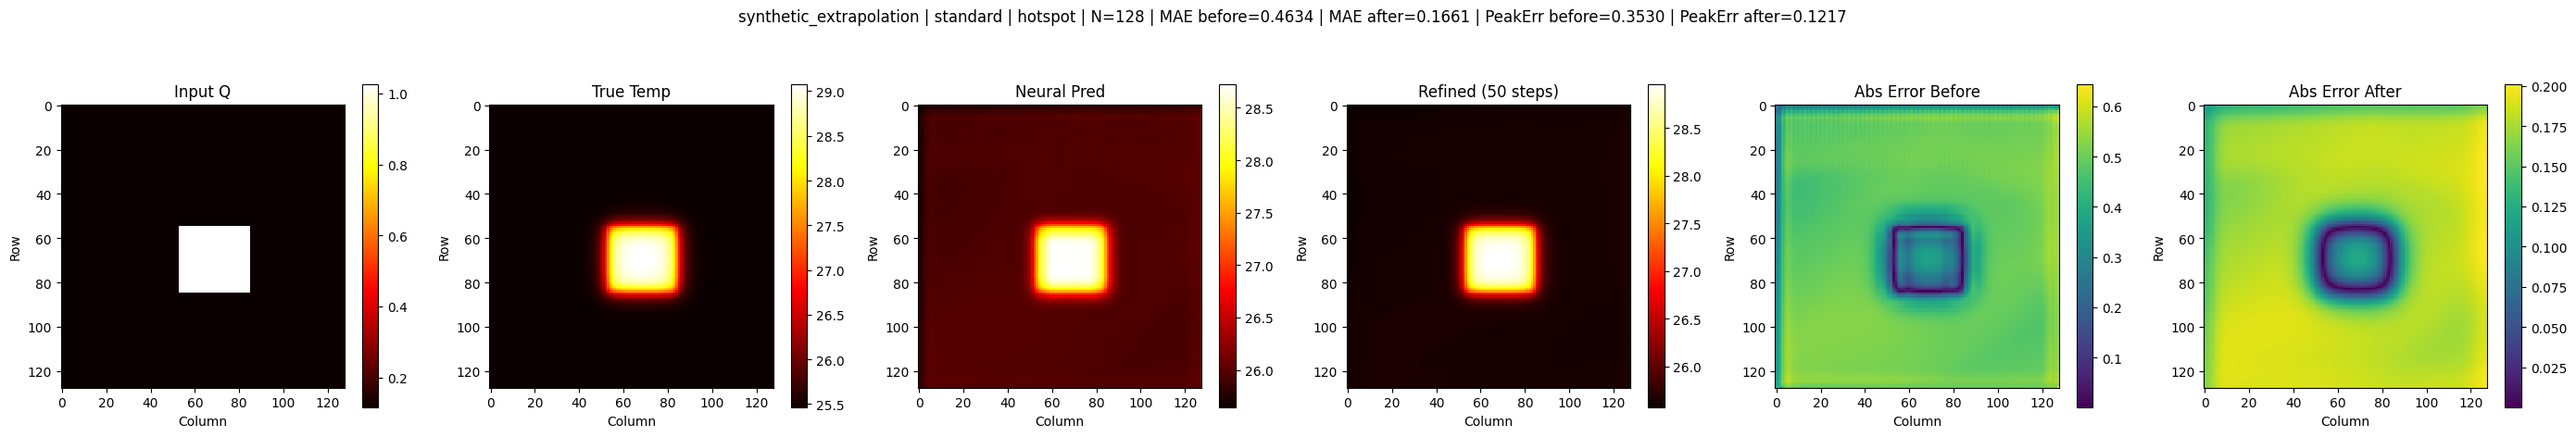

Saved: /home/aditya_chaudhry/thermal_aware_mac/results/multiscale_cnn_pinn/demo_extrapolation_cases/demo_standard_hotspot_128.png


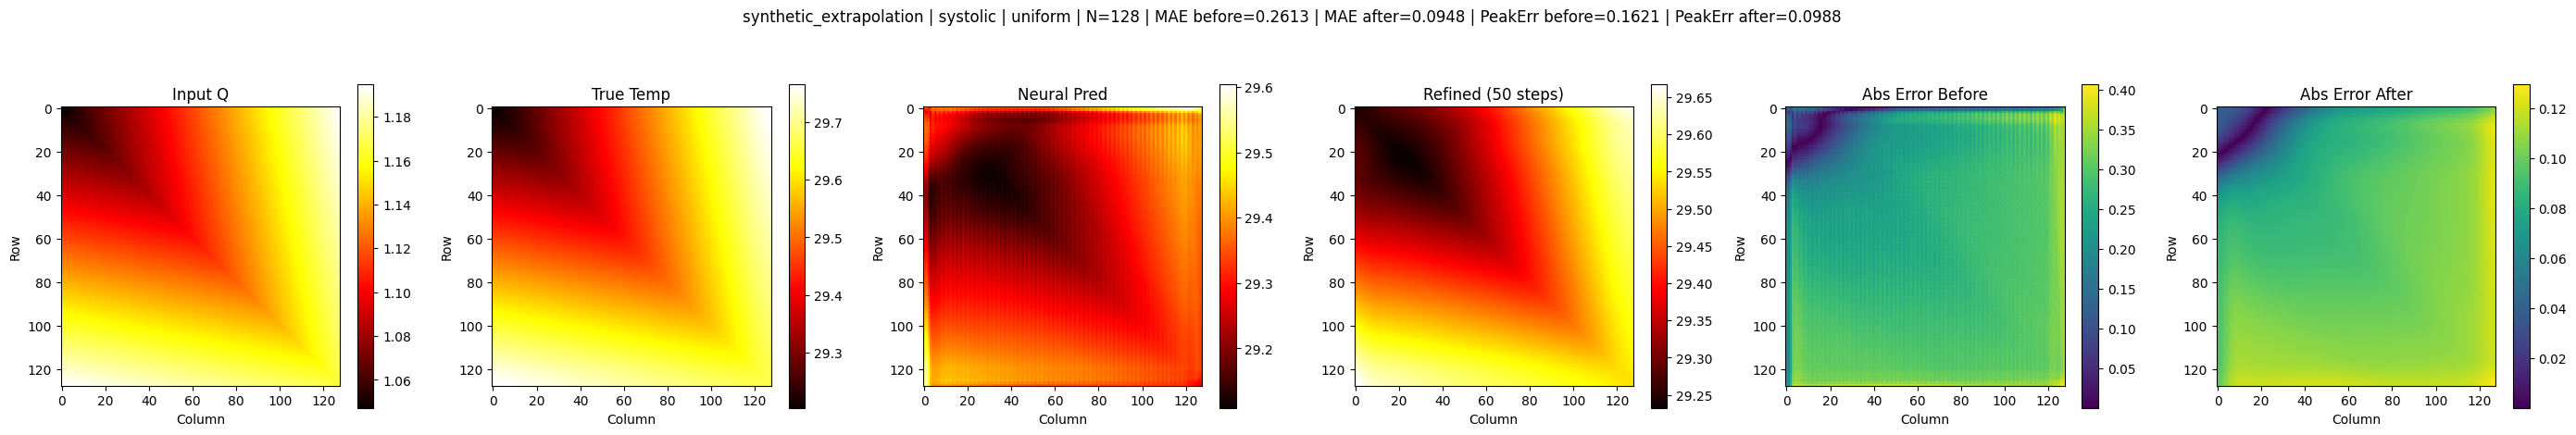

Saved: /home/aditya_chaudhry/thermal_aware_mac/results/multiscale_cnn_pinn/demo_extrapolation_cases/demo_systolic_uniform_128.png


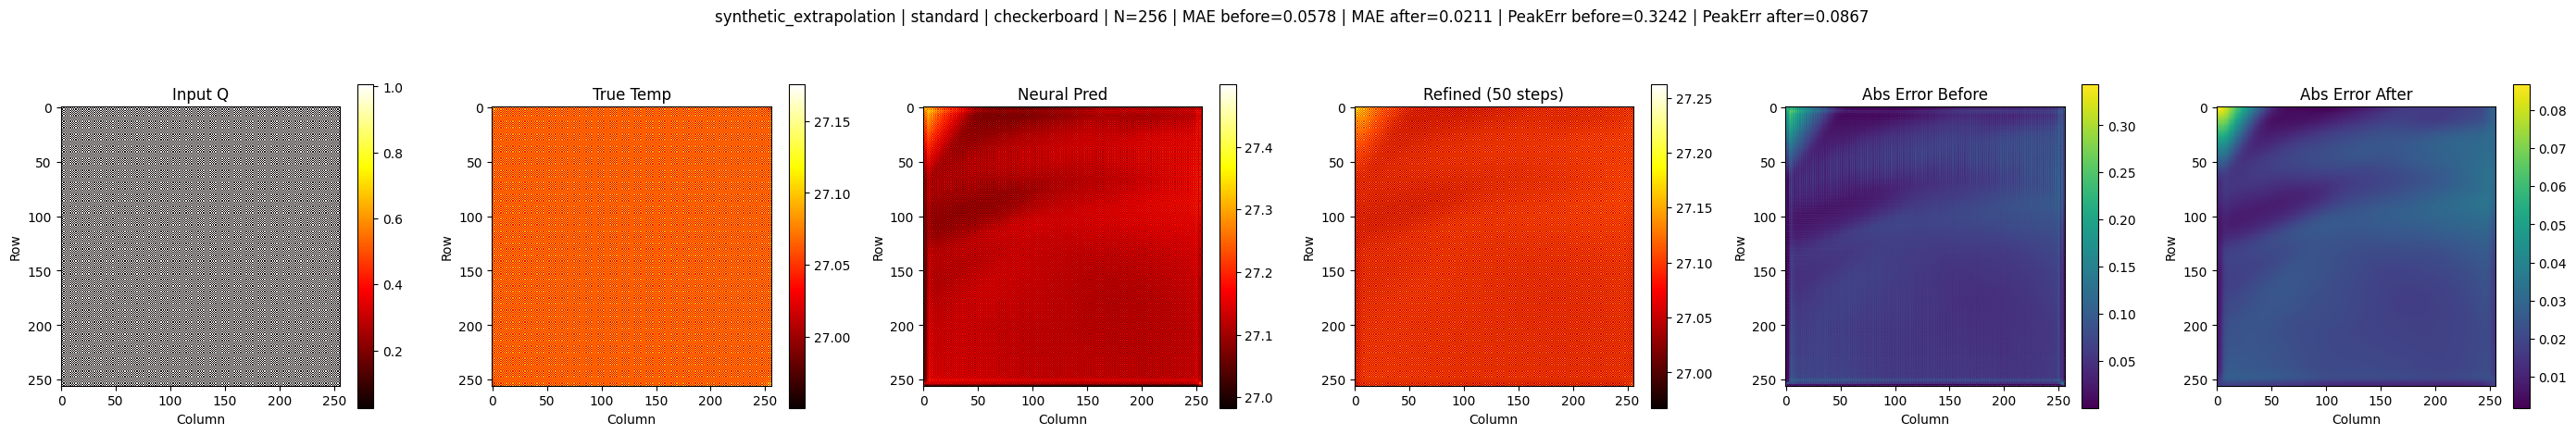

Saved: /home/aditya_chaudhry/thermal_aware_mac/results/multiscale_cnn_pinn/demo_extrapolation_cases/demo_standard_checkerboard_256.png


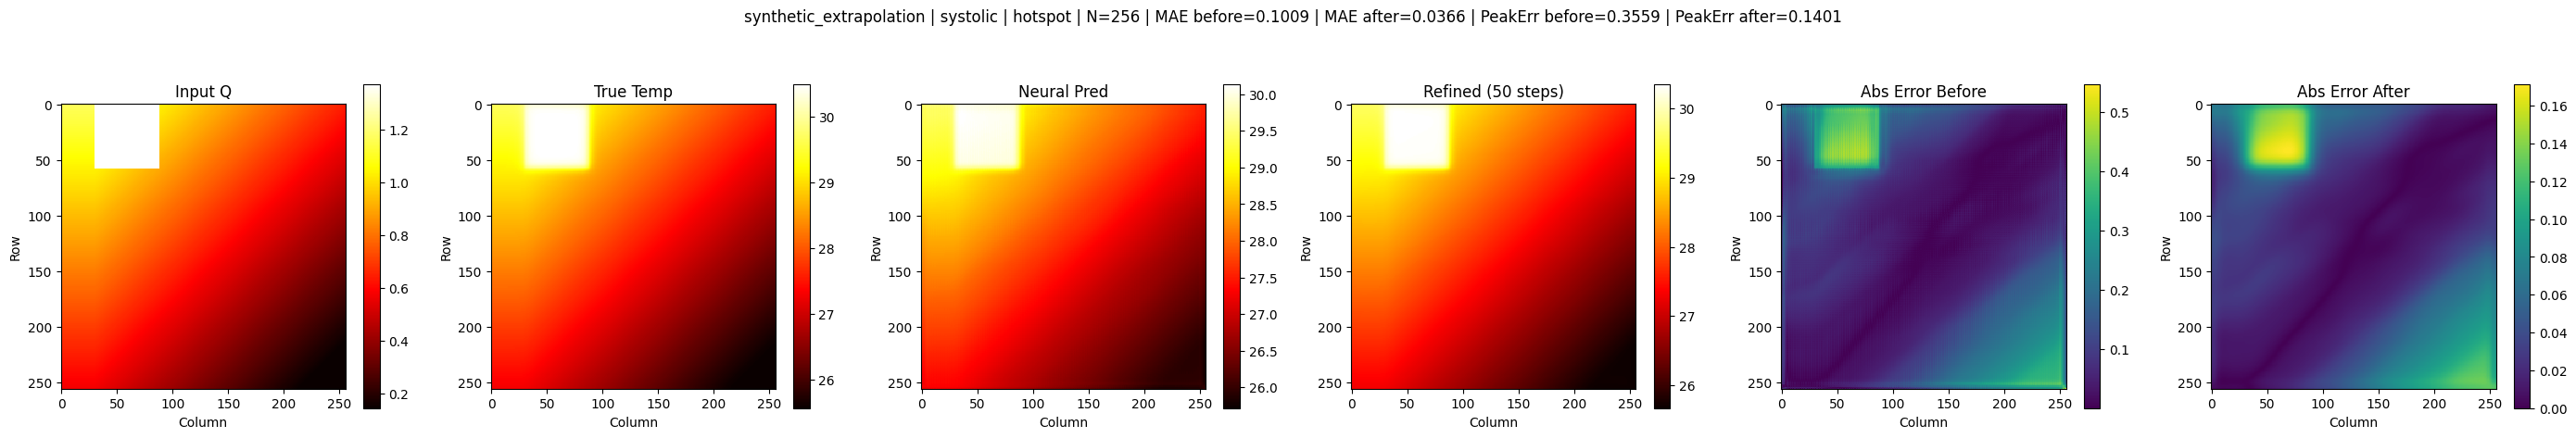

Saved: /home/aditya_chaudhry/thermal_aware_mac/results/multiscale_cnn_pinn/demo_extrapolation_cases/demo_systolic_hotspot_256.png

Demo figures saved in:
/home/aditya_chaudhry/thermal_aware_mac/results/multiscale_cnn_pinn/demo_extrapolation_cases

Demo case summary:


,N,architecture,workload,mae_before,mae_after,peak_err_before,peak_err_after,mae_improvement
0,128,standard,hotspot,0.463437,0.166109,0.352970,0.121725,0.297328
1,128,systolic,uniform,0.261294,0.094765,0.162067,0.098822,0.166529
2,256,standard,checkerboard,0.057813,0.021098,0.324238,0.086676,0.036715
3,256,systolic,hotspot,0.100897,0.036576,0.355932,0.140123,0.064321


In [13]:
# --------------------------------------------------
# Final Demo Cell: 128x128 / 256x256 showcase
#
# Shows:
#   Input Q
#   True temperature
#   Neural-only prediction
#   Hybrid-refined prediction
#   Error before
#   Error after
#
# Assumes these already exist from previous cells:
#   model, device
#   X_extrap, Y_extrap, MASK_extrap, meta_extrap_df
#   refinement_df
#   denorm_q_from_xb, denorm_dt_from_pred
#   refine_temperature_from_init
#   T_AMB, REFINE_STEPS, RESULTS_DIR
# --------------------------------------------------
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

DEMO_DIR = os.path.join(RESULTS_DIR, "demo_extrapolation_cases")
os.makedirs(DEMO_DIR, exist_ok=True)


def get_case_row(ref_df, N, architecture, workload):
    """Pick the best refined example in the requested category."""
    subset = ref_df[
        (ref_df["N"] == N) &
        (ref_df["architecture"] == architecture) &
        (ref_df["workload"] == workload)
    ].copy()

    if len(subset) == 0:
        return None

    # show the best post-refinement sample for a cleaner demo
    subset = subset.sort_values("mae_after", ascending=True)
    return subset.iloc[0]


def plot_demo_case(row_obj, save=True):
    if row_obj is None:
        print("Requested demo case not found.")
        return

    local_idx = int(row_obj["local_idx"])
    N = int(row_obj["N"])

    x_norm = torch.tensor(X_extrap[local_idx:local_idx+1], dtype=torch.float32).to(device)
    y_norm = torch.tensor(Y_extrap[local_idx:local_idx+1], dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pred_norm = model(x_norm)

        q_phys = denorm_q_from_xb(x_norm)[0, 0, :N, :N].cpu().numpy()
        true_dT = denorm_dt_from_pred(y_norm)[0, 0, :N, :N].cpu().numpy()
        pred_dT = denorm_dt_from_pred(pred_norm)[0, 0, :N, :N].cpu().numpy()

    true_temp = true_dT + T_AMB
    pred_temp = pred_dT + T_AMB
    refined_temp = refine_temperature_from_init(q_phys, pred_temp, n_steps=REFINE_STEPS)

    err_before = np.abs(pred_temp - true_temp)
    err_after = np.abs(refined_temp - true_temp)

    fig, axes = plt.subplots(1, 6, figsize=(28, 5))

    im0 = axes[0].imshow(q_phys, cmap="hot", interpolation="nearest")
    axes[0].set_title("Input Q")
    axes[0].set_xlabel("Column")
    axes[0].set_ylabel("Row")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(true_temp, cmap="hot", interpolation="nearest")
    axes[1].set_title("True Temp")
    axes[1].set_xlabel("Column")
    axes[1].set_ylabel("Row")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    im2 = axes[2].imshow(pred_temp, cmap="hot", interpolation="nearest")
    axes[2].set_title("Neural Pred")
    axes[2].set_xlabel("Column")
    axes[2].set_ylabel("Row")
    plt.colorbar(im2, ax=axes[2], shrink=0.8)

    im3 = axes[3].imshow(refined_temp, cmap="hot", interpolation="nearest")
    axes[3].set_title(f"Refined ({REFINE_STEPS} steps)")
    axes[3].set_xlabel("Column")
    axes[3].set_ylabel("Row")
    plt.colorbar(im3, ax=axes[3], shrink=0.8)

    im4 = axes[4].imshow(err_before, cmap="viridis", interpolation="nearest")
    axes[4].set_title("Abs Error Before")
    axes[4].set_xlabel("Column")
    axes[4].set_ylabel("Row")
    plt.colorbar(im4, ax=axes[4], shrink=0.8)

    im5 = axes[5].imshow(err_after, cmap="viridis", interpolation="nearest")
    axes[5].set_title("Abs Error After")
    axes[5].set_xlabel("Column")
    axes[5].set_ylabel("Row")
    plt.colorbar(im5, ax=axes[5], shrink=0.8)

    fig.suptitle(
        f"{row_obj['source']} | {row_obj['architecture']} | {row_obj['workload']} | N={N} | "
        f"MAE before={row_obj['mae_before']:.4f} | MAE after={row_obj['mae_after']:.4f} | "
        f"PeakErr before={row_obj['peak_err_before']:.4f} | PeakErr after={row_obj['peak_err_after']:.4f}"
    )
    plt.tight_layout()
    plt.show()

    if save:
        out_name = f"demo_{row_obj['architecture']}_{row_obj['workload']}_{N}.png"
        out_path = os.path.join(DEMO_DIR, out_name)
        fig.savefig(out_path, dpi=160, bbox_inches="tight")
        print("Saved:", out_path)

    plt.close(fig)


# --------------------------------------------------
# Pick representative 128x128 and 256x256 demo cases
# --------------------------------------------------
demo_cases = [
    get_case_row(refinement_df, 128, "standard", "hotspot"),
    get_case_row(refinement_df, 128, "systolic", "uniform"),
    get_case_row(refinement_df, 256, "standard", "checkerboard"),
    get_case_row(refinement_df, 256, "systolic", "hotspot"),
]

# --------------------------------------------------
# Show demos
# --------------------------------------------------
for row in demo_cases:
    plot_demo_case(row, save=True)

print("\nDemo figures saved in:")
print(DEMO_DIR)

print("\nDemo case summary:")
display(
    pd.DataFrame([
        {
            "N": int(r["N"]),
            "architecture": r["architecture"],
            "workload": r["workload"],
            "mae_before": float(r["mae_before"]),
            "mae_after": float(r["mae_after"]),
            "peak_err_before": float(r["peak_err_before"]),
            "peak_err_after": float(r["peak_err_after"]),
            "mae_improvement": float(r["mae_improvement"]),
        }
        for r in demo_cases if r is not None
    ])
)